# Objective

The goal is to detect cells in 3D microscopy images, associate detections across time and reconstruct cell lineages, including division events.

# Setup

In [1]:
%pip install -q zarr 

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.7/363.7 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 88.8 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [2]:
from pathlib import Path

import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import zarr

sns.set_theme(style="whitegrid")

# Dataset Structure

## Inspect the File Structure

In [3]:
INPUT_ROOT = Path("/kaggle/input")
COMPETITION_NAME = "biohub-cell-tracking-during-development"
DATA_ROOT = INPUT_ROOT / "competitions" / COMPETITION_NAME

print("Data root exists:", DATA_ROOT.exists())
print("Data root:", DATA_ROOT)

if DATA_ROOT.exists():
    for path in sorted(DATA_ROOT.iterdir()):
        print(path.name)
else:
    print("\nAvailable input directories:")
    for path in sorted(INPUT_ROOT.iterdir()):
        print(path)

Data root exists: True
Data root: /kaggle/input/competitions/biohub-cell-tracking-during-development
sample_submission.csv
test
train


The competition data contains three main components:

- `train/`: training microscopy movies and their sparse lineage annotations
- `test/`: the four microscopy movies for which predictions are required
- `sample_submission.csv`: an example of the required node-and-edge submission format

Unlike a standard tabular competition, each input sample is a time sequence of 3D image volumes. The prediction for each movie is a graph containing detected cell nodes and temporal edges.

In [4]:
train_root = DATA_ROOT / "train"
test_root = DATA_ROOT / "test"

train_entries = sorted(train_root.iterdir())
test_entries = sorted(test_root.iterdir())

print("Number of train entries:", len(train_entries))
print("Number of test entries:", len(test_entries))

print("\nFirst 10 train entries:")
for path in train_entries[:10]:
    print(path.name)

print("\nFirst 10 test entries:")
for path in test_entries[:10]:
    print(path.name)

Number of train entries: 398
Number of test entries: 4

First 10 train entries:
44b6_0113de3b.geff
44b6_0113de3b.zarr
44b6_0b24845f.geff
44b6_0b24845f.zarr
44b6_0c582fdc.geff
44b6_0c582fdc.zarr
44b6_0db75fae.geff
44b6_0db75fae.zarr
44b6_12dfb391.geff
44b6_12dfb391.zarr

First 10 test entries:
44b6_0113de3b.zarr
44b6_0b24845f.zarr
6bba_05b6850b.zarr
6bba_05db0fb1.zarr


## Build Dataset Inventory 

In [5]:
train_zarr = sorted(train_root.glob("*.zarr"))
train_geff = sorted(train_root.glob("*.geff"))
test_zarr = sorted(test_root.glob("*.zarr"))

train_zarr_ids = {path.stem for path in train_zarr}
train_geff_ids = {path.stem for path in train_geff}
test_ids = {path.stem for path in test_zarr}

print("Training Zarr movies:", len(train_zarr_ids))
print("Training GEFF graphs:", len(train_geff_ids))
print("Test Zarr movies:", len(test_ids))

print("\nZarr movies without matching GEFF:")
print(sorted(train_zarr_ids - train_geff_ids))

print("\nGEFF graphs without matching Zarr:")
print(sorted(train_geff_ids - train_zarr_ids))

overlapping_ids = train_zarr_ids & test_ids

print("\nTrain/test filename overlap:")
print(sorted(overlapping_ids))

Training Zarr movies: 199
Training GEFF graphs: 199
Test Zarr movies: 4

Zarr movies without matching GEFF:
[]

GEFF graphs without matching Zarr:
[]

Train/test filename overlap:
['44b6_0113de3b', '44b6_0b24845f', '6bba_05b6850b', '6bba_05db0fb1']


### Number of movies and annotation files

The training directory contains 398 entries, consisting of:

- 199 Zarr microscopy movies
- 199 corresponding GEFF lineage graphs

Every training movie has a matching annotation graph, and every annotation graph has a matching movie. Therefore, there are 199 training movies rather than 398 independent training samples.

The test set contains four Zarr movies.

In [6]:
def get_group(sample_id):
    return sample_id.split("_")[0]

inventory = pd.DataFrame(
    [
        {
            "sample_id": sample_id,
            "group": get_group(sample_id),
            "split": "train"
        }
        for sample_id in sorted(train_zarr_ids)
    ]
    +
    [
        {
            "sample_id": sample_id,
            "group": get_group(sample_id),
            "split": "test"
        }
        for sample_id in sorted(test_ids)
    ]
)

group_counts = (
    inventory
    .groupby(["split", "group"])
    .size()
    .rename("n_movies")
    .reset_index()
)

group_counts

,split,group,n_movies
0,test,44b6,2
1,test,6bba,2
2,train,44b6,71
3,train,6bba,128


### Train–test identifier overlap

All four test movie identifiers also appear in the training directory and have corresponding GEFF annotation files.

This overlap appears to be deliberate. A likely explanation is that the training GEFF files contain sparse observed annotations, while evaluation uses additional hidden annotations from the same movies. However, filename overlap alone does not prove that the train and test image contents are identical.

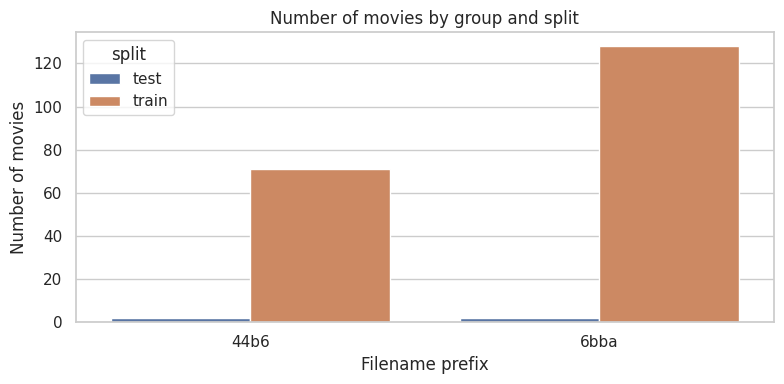

In [7]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(8, 4))

ax = sns.barplot(
    data=group_counts,
    x="group",
    y="n_movies",
    hue="split"
)

ax.set(
    title="Number of movies by group and split",
    xlabel="Filename prefix",
    ylabel="Number of movies"
)

plt.tight_layout()
plt.show()

### Apparent dataset groups

The movie identifiers begin with either `44b6` or `6bba`:

- `44b6`: 71 training movies and 2 test movies
- `6bba`: 128 training movies and 2 test movies

At this stage, these prefixes are treated as dataset groups. Their biological or experimental meaning has not yet been confirmed.

The training data are imbalanced across the two groups, with approximately 128/199 * 100 = 64.3% of the movies belonging to `6bba`. This may matter if the groups differ in image characteristics, cell density, movement patterns or annotation structure.

A validation strategy should eventually measure performance within each group rather than relying only on one pooled score.

## Inspect Submission Structure

In [8]:
sample_submission = pd.read_csv(
    DATA_ROOT / "sample_submission.csv"
)

print("Shape:", sample_submission.shape)
print("\nColumns:")
print(sample_submission.columns.tolist())

print("\nFirst 10 rows:")
display(sample_submission.head(10))

print("\nDataset values:")
print(sample_submission["dataset"].value_counts(dropna=False))

print("\nRow types:")
print(sample_submission["row_type"].value_counts(dropna=False))

Shape: (20, 10)

Columns:
['id', 'dataset', 'row_type', 'node_id', 't', 'z', 'y', 'x', 'source_id', 'target_id']

First 10 rows:


,id,dataset,row_type,node_id,t,z,y,x,source_id,target_id
0,0,44b6_0113de3b,node,1,0,32,128,128,-1,-1
1,1,44b6_0113de3b,node,2,1,32,128,128,-1,-1
2,2,44b6_0113de3b,node,3,2,32,128,128,-1,-1
3,3,44b6_0113de3b,edge,-1,-1,-1,-1,-1,1,2
4,4,44b6_0113de3b,edge,-1,-1,-1,-1,-1,2,3
5,5,44b6_0b24845f,node,1,0,32,128,128,-1,-1
6,6,44b6_0b24845f,node,2,1,32,128,128,-1,-1
7,7,44b6_0b24845f,node,3,2,32,128,128,-1,-1
8,8,44b6_0b24845f,edge,-1,-1,-1,-1,-1,1,2
9,9,44b6_0b24845f,edge,-1,-1,-1,-1,-1,2,3



Dataset values:
dataset
44b6_0113de3b    5
44b6_0b24845f    5
6bba_05b6850b    5
6bba_05db0fb1    5
Name: count, dtype: int64

Row types:
row_type
node    12
edge     8
Name: count, dtype: int64


In [9]:
display(
    sample_submission.groupby(["dataset", "row_type"])
    .size()
    .rename("n_rows")
    .reset_index()
)

,dataset,row_type,n_rows
0,44b6_0113de3b,edge,2
1,44b6_0113de3b,node,3
2,44b6_0b24845f,edge,2
3,44b6_0b24845f,node,3
4,6bba_05b6850b,edge,2
5,6bba_05b6850b,node,3
6,6bba_05db0fb1,edge,2
7,6bba_05db0fb1,node,3


### Submission structure

The sample submission contains two row types:

- `node`: a predicted cell detection with a node ID, timepoint and 3D voxel coordinates
- `edge`: a directed link from a source node to a target node

The example contains three nodes and two edges for each test movie. These are placeholder predictions that demonstrate the required format, not expected cell counts.

Each of the four test movies must appear in the final submission. Node IDs only need to identify nodes within their corresponding dataset, while the `id` column must be a consecutive global row index.

# Inspect One Zarr Movie

## Array Structure and Physical Scale

In [10]:
sample_id = "44b6_0113de3b"

train_zarr_path = train_root / f"{sample_id}.zarr"
test_zarr_path = test_root / f"{sample_id}.zarr"
geff_path = train_root / f"{sample_id}.geff"

print("Zarr version:", zarr.__version__)
print("Training path:", train_zarr_path)
print("Test path:", test_zarr_path)
print("GEFF path:", geff_path)

Zarr version: 3.3.0
Training path: /kaggle/input/competitions/biohub-cell-tracking-during-development/train/44b6_0113de3b.zarr
Test path: /kaggle/input/competitions/biohub-cell-tracking-during-development/test/44b6_0113de3b.zarr
GEFF path: /kaggle/input/competitions/biohub-cell-tracking-during-development/train/44b6_0113de3b.geff


In [11]:
train_store = zarr.open(str(train_zarr_path), mode="r")

print("Object type:", type(train_store))
print(train_store)

Object type: <class 'zarr.core.group.Group'>
<Group file:///kaggle/input/competitions/biohub-cell-tracking-during-development/train/44b6_0113de3b.zarr>


In [12]:
if hasattr(train_store, "tree"):
    print(train_store.tree())
else:
    print("This object has no tree method.")

/
└── 0 (100, 64, 256, 256) uint16



In [13]:
if hasattr(train_store, "attrs"):
    print("Root attributes:")
    
    for key, value in train_store.attrs.items():
        print(f"{key}: {value}")

Root attributes:
multiscales: [{'version': '0.5', 'axes': [{'name': 'T', 'type': 'time', 'unit': 'second'}, {'name': 'Z', 'type': 'space', 'unit': 'micrometer'}, {'name': 'Y', 'type': 'space', 'unit': 'micrometer'}, {'name': 'X', 'type': 'space', 'unit': 'micrometer'}], 'datasets': [{'path': '0', 'coordinateTransformations': [{'type': 'scale', 'scale': [1.0, 1.625, 0.40625, 0.40625]}]}], 'name': '0'}]
image_statistics: {'quantiles': {'0.0': 15.0, '0.001': 26.222222222222225, '0.01': 38.0, '0.1': 75.0, '0.9': 497.0, '0.99': 1478.0, '0.999': 2145.000000039654, '1.0': 4319.0}}


### Structure of an example microscopy movie

The movie `44b6_0113de3b` contains one four-dimensional image array with shape `(100, 64, 256, 256)`. According to the metadata, the dimensions represent time, depth, height and width: `(T, Z, Y, X)`.

The movie therefore contains 100 timepoints, with each timepoint represented by 64 images of size 256 × 256. Intensities are stored as unsigned 16-bit integers.

The physical spacing is:

- 1 second per timepoint
- 1.625 µm per voxel along the Z-axis
- 0.40625 µm per voxel along the Y- and X-axes

64 × 1.625 = 104μm  
256 × 0.40625 = 104μm
  
This gives an approximately cubic physical field of view of 104 × 104 × 104 µm. However, the individual voxels are anisotropic: one Z step covers four times the physical distance of one X or Y step (1.625/0.40625 = 4). Spatial distances must therefore be calculated using physical coordinates rather than unscaled voxel coordinates.

The array contains approximately 419 million intensity values and would occupy about 800 MiB if loaded uncompressed. Zarr's chunked storage allows selected frames and slices to be read without loading the complete movie.

The supplied intensity quantiles indicate a strongly right-skewed distribution. Most voxels have relatively low intensities, while a small proportion are substantially brighter. Visual inspection is required before interpreting the bright regions as cellular structures.

## Compare Train and Test Versions

In [14]:
test_store = zarr.open(str(test_zarr_path), mode="r")

print("Training store:")
print(train_store)

print("\nTest store:")
print(test_store)

print("\nTraining hierarchy:")
if hasattr(train_store, "tree"):
    print(train_store.tree())

print("\nTest hierarchy:")
if hasattr(test_store, "tree"):
    print(test_store.tree())

Training store:
<Group file:///kaggle/input/competitions/biohub-cell-tracking-during-development/train/44b6_0113de3b.zarr>

Test store:
<Group file:///kaggle/input/competitions/biohub-cell-tracking-during-development/test/44b6_0113de3b.zarr>

Training hierarchy:
/
└── 0 (100, 64, 256, 256) uint16


Test hierarchy:
/
└── 0 (100, 64, 256, 256) uint16



In [15]:
train_attrs = dict(train_store.attrs)
test_attrs = dict(test_store.attrs)

print("Same root attributes:", train_attrs == test_attrs)

print("\nTraining attributes:")
print(train_attrs)

print("\nTest attributes:")
print(test_attrs)

Same root attributes: True

Training attributes:
{'multiscales': [{'version': '0.5', 'axes': [{'name': 'T', 'type': 'time', 'unit': 'second'}, {'name': 'Z', 'type': 'space', 'unit': 'micrometer'}, {'name': 'Y', 'type': 'space', 'unit': 'micrometer'}, {'name': 'X', 'type': 'space', 'unit': 'micrometer'}], 'datasets': [{'path': '0', 'coordinateTransformations': [{'type': 'scale', 'scale': [1.0, 1.625, 0.40625, 0.40625]}]}], 'name': '0'}], 'image_statistics': {'quantiles': {'0.0': 15.0, '0.001': 26.222222222222225, '0.01': 38.0, '0.1': 75.0, '0.9': 497.0, '0.99': 1478.0, '0.999': 2145.000000039654, '1.0': 4319.0}}}

Test attributes:
{'multiscales': [{'version': '0.5', 'axes': [{'name': 'T', 'type': 'time', 'unit': 'second'}, {'name': 'Z', 'type': 'space', 'unit': 'micrometer'}, {'name': 'Y', 'type': 'space', 'unit': 'micrometer'}, {'name': 'X', 'type': 'space', 'unit': 'micrometer'}], 'datasets': [{'path': '0', 'coordinateTransformations': [{'type': 'scale', 'scale': [1.0, 1.625, 0.40625,

### Comparison of the train and test versions

The train and test versions of `44b6_0113de3b` have identical array hierarchies, shapes, data types, physical scales and stored intensity statistics.

This provides strong evidence that they represent the same underlying microscopy movie. The competition's test set therefore appears to select four movies from the training collection rather than introducing four entirely new image sequences.

Metadata equality does not by itself prove that every pixel is identical. A sample of image slices will be compared later to verify the image content.

# Inspect the Sparse GEFF Annotations

## GEFF Storage Hierarchy

In [16]:
geff_store = zarr.open(str(geff_path), mode="r")

print("GEFF object type:", type(geff_store))
print(geff_store)

if hasattr(geff_store, "tree"):
    print("\nGEFF hierarchy:")
    print(geff_store.tree())

print("\nGEFF root attributes:")
for key, value in geff_store.attrs.items():
    print(f"{key}: {value}")

GEFF object type: <class 'zarr.core.group.Group'>
<Group file:///kaggle/input/competitions/biohub-cell-tracking-during-development/train/44b6_0113de3b.geff>

GEFF hierarchy:
/
├── edges
│   ├── ids (50, 2) uint64
│   └── props
└── nodes
    ├── ids (52,) uint64
    └── props
        ├── t
        │   └── values (52,) int64
        ├── x
        │   └── values (52,) int64
        ├── y
        │   └── values (52,) int64
        └── z
            └── values (52,) int64


GEFF root attributes:
geff: {'geff_version': '1.1', 'directed': True, 'axes': [{'name': 't', 'type': 'time', 'unit': None, 'min': 0.0, 'max': 75.0, 'scale': 1.0, 'scaled_unit': None, 'offset': None}, {'name': 'z', 'type': 'space', 'unit': None, 'min': 1.0, 'max': 63.0, 'scale': 1.625, 'scaled_unit': None, 'offset': None}, {'name': 'y', 'type': 'space', 'unit': None, 'min': 74.0, 'max': 230.0, 'scale': 0.40625, 'scaled_unit': None, 'offset': None}, {'name': 'x', 'type': 'space', 'unit': None, 'min': 73.0, 'max': 253.0, 's

### Sparse GEFF lineage annotations

The GEFF file for `44b6_0113de3b` contains 52 annotated nodes and 50 directed edges. Each node has an integer timepoint and `(z, y, x)` centroid coordinates in voxel units. Each edge stores a source and target node ID and represents a directed temporal or lineage connection (order matters: an edge u→v means the cell represented by u is connected forward in time to v).

The annotations cover timepoints 0–75, although the microscopy movie contains timepoints 0–99. The spatial coordinate ranges describe the locations of annotated nodes and should not be confused with the complete image dimensions.

The graph metadata estimates that the complete movie contains approximately 25,755 cell nodes across time. The 52 supplied nodes represent only about 0.2% of that estimate, providing clear evidence that the training graph is extremely sparsely annotated.

Consequently, an unannotated cell-like object cannot be assumed to be a negative example. The supplied graph provides examples of true cells and true lineage connections, but it does not provide an exhaustive record of every cell.

## Supplied and Derived Graph Information

Each training GEFF file supplies a sparse annotation graph in the form of a node table and a directed edge list.

The supplied node information consists of:

- a unique node ID;
- a timepoint;
- Z, Y and X centroid coordinates.

Each supplied edge contains a source node ID and a target node ID. The direction represents a temporal or lineage connection from the source cell to the target cell.

The GEFF files do not explicitly store graph properties such as node degrees, roots, leaves, connected components or whether the graph is acyclic. These properties are derived from the supplied node and edge arrays.

The node and edge arrays are loaded into a NetworkX directed graph for analysis. 
These annotations are sparse. The resulting NetworkX graph represents the supplied portion of the lineage rather than the complete biological lineage in the microscopy movie.

## Extract Nodes and Edges

In [17]:
node_ids = geff_store["nodes/ids"][:]

nodes = pd.DataFrame({
    "node_id": node_ids,
    "t": geff_store["nodes/props/t/values"][:],
    "z": geff_store["nodes/props/z/values"][:],
    "y": geff_store["nodes/props/y/values"][:],
    "x": geff_store["nodes/props/x/values"][:]
})

edge_ids = geff_store["edges/ids"][:]

edges = pd.DataFrame({
    "source_id": edge_ids[:, 0],
    "target_id": edge_ids[:, 1]
})

print("Nodes shape:", nodes.shape)
display(nodes.head(10))

print("Edges shape:", edges.shape)
display(edges.head(10))

Nodes shape: (52, 5)


,node_id,t,z,y,x
0,11000000075,0,63,222,249
1,12000000075,1,63,227,251
2,13000000075,2,63,230,253
3,38000000003,27,1,74,73
4,39000000003,28,3,78,75
5,40000000003,29,5,80,77
6,41000000003,30,7,86,78
7,42000000003,31,9,91,77
8,43000000003,32,11,98,81
9,44000000003,33,11,104,78


Edges shape: (50, 2)


,source_id,target_id
0,11000000075,12000000075
1,12000000075,13000000075
2,38000000003,39000000003
3,39000000003,40000000003
4,40000000003,41000000003
5,41000000003,42000000003
6,42000000003,43000000003
7,43000000003,44000000003
8,44000000003,45000000003
9,45000000003,46000000003


## Graph Integrity Checks

In [18]:
print("Duplicate node IDs:", nodes["node_id"].duplicated().sum())
print("Missing node values:", nodes.isna().sum().sum())
print("Duplicate edges:", edges.duplicated().sum())

known_node_ids = set(nodes["node_id"])

unknown_sources = set(edges["source_id"]) - known_node_ids
unknown_targets = set(edges["target_id"]) - known_node_ids

print("Unknown source IDs:", unknown_sources)
print("Unknown target IDs:", unknown_targets)

Duplicate node IDs: 0
Missing node values: 0
Duplicate edges: 0
Unknown source IDs: set()
Unknown target IDs: set()


### Graph extraction and integrity checks

The GEFF graph for 44b6_0113de3b was converted into two tabular structures:

- a node table containing the node ID, timepoint and voxel coordinates;
- an edge table containing directed source–target node pairs.

The graph passes the initial integrity checks. Node IDs are unique, node attributes contain no missing values, edges are unique, and every edge endpoint refers to a node contained in the graph.

The large numerical node IDs are treated only as identifiers. No biological or temporal interpretation is inferred from their numerical values because time and position are stored explicitly as node attributes.

# Explore the Annotation Graph

## Graph-Theory Definitions

The following terms are used throughout the graph EDA.

| Term | Meaning in this notebook |
|---|---|
| Node or vertex | An annotated cell centroid at one timepoint |
| Directed edge | A supplied connection from a source node to a later target node |
| In-degree | Number of edges entering a node |
| Out-degree | Number of edges leaving a node |
| Root | A node with in-degree 0 |
| Leaf | A node with out-degree 0 |
| Division node | A node with out-degree 2 or more |
| Merge node | A node with in-degree 2 or more |
| Directed path | A sequence of nodes connected by consistently directed edges |
| Weak component | A maximal set of nodes connected when edge directions are ignored |
| Directed cycle | A directed path that returns to its starting node |
| Directed acyclic graph | A directed graph containing no directed cycles |
| Arborescence | A rooted directed tree with one directed path from its root to every other node |
| Directed forest | A collection of disconnected arborescences |

Because the annotations are sparse, roots and leaves identify the observed boundaries of an annotation component. They do not necessarily represent biological births, deaths or the true beginning and end of a lineage.

## Connected Components and Acyclicity

In [19]:
G = nx.DiGraph()

for row in nodes.itertuples(index=False):
    G.add_node(
        int(row.node_id),
        t=int(row.t),
        z=int(row.z),
        y=int(row.y),
        x=int(row.x)
    )

G.add_edges_from(
    (int(row.source_id), int(row.target_id))
    for row in edges.itertuples(index=False)
)

print("Number of vertices:", G.number_of_nodes())
print("Number of directed edges:", G.number_of_edges())
print("Directed acyclic graph:", nx.is_directed_acyclic_graph(G))
print("Number of self-loops:", nx.number_of_selfloops(G))

weak_components = list(nx.weakly_connected_components(G))
strong_components = list(nx.strongly_connected_components(G))

print("Weakly connected components:", len(weak_components))
print("Strongly connected components:", len(strong_components))

print(
    "Weak component sizes:",
    sorted([len(component) for component in weak_components], reverse=True)
)

Number of vertices: 52
Number of directed edges: 50
Directed acyclic graph: True
Number of self-loops: 0
Weakly connected components: 2
Strongly connected components: 52
Weak component sizes: [49, 3]


## Node Degrees and Graph Roles

In [20]:
degree_summary = pd.DataFrame({
    "node_id": list(G.nodes),
    "in_degree": [G.in_degree(node) for node in G.nodes],
    "out_degree": [G.out_degree(node) for node in G.nodes]
})

degree_summary = degree_summary.merge(
    nodes,
    on="node_id",
    how="left"
)

print("In-degree counts:")
display(
    degree_summary["in_degree"]
    .value_counts()
    .sort_index()
    .rename_axis("in_degree")
    .reset_index(name="n_nodes")
)

print("Out-degree counts:")
display(
    degree_summary["out_degree"]
    .value_counts()
    .sort_index()
    .rename_axis("out_degree")
    .reset_index(name="n_nodes")
)

In-degree counts:


,in_degree,n_nodes
0,0,2
1,1,50


Out-degree counts:


,out_degree,n_nodes
0,0,2
1,1,50


In [21]:
root_nodes = degree_summary[
    degree_summary["in_degree"] == 0
]

leaf_nodes = degree_summary[
    degree_summary["out_degree"] == 0
]

division_nodes = degree_summary[
    degree_summary["out_degree"] >= 2
]

merge_nodes = degree_summary[
    degree_summary["in_degree"] >= 2
]

print("Root nodes:", len(root_nodes))
print("Leaf nodes:", len(leaf_nodes))
print("Division nodes:", len(division_nodes))
print("Merge nodes:", len(merge_nodes))

print("\nDivision-node details:")
display(division_nodes.sort_values("t"))

print("\nMerge-node details:")
display(merge_nodes.sort_values("t"))

Root nodes: 2
Leaf nodes: 2
Division nodes: 0
Merge nodes: 0

Division-node details:


,node_id,in_degree,out_degree,t,z,y,x



Merge-node details:


,node_id,in_degree,out_degree,t,z,y,x


### Graph topology for `44b6_0113de3b`

The annotation graph is a directed acyclic graph containing two weakly connected components of sizes 49 and 3. Every non-root vertex has in-degree 1, and every non-leaf vertex has out-degree 1.

Consequently, the graph is the disjoint union of two directed paths:

$$P_{49} \sqcup P_3$$

The expected number of edges is therefore:

$$(49-1)+(3-1)=50,$$

which agrees with the observed edge count.

The graph contains no annotated divisions, merges, self-loops or cycles. This describes the supplied sparse annotation only; it does not demonstrate that the complete microscopy movie contains no cell divisions.

Roots and leaves represent the beginning and end of observed annotations rather than necessarily representing biological births and disappearances.


# Explore Movement Along the Annotated Trajectories

## Temporal Gaps

For each directed edge, the difference between the target and source timepoints is calculated as:

$$ \Delta t = t_{\text{target}} - t_{\text{source}} $$

This checks that every edge moves forward in time and determines whether the annotations connect consecutive frames or skip intermediate timepoints. Temporal gaps are also required to convert spatial displacement into speed correctly.

In [22]:
source_nodes = nodes.rename(columns={
    "node_id": "source_id",
    "t": "source_t",
    "z": "source_z",
    "y": "source_y",
    "x": "source_x"
})

target_nodes = nodes.rename(columns={
    "node_id": "target_id",
    "t": "target_t",
    "z": "target_z",
    "y": "target_y",
    "x": "target_x"
})

edge_data = (
    edges
    .merge(source_nodes, on="source_id", how="left")
    .merge(target_nodes, on="target_id", how="left")
)

edge_data["delta_t"] = (
    edge_data["target_t"] - edge_data["source_t"]
)

edge_data["delta_z_voxels"] = (
    edge_data["target_z"] - edge_data["source_z"]
)

edge_data["delta_y_voxels"] = (
    edge_data["target_y"] - edge_data["source_y"]
)

edge_data["delta_x_voxels"] = (
    edge_data["target_x"] - edge_data["source_x"]
)

display(edge_data.head())

,source_id,target_id,source_t,source_z,source_y,source_x,target_t,target_z,target_y,target_x,delta_t,delta_z_voxels,delta_y_voxels,delta_x_voxels
0,11000000075,12000000075,0,63,222,249,1,63,227,251,1,0,5,2
1,12000000075,13000000075,1,63,227,251,2,63,230,253,1,0,3,2
2,38000000003,39000000003,27,1,74,73,28,3,78,75,1,2,4,2
3,39000000003,40000000003,28,3,78,75,29,5,80,77,1,2,2,2
4,40000000003,41000000003,29,5,80,77,30,7,86,78,1,2,6,1


In [23]:
print("Edges moving forward in time:",
      (edge_data["delta_t"] > 0).all())

print("\nTime-gap distribution:")
display(
    edge_data["delta_t"]
    .value_counts()
    .sort_index()
    .rename_axis("delta_t")
    .reset_index(name="n_edges")
)

Edges moving forward in time: True

Time-gap distribution:


,delta_t,n_edges
0,1,50


All 50 edges move forward in time and have $\Delta t=1$. Therefore, both annotated paths connect consecutive frames without temporal gaps.

This result applies to the selected annotation graph only. The complete collection must later be examined to determine whether other graphs contain skipped frames.

## Physical Displacement

In [24]:
Z_SCALE = 1.625
Y_SCALE = 0.40625
X_SCALE = 0.40625
TIME_SCALE = 1.0

edge_data["delta_z_um"] = (
    edge_data["delta_z_voxels"] * Z_SCALE
)

edge_data["delta_y_um"] = (
    edge_data["delta_y_voxels"] * Y_SCALE
)

edge_data["delta_x_um"] = (
    edge_data["delta_x_voxels"] * X_SCALE
)

edge_data["distance_um"] = np.sqrt(
    edge_data["delta_z_um"] ** 2
    + edge_data["delta_y_um"] ** 2
    + edge_data["delta_x_um"] ** 2
)

edge_data["elapsed_seconds"] = (
    edge_data["delta_t"] * TIME_SCALE
)

edge_data["speed_um_per_second"] = (
    edge_data["distance_um"] / edge_data["elapsed_seconds"]
)

In [25]:
display(
    edge_data[
        [
            "delta_z_um",
            "delta_y_um",
            "delta_x_um",
            "distance_um",
            "speed_um_per_second"
        ]
    ].describe()
)

,delta_z_um,delta_y_um,delta_x_um,distance_um,speed_um_per_second
count,50.000000,50.000000,50.000000,50.000000,50.000000
mean,2.015000,0.503750,1.080625,3.124104,3.124104
std,1.414358,1.451032,1.571493,1.486572,1.486572
min,-1.625000,-3.250000,-6.093750,0.406250,0.406250
25%,1.625000,-0.406250,0.406250,2.100538,2.100538
50%,1.625000,0.406250,1.015625,2.882652,2.882652
75%,3.250000,1.218750,1.625000,3.854026,3.854026
max,4.875000,6.093750,4.468750,7.814375,7.814375


### Physical movement

The median physical displacement is 2.88 µm per frame, while the mean is 3.12 µm. The middle 50% of movements lie between approximately 2.10 and 3.85 µm, and the largest observed displacement is 7.81 µm.

Mean signed displacement is positive along all three spatial axes, particularly the Z-axis, suggesting directional movement through the volume. This result should not yet be generalized: 48 of the 50 edges belong to one trajectory, and successive movements within a trajectory are not statistically independent.

The 7 µm tolerance in the evaluation metric concerns matching predicted and ground-truth node positions. It should not be interpreted as a maximum permitted edge length.

## Visualise the Trajectories

In [26]:
components_by_size = sorted(
    weak_components,
    key=len,
    reverse=True
)

component_map = {
    int(node_id): component_number
    for component_number, component in enumerate(
        components_by_size,
        start=1
    )
    for node_id in component
}

nodes_plot = nodes.copy()

nodes_plot["component"] = (
    nodes_plot["node_id"]
    .map(component_map)
    .astype(str)
)

nodes_plot["z_um"] = nodes_plot["z"] * Z_SCALE
nodes_plot["y_um"] = nodes_plot["y"] * Y_SCALE
nodes_plot["x_um"] = nodes_plot["x"] * X_SCALE

nodes_plot = nodes_plot.sort_values(
    ["component", "t"]
)

display(
    nodes_plot.groupby("component").agg(
        n_nodes=("node_id", "size"),
        first_t=("t", "min"),
        last_t=("t", "max")
    )
)

,n_nodes,first_t,last_t
component,,,
1,49,27,75
2,3,0,2


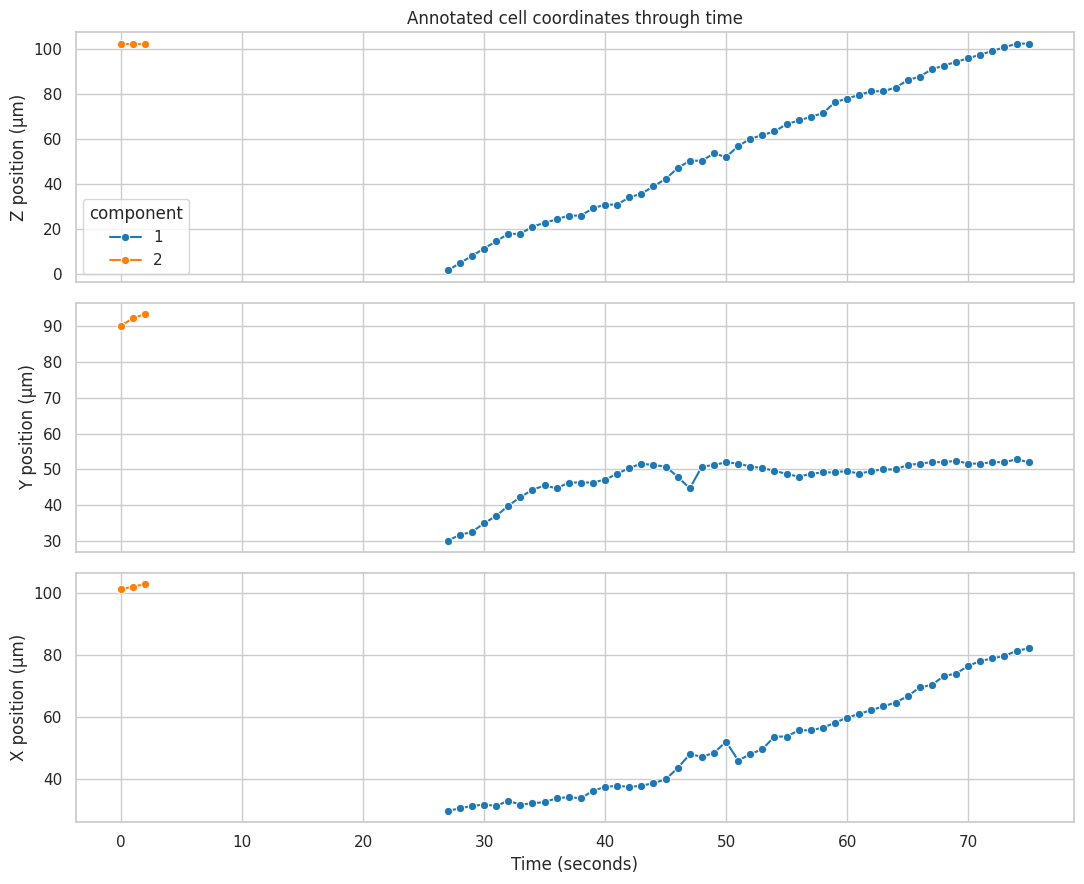

In [27]:
component_palette = {
    "1": "tab:blue",
    "2": "tab:orange"
}

component_order = ["1", "2"]

fig, axes = plt.subplots(
    nrows=3,
    ncols=1,
    figsize=(11, 9),
    sharex=True
)

coordinates = [
    ("z_um", "Z position (µm)"),
    ("y_um", "Y position (µm)"),
    ("x_um", "X position (µm)")
]

for ax, (column, ylabel) in zip(axes, coordinates):
    sns.lineplot(
        data=nodes_plot,
        x="t",
        y=column,
        hue="component",
        hue_order=component_order,
        palette=component_palette,
        marker="o",
        ax=ax,
        legend=(ax is axes[0])
    )
    ax.set_ylabel(ylabel)
    ax.set_xlabel("")

axes[0].set_title(
    "Annotated cell coordinates through time"
)

axes[-1].set_xlabel("Time (seconds)")

plt.tight_layout()
plt.show()

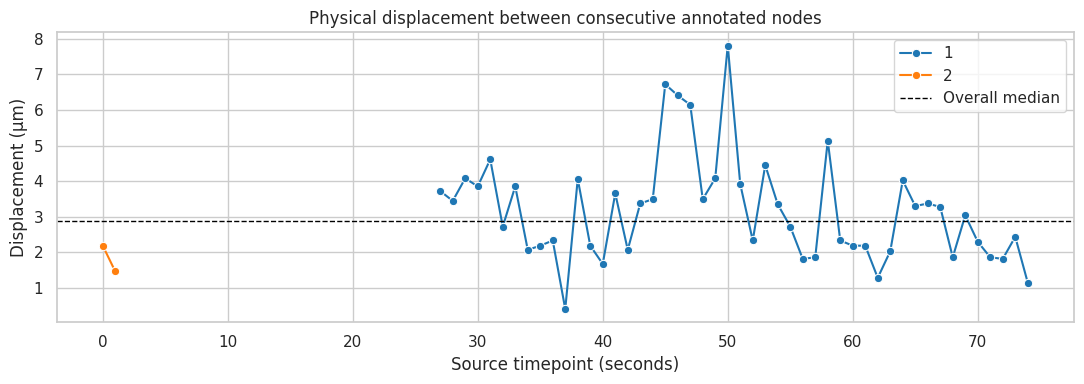

In [28]:
edge_data["component"] = (
    edge_data["source_id"]
    .map(component_map)
    .astype(str)
)

plt.figure(figsize=(11, 4))

sns.lineplot(
    data=edge_data,
    x="source_t",
    y="distance_um",
    hue="component",
    hue_order=component_order,
    palette=component_palette,
    marker="o"
)

plt.axhline(
    edge_data["distance_um"].median(),
    color="black",
    linestyle="--",
    linewidth=1,
    label="Overall median"
)

plt.title("Physical displacement between consecutive annotated nodes")
plt.xlabel("Source timepoint (seconds)")
plt.ylabel("Displacement (µm)")
plt.legend()
plt.tight_layout()
plt.show()

### Visual characteristics of the annotated trajectories

The larger component contains 49 consecutive nodes from timepoints 27–75, while the smaller component contains three consecutive nodes from timepoints 0–2.

The long trajectory shows an approximately linear increase in Z, indicating sustained movement in the positive axial direction. Its Y-coordinate initially increases before becoming relatively stable. Its X-coordinate also follows a clear increasing trend.

Despite the smooth overall coordinate trends, frame-to-frame displacement is highly variable. It ranges from approximately 0.41 µm to 7.81 µm, with a median of 2.88 µm. This is not contradictory: displacement is calculated from first differences, which emphasise local changes in the slope of a position trajectory. Integer voxel coordinates may also introduce quantisation into the estimated movement.

These observations primarily describe Component 1 because it supplies 48 of the graph's 50 edges. Component 2 contains only two edges and is too short to establish a movement pattern.

# Dataset-Level EDA

The initial investigation examined one selected movie in detail. The analysis now expands to all 199 training movies to determine how image dimensions, annotation coverage and graph sizes vary across the dataset.

Only Zarr and GEFF metadata will initially be read. The complete image arrays will not be loaded into memory.

## Build a movie-level metadata table

In [29]:
def extract_movie_metadata(zarr_path):
    sample_id = zarr_path.stem
    group = sample_id.split("_")[0]

    # Open the microscopy movie without loading the full array
    movie_store = zarr.open(str(zarr_path), mode="r")
    image = movie_store["0"]

    t_size, z_size, y_size, x_size = image.shape

    scale = (
        movie_store.attrs["multiscales"][0]
        ["datasets"][0]
        ["coordinateTransformations"][0]
        ["scale"]
    )

    time_scale, z_scale, y_scale, x_scale = scale

    # Open the corresponding sparse annotation graph
    graph_path = train_root / f"{sample_id}.geff"
    graph_store = zarr.open(str(graph_path), mode="r")

    n_annotated_nodes = graph_store["nodes/ids"].shape[0]
    n_annotated_edges = graph_store["edges/ids"].shape[0]

    graph_metadata = graph_store.attrs["geff"]

    estimated_nodes = (
        graph_metadata
        .get("extra", {})
        .get("estimated_number_of_nodes", np.nan)
    )

    return {
        "sample_id": sample_id,
        "group": group,
        "is_test_movie": sample_id in test_ids,
        "n_timepoints": t_size,
        "z_size": z_size,
        "y_size": y_size,
        "x_size": x_size,
        "dtype": str(image.dtype),
        "time_scale": time_scale,
        "z_scale": z_scale,
        "y_scale": y_scale,
        "x_scale": x_scale,
        "n_annotated_nodes": n_annotated_nodes,
        "n_annotated_edges": n_annotated_edges,
        "estimated_nodes": estimated_nodes
    }

In [30]:
movie_metadata = pd.DataFrame(
    extract_movie_metadata(path)
    for path in train_zarr
)

movie_metadata["annotation_fraction"] = (
    movie_metadata["n_annotated_nodes"]
    / movie_metadata["estimated_nodes"]
)

print("Shape:", movie_metadata.shape)

display(movie_metadata.head())

Shape: (199, 16)


,sample_id,group,is_test_movie,n_timepoints,z_size,y_size,x_size,dtype,time_scale,z_scale,y_scale,x_scale,n_annotated_nodes,n_annotated_edges,estimated_nodes,annotation_fraction
0,44b6_0113de3b,44b6,True,100,64,256,256,uint16,1.0,1.625,0.40625,0.40625,52,50,25755,0.002019
1,44b6_0b24845f,44b6,True,100,64,256,256,uint16,1.0,1.625,0.40625,0.40625,51,49,32795,0.001555
2,44b6_0c582fdc,44b6,False,100,64,256,256,uint16,1.0,1.625,0.40625,0.40625,71,70,27958,0.002540
3,44b6_0db75fae,44b6,False,100,64,256,256,uint16,1.0,1.625,0.40625,0.40625,157,151,15335,0.010238
4,44b6_12dfb391,44b6,False,100,64,256,256,uint16,1.0,1.625,0.40625,0.40625,788,773,58672,0.013431


In [31]:
print("Missing values:")
display(movie_metadata.isna().sum())

print("\nData types:")
display(movie_metadata.dtypes)

Missing values:


sample_id              0
group                  0
is_test_movie          0
n_timepoints           0
z_size                 0
y_size                 0
x_size                 0
dtype                  0
time_scale             0
z_scale                0
y_scale                0
x_scale                0
n_annotated_nodes      0
n_annotated_edges      0
estimated_nodes        0
annotation_fraction    0
dtype: int64


Data types:


sample_id               object
group                   object
is_test_movie             bool
n_timepoints             int64
z_size                   int64
y_size                   int64
x_size                   int64
dtype                   object
time_scale             float64
z_scale                float64
y_scale                float64
x_scale                float64
n_annotated_nodes        int64
n_annotated_edges        int64
estimated_nodes          int64
annotation_fraction    float64
dtype: object

In [32]:
display(
    movie_metadata[
        [
            "n_timepoints",
            "z_size",
            "y_size",
            "x_size",
            "n_annotated_nodes",
            "n_annotated_edges",
            "estimated_nodes",
            "annotation_fraction"
        ]
    ].describe()
)

,n_timepoints,z_size,y_size,x_size,n_annotated_nodes,n_annotated_edges,estimated_nodes,annotation_fraction
count,199.0,199.0,199.0,199.0,199.000000,199.000000,199.000000,199.000000
mean,100.0,64.0,256.0,256.0,669.939698,647.653266,23744.306533,0.061261
std,0.0,0.0,0.0,0.0,421.410482,406.297691,19374.609448,0.058423
min,100.0,64.0,256.0,256.0,50.000000,49.000000,3783.000000,0.001272
25%,100.0,64.0,256.0,256.0,294.000000,286.000000,7477.000000,0.010378
50%,100.0,64.0,256.0,256.0,659.000000,639.000000,17909.000000,0.035554
75%,100.0,64.0,256.0,256.0,939.500000,918.500000,32738.000000,0.118048
max,100.0,64.0,256.0,256.0,1950.000000,1879.000000,78644.000000,0.202063


### Initial Movie-Level Findings

All 199 movies have the same dimensions: 100 timepoints, 64 Z-slices and a 256 × 256 image at each depth. The uniform dimensions mean that variation between movies is not caused by different array sizes.

Annotation quantities vary substantially. The number of supplied nodes ranges from 50 to 1,950, while the estimated total number of cell nodes ranges from 3,783 to 78,644.

The median estimated annotation fraction is approximately 3.56%, with the middle 50% of movies ranging from approximately 1.04% to 11.80%. The mean estimated coverage is 6.13%, compared with a median of 3.56%. This difference is examined further by separating the two dataset groups.

The selected movie `44b6_0113de3b` has an estimated annotation fraction of approximately 0.20%. It is therefore much more sparsely annotated than a typical training movie.

The annotation fraction should be interpreted as an approximate coverage measure because its denominator is an estimated total node count rather than an observed dense count.

## Check structural consistency

In [33]:
structural_columns = [
    "n_timepoints",
    "z_size",
    "y_size",
    "x_size",
    "dtype",
    "time_scale",
    "z_scale",
    "y_scale",
    "x_scale"
]

structural_summary = pd.DataFrame({
    "n_unique_values": movie_metadata[
        structural_columns
    ].nunique(),
    
    "values": [
        movie_metadata[column].unique().tolist()
        for column in structural_columns
    ]
})

display(structural_summary)

,n_unique_values,values
n_timepoints,1,[100]
z_size,1,[64]
y_size,1,[256]
x_size,1,[256]
dtype,1,[uint16]
time_scale,1,[1.0]
z_scale,1,[1.625]
y_scale,1,[0.40625]
x_scale,1,[0.40625]


## Examine Test-Movie Annotation Coverage

In [34]:
test_movie_metadata = movie_metadata.loc[
    movie_metadata["is_test_movie"],
    [
        "sample_id",
        "group",
        "n_annotated_nodes",
        "n_annotated_edges",
        "estimated_nodes",
        "annotation_fraction"
    ]
].copy()

test_movie_metadata["annotation_percentage"] = (
    100 * test_movie_metadata["annotation_fraction"]
)

display(test_movie_metadata)

,sample_id,group,n_annotated_nodes,n_annotated_edges,estimated_nodes,annotation_fraction,annotation_percentage
0,44b6_0113de3b,44b6,52,50,25755,0.002019,0.201903
1,44b6_0b24845f,44b6,51,49,32795,0.001555,0.155512
71,6bba_05b6850b,6bba,861,845,6362,0.135335,13.533480
72,6bba_05db0fb1,6bba,1229,1183,69800,0.017607,1.760745


In [35]:
movie_metadata["coverage_percentile_overall"] = (
    100 * movie_metadata["annotation_fraction"].rank(pct=True)
)

movie_metadata["coverage_percentile_within_group"] = (
    100
    * movie_metadata.groupby("group")["annotation_fraction"]
    .rank(pct=True)
)

display(
    movie_metadata.loc[
        movie_metadata["is_test_movie"],
        [
            "sample_id",
            "group",
            "annotation_fraction",
            "coverage_percentile_overall",
            "coverage_percentile_within_group"
        ]
    ].sort_values("annotation_fraction")
)

,sample_id,group,annotation_fraction,coverage_percentile_overall,coverage_percentile_within_group
1,44b6_0b24845f,44b6,0.001555,1.507538,4.225352
0,44b6_0113de3b,44b6,0.002019,4.522613,12.676056
72,6bba_05db0fb1,6bba,0.017607,36.683417,9.375000
71,6bba_05b6850b,6bba,0.135335,85.427136,77.343750


### Structural Consistency and Test-Movie Coverage

All 199 movies have identical dimensions, data types, temporal sampling and physical voxel spacing. Therefore, differences between movies are not caused by differences in array structure or physical resolution.

The four test movies vary substantially in estimated annotation coverage. Both `44b6` test movies are among the sparsest annotated movies in the dataset, with estimated coverage of approximately 0.16% and 0.20%.

The two `6bba` test movies have estimated coverage of approximately 1.76% and 13.53%. The first is relatively sparse within the `6bba` group, whereas the second has relatively high coverage.

The difference between overall and within-group percentiles suggests that the coverage distributions may differ between `44b6` and `6bba`. Group-specific distributions should therefore be examined before pooling the movies.

## Compare annotation coverage between groups

Estimated Coverage = annotated nodes / estimated total nodes

In [36]:
movie_metadata["annotation_percentage"] = (
    100 * movie_metadata["annotation_fraction"]
)

coverage_by_group = (
    movie_metadata
    .groupby("group")
    .agg(
        n_movies=("sample_id", "size"),
        minimum=("annotation_percentage", "min"),
        first_quartile=(
            "annotation_percentage",
            lambda values: values.quantile(0.25)
        ),
        median=("annotation_percentage", "median"),
        mean=("annotation_percentage", "mean"),
        third_quartile=(
            "annotation_percentage",
            lambda values: values.quantile(0.75)
        ),
        maximum=("annotation_percentage", "max")
    )
)

display(coverage_by_group.round(3))

,n_movies,minimum,first_quartile,median,mean,third_quartile,maximum
group,,,,,,,
44b6,71,0.127,0.388,0.772,0.985,1.238,5.018
6bba,128,0.930,3.944,9.715,8.978,13.401,20.206


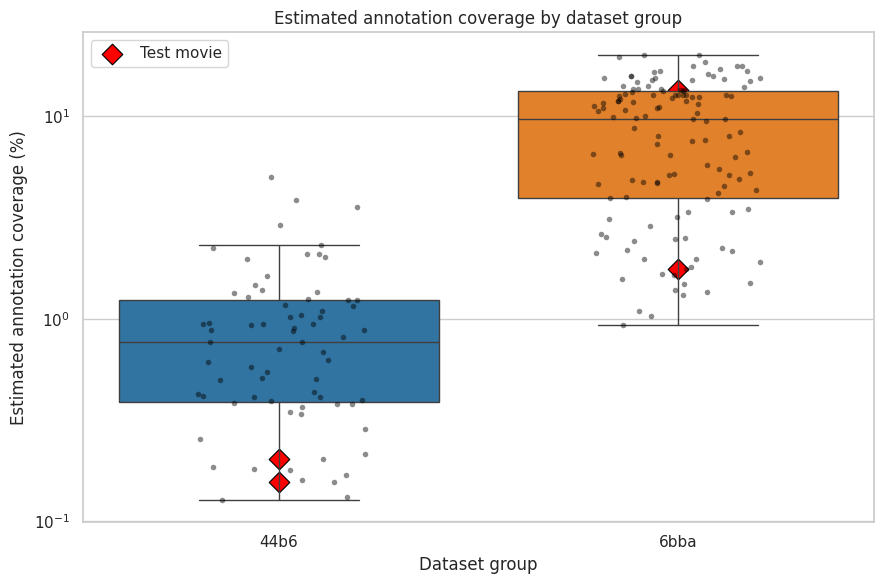

In [37]:
plt.figure(figsize=(9, 6))

ax = sns.boxplot(
    data=movie_metadata,
    x="group",
    y="annotation_percentage",
    hue="group",
    palette={
        "44b6": "tab:blue",
        "6bba": "tab:orange"
    },
    showfliers=False,
    legend=False
)

sns.stripplot(
    data=movie_metadata,
    x="group",
    y="annotation_percentage",
    color="black",
    alpha=0.45,
    jitter=0.22,
    size=4,
    ax=ax
)

test_plot_data = movie_metadata[
    movie_metadata["is_test_movie"]
]

sns.scatterplot(
    data=test_plot_data,
    x="group",
    y="annotation_percentage",
    color="red",
    edgecolor="black",
    marker="D",
    s=110,
    label="Test movie",
    ax=ax
)

ax.set_yscale("log")

ax.set(
    title="Estimated annotation coverage by dataset group",
    xlabel="Dataset group",
    ylabel="Estimated annotation coverage (%)"
)

ax.legend()
plt.tight_layout()
plt.show()

### Annotation Coverage Differs Strongly Between Groups

Estimated annotation coverage differs substantially between the two dataset groups. Median coverage is approximately 0.77% for `44b6` and 9.72% for `6bba`, making the `6bba` median approximately 12.6 times larger.

The interquartile ranges do not overlap. The middle 50% of `44b6` movies have estimated coverage between approximately 0.39% and 1.24%, compared with 3.94% to 13.40% for `6bba`.

The two `44b6` test movies are located near the lower end of their group. The `6bba` test movies represent contrasting coverage conditions, with one in the lower part of the distribution and the other near the upper quartile.

These results show that pooled summaries can conceal substantial group differences. Subsequent EDA and validation should retain the distinction between `44b6` and `6bba`.

## Decompose the Annotation-Coverage Difference

In [38]:
node_summary_by_group = (
    movie_metadata
    .groupby("group")
    .agg(
        median_annotated_nodes=(
            "n_annotated_nodes",
            "median"
        ),
        mean_annotated_nodes=(
            "n_annotated_nodes",
            "mean"
        ),
        median_estimated_nodes=(
            "estimated_nodes",
            "median"
        ),
        mean_estimated_nodes=(
            "estimated_nodes",
            "mean"
        )
    )
)

display(node_summary_by_group.round(1))

,median_annotated_nodes,mean_annotated_nodes,median_estimated_nodes,mean_estimated_nodes
group,,,,
44b6,214.0,284.5,32681.0,36886.9
6bba,826.5,883.8,9691.0,16454.3


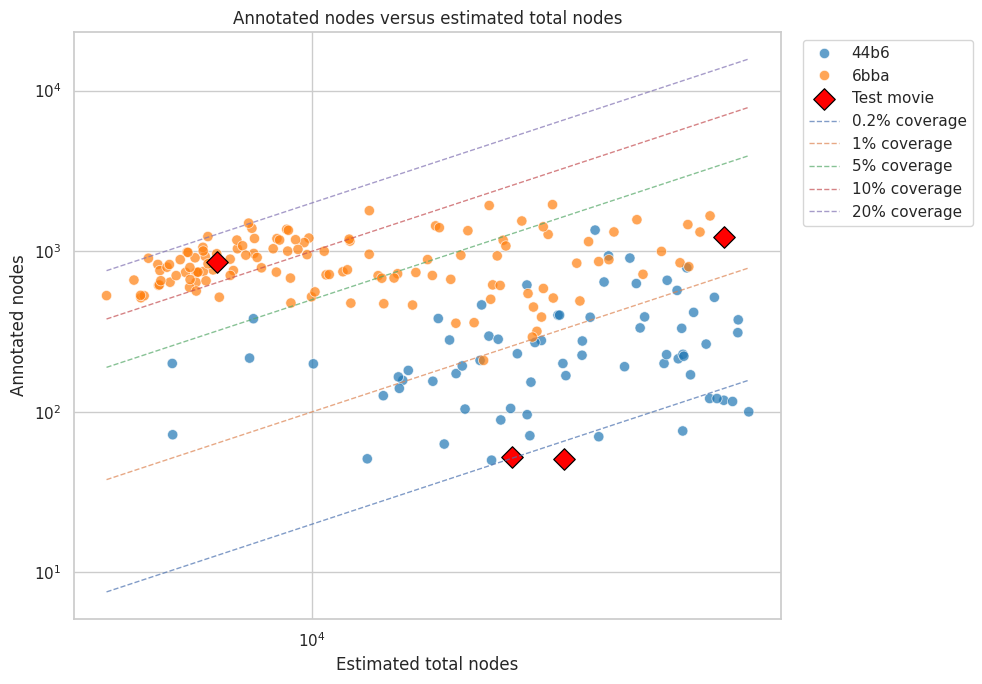

In [39]:
group_palette = {
    "44b6": "tab:blue",
    "6bba": "tab:orange"
}

fig, ax = plt.subplots(figsize=(10, 7))

sns.scatterplot(
    data=movie_metadata,
    x="estimated_nodes",
    y="n_annotated_nodes",
    hue="group",
    hue_order=["44b6", "6bba"],
    palette=group_palette,
    alpha=0.7,
    s=55,
    ax=ax
)

sns.scatterplot(
    data=movie_metadata[movie_metadata["is_test_movie"]],
    x="estimated_nodes",
    y="n_annotated_nodes",
    color="red",
    edgecolor="black",
    marker="D",
    s=120,
    label="Test movie",
    ax=ax
)

x_values = np.geomspace(
    movie_metadata["estimated_nodes"].min(),
    movie_metadata["estimated_nodes"].max(),
    200
)

for percentage in [0.2, 1, 5, 10, 20]:
    ax.plot(
        x_values,
        x_values * percentage / 100,
        linestyle="--",
        linewidth=1,
        alpha=0.7,
        label=f"{percentage}% coverage"
    )

ax.set_xscale("log")
ax.set_yscale("log")

ax.set(
    title="Annotated nodes versus estimated total nodes",
    xlabel="Estimated total nodes",
    ylabel="Annotated nodes"
)

ax.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

### Annotated and Estimated Node Counts

The two dataset groups occupy substantially different regions of the plot. Most `6bba` movies have fewer estimated total nodes but more supplied annotations, placing them toward the upper-left. Most `44b6` movies have more estimated nodes but fewer annotations, placing them toward the lower-right.

There is some overlap, but the separation is considerable. The higher annotation coverage of `6bba` is therefore produced by both a larger numerator and a smaller denominator.

This group structure means that an overall association between estimated and annotated node counts may be misleading. Relationships should be examined separately within each group.

## Simpson’s paradox

In [40]:
overall_correlation = movie_metadata[
    ["estimated_nodes", "n_annotated_nodes"]
].corr(method="spearman").iloc[0, 1]

group_correlations = (
    movie_metadata
    .groupby("group")
    .apply(
        lambda group_data: group_data[
            ["estimated_nodes", "n_annotated_nodes"]
        ].corr(method="spearman").iloc[0, 1],
        include_groups=False
    )
    .rename("spearman_correlation")
)

print(
    "Overall Spearman correlation:",
    round(overall_correlation, 3)
)

display(group_correlations.round(3))

Overall Spearman correlation: -0.278


group
44b6    0.259
6bba    0.160
Name: spearman_correlation, dtype: float64

### Pooled and Within-Group Associations

Across all movies, estimated total nodes and annotated nodes have a Spearman correlation of −0.278. However, the correlations within `44b6` and `6bba` are positive, at 0.259 and 0.160 respectively.

The pooled negative association is therefore produced by differences between the groups. `44b6` movies generally have larger estimated cell populations but fewer supplied annotations, while `6bba` movies generally have smaller estimated populations but more annotations.

Within each group, movies with larger estimated populations tend to have somewhat more annotations, although both associations are weak. This sign reversal demonstrates why the two groups should not be pooled without accounting for group membership.

## Section Summary

- All movies have identical array dimensions, data type, temporal sampling and voxel spacing.
- Estimated annotation coverage differs substantially between the two dataset groups and is generally much higher in `6bba`.
- The four test movies represent contrasting coverage conditions within their respective groups.
- `44b6` generally has larger estimated cell populations but fewer supplied annotations, whereas `6bba` has smaller estimated populations and more annotations.
- The pooled association between estimated and annotated node counts differs from the within-group associations, showing that dataset group must be retained in later analysis and validation.

# Explore the Microscopy Images

The previous sections examined image metadata and sparse lineage annotations. The microscopy intensities themselves are now visualised to understand the appearance, crowding and spatial distribution of the labelled cellular structures.

The analysis begins with one timepoint from the selected movie. Only the required 3D volume is loaded rather than the complete 4D movie.

## Why Visualise the Images?

The competition requires cell locations and temporal links to be inferred from fluorescence microscopy volumes. Before choosing a detection method, it is necessary to understand what information in the images distinguishes cells from background.

The visual inspection asks:

- Do cells appear as distinct bright structures?
- How blurred or irregular are their boundaries?
- Are neighbouring structures visually separable?
- Does apparent crowding vary across the volume?
- Is the background intensity uniform?
- Are there bright artefacts or structures near image boundaries?
- Would a classical local-maximum detector appear plausible as an initial baseline?
- Is information lost when a 3D volume is represented by individual 2D slices or projections?

These characteristics will inform later choices involving intensity normalisation, smoothing, detection thresholds, minimum separation distances and whether detection should operate in two or three dimensions.

## Load One 3D Timepoint

In [41]:
image_array = train_store["0"]

print("Full shape:", image_array.shape)
print("Chunk shape:", image_array.chunks)
print("Data type:", image_array.dtype)

selected_t = 50
volume = np.asarray(image_array[selected_t])

print("\nSelected timepoint:", selected_t)
print("Volume shape:", volume.shape)
print("Memory used (MiB):", volume.nbytes / 1024**2)

display(
    pd.Series(volume.ravel())
    .describe(
        percentiles=[0.01, 0.10, 0.50, 0.90, 0.99, 0.999]
    )
)

Full shape: (100, 64, 256, 256)
Chunk shape: (1, 64, 256, 256)
Data type: uint16

Selected timepoint: 50
Volume shape: (64, 256, 256)
Memory used (MiB): 8.0


count    4.194304e+06
mean     2.689861e+02
std      2.526780e+02
min      1.000000e+01
1%       3.700000e+01
10%      7.300000e+01
50%      2.020000e+02
90%      4.740000e+02
99%      1.436000e+03
99.9%    1.999000e+03
max      3.647000e+03
dtype: float64

### Volume and Intensity Summary

The selected timepoint contains 4,194,304 voxels and occupies 8 MiB in memory. The Zarr chunk shape corresponds to one complete 3D timepoint, allowing individual volumes to be loaded without reading the full movie.

Voxel intensity has a median of 202 and a mean of approximately 269. Ninety per cent of voxels have intensity no greater than 474, while the brightest 1% exceed 1,436. The intensity values measure fluorescence brightness rather than cell counts.

Neighbouring voxels are spatially dependent and may form parts of the same cellular structure. The voxel count should therefore not be interpreted as the number of independent observations.

## Visualise Depth Slices

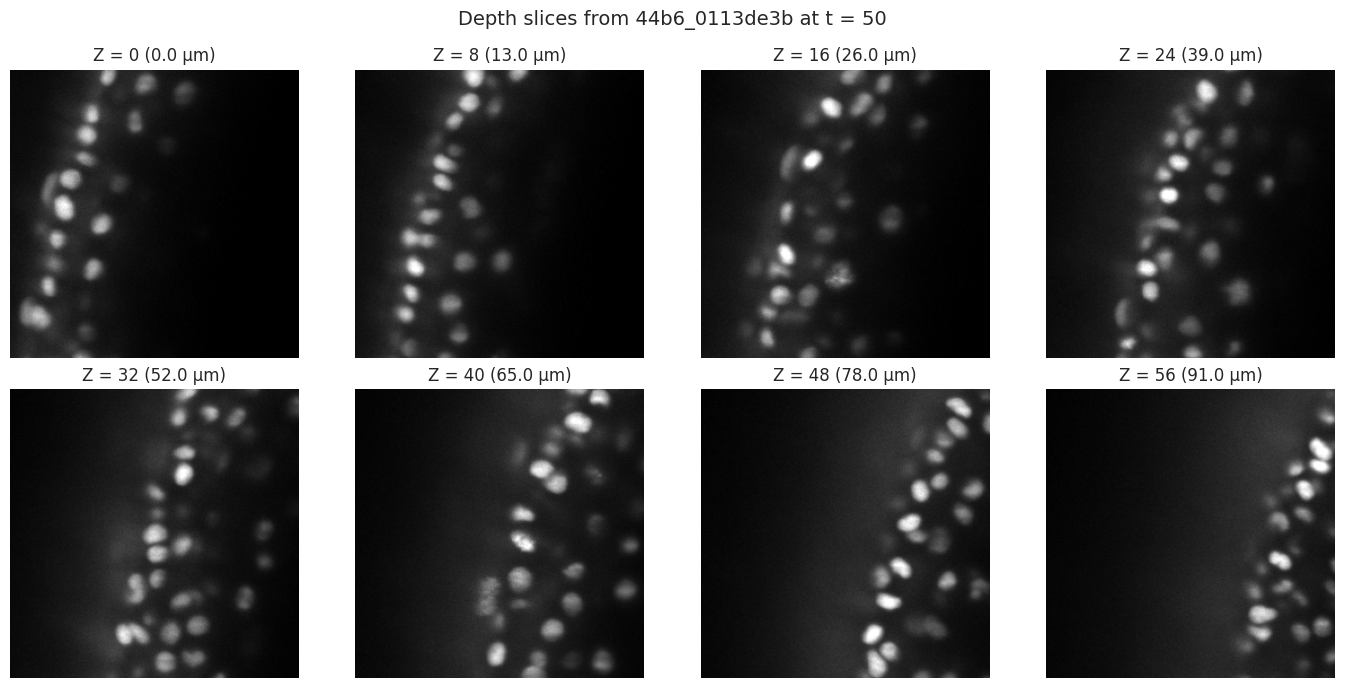

In [42]:
z_slices = [0, 8, 16, 24, 32, 40, 48, 56]

vmin = np.quantile(volume, 0.01)
vmax = np.quantile(volume, 0.999)

fig, axes = plt.subplots(
    2,
    4,
    figsize=(14, 7)
)

for ax, z_index in zip(axes.flat, z_slices):
    ax.imshow(
        volume[z_index],
        cmap="gray",
        vmin=vmin,
        vmax=vmax
    )

    ax.set_title(
        f"Z = {z_index} "
        f"({z_index * Z_SCALE:.1f} µm)"
    )

    ax.axis("off")

fig.suptitle(
    f"Depth slices from {sample_id} at t = {selected_t}",
    fontsize=14
)

plt.tight_layout()
plt.show()

### Visual Characteristics Across Depth

Bright cell-like structures are visible against the darker background, and many have distinct centres. Some structures appear close together or overlapping, while blurred boundaries make separation uncertain from individual 2D slices.

There is no obvious large change in apparent crowding across most of the displayed slices. However, this is only a visual impression and should not be interpreted as a measurement of 3D cell density. Cells extend across multiple depth slices, so the same cell may be visible repeatedly.

At higher Z-values, particularly Z = 48 and Z = 56, the region containing most of the bright structures shifts toward the right image boundary. Fewer structures are consequently visible within the field of view at these depths.

This inspection suggests that cell centres may be detectable as local intensity maxima, while blurred boundaries, close neighbours and boundary clipping are likely detection challenges.

## Maximum-Intensity Projections

A maximum-intensity projection replaces each line through the volume with its brightest voxel. This provides an overview of the fluorescent region without displaying all 64 depth slices individually.

Three projections are examined:

- XY: looking through the Z-axis;
- XZ: looking through the Y-axis;
- YZ: looking through the X-axis.

The projections help reveal the overall spatial shape, boundaries and bright structures. However, they remove depth information and can make cells at different depths appear to overlap.

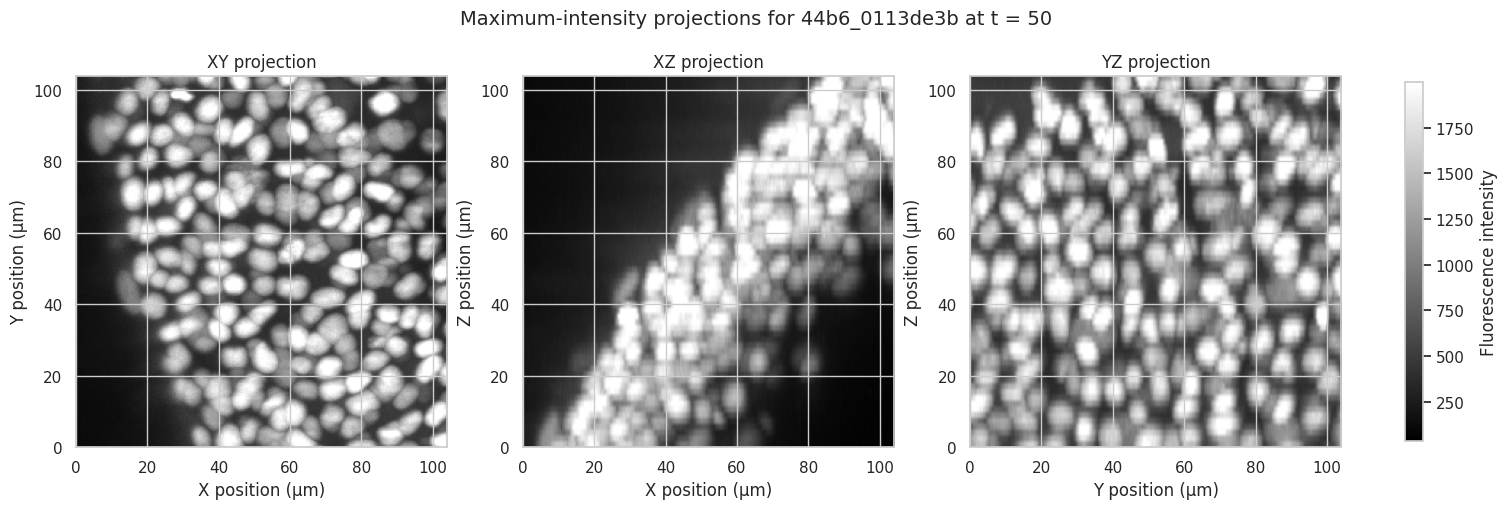

In [43]:
xy_projection = volume.max(axis=0)
xz_projection = volume.max(axis=1)
yz_projection = volume.max(axis=2)

x_extent = volume.shape[2] * X_SCALE
y_extent = volume.shape[1] * Y_SCALE
z_extent = volume.shape[0] * Z_SCALE

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 5),
    constrained_layout=True
)

projection_data = [
    (
        xy_projection,
        [0, x_extent, 0, y_extent],
        "XY projection",
        "X position (µm)",
        "Y position (µm)"
    ),
    (
        xz_projection,
        [0, x_extent, 0, z_extent],
        "XZ projection",
        "X position (µm)",
        "Z position (µm)"
    ),
    (
        yz_projection,
        [0, y_extent, 0, z_extent],
        "YZ projection",
        "Y position (µm)",
        "Z position (µm)"
    )
]

for ax, (
    projection,
    extent,
    title,
    xlabel,
    ylabel
) in zip(axes, projection_data):

    image = ax.imshow(
        projection,
        cmap="gray",
        origin="lower",
        extent=extent,
        vmin=vmin,
        vmax=vmax,
        aspect="equal"
    )

    ax.set(
        title=title,
        xlabel=xlabel,
        ylabel=ylabel
    )

fig.colorbar(
    image,
    ax=axes,
    shrink=0.8,
    label="Fluorescence intensity"
)

fig.suptitle(
    f"Maximum-intensity projections for {sample_id} at t = {selected_t}",
    fontsize=14
)

plt.show()

### Spatial Structure in the Maximum-Intensity Projections

In the XY projection, bright structures occupy most of the field, although the lower-left region is comparatively empty. Several structures meet the top, right and bottom image boundaries and appear partially clipped.

The XZ projection contains a pronounced diagonal band extending from the lower-left toward the upper-right. This confirms that the fluorescent region shifts toward larger X-values as Z increases. The centre of the band appears especially crowded, while fewer distinct structures are visible toward its right-hand edge.

In the YZ projection, bright structures are distributed across most of the field without a similarly large empty region. The absence of a strong diagonal pattern suggests that the position of the fluorescent region changes more systematically along X than along Y as depth increases.

These projections describe overall spatial support rather than true 3D cell density. Collapsing one spatial axis can superimpose structures that are separated in the original volume and exaggerate apparent crowding.

## Section Summary

- Bright cell-like structures are visible against the darker background, and many have distinct centres. This makes three-dimensional local-maximum detection a plausible starting baseline.
- Close neighbours, blurred boundaries and structures clipped by image boundaries are likely detection challenges.
- The fluorescent region is not distributed uniformly through the volume. In the XZ view it forms a pronounced diagonal band and shifts toward larger X-values as Z increases.
- Individual slices preserve local depth information, whereas maximum-intensity projections reveal overall spatial support but can exaggerate overlap and cannot measure true 3D cell density.

# Overlay Annotations on the Microscopy Image

The GEFF coordinates are overlaid on the image to verify that the annotation axes align with the Zarr array and that annotated centroids correspond to visible fluorescent structures.

Exact slices through an annotated coordinate are used instead of maximum-intensity projections. This avoids displaying unrelated bright structures from other depths at the annotated position.

## Select an Annotated Node

In [44]:
annotations_at_t = (
    nodes[nodes["t"] == selected_t]
    .copy()
    .sort_values("node_id")
)

print(
    f"Annotated nodes at t = {selected_t}:",
    len(annotations_at_t)
)

display(annotations_at_t)

Annotated nodes at t = 50: 1


,node_id,t,z,y,x
26,61000000003,50,32,128,128


In [45]:
if annotations_at_t.empty:
    raise ValueError(
        f"No annotated nodes found at t = {selected_t}"
    )

selected_node = annotations_at_t.iloc[0]

node_id = int(selected_node["node_id"])
node_z = int(selected_node["z"])
node_y = int(selected_node["y"])
node_x = int(selected_node["x"])

node_z_um = node_z * Z_SCALE
node_y_um = node_y * Y_SCALE
node_x_um = node_x * X_SCALE

print("Node ID:", node_id)
print("Voxel coordinates:", (node_z, node_y, node_x))
print(
    "Physical coordinates (µm):",
    (
        round(node_z_um, 2),
        round(node_y_um, 2),
        round(node_x_um, 2)
    )
)

Node ID: 61000000003
Voxel coordinates: (32, 128, 128)
Physical coordinates (µm): (52.0, 52.0, 52.0)


## Inspect the Annotated Cell from Three Directions

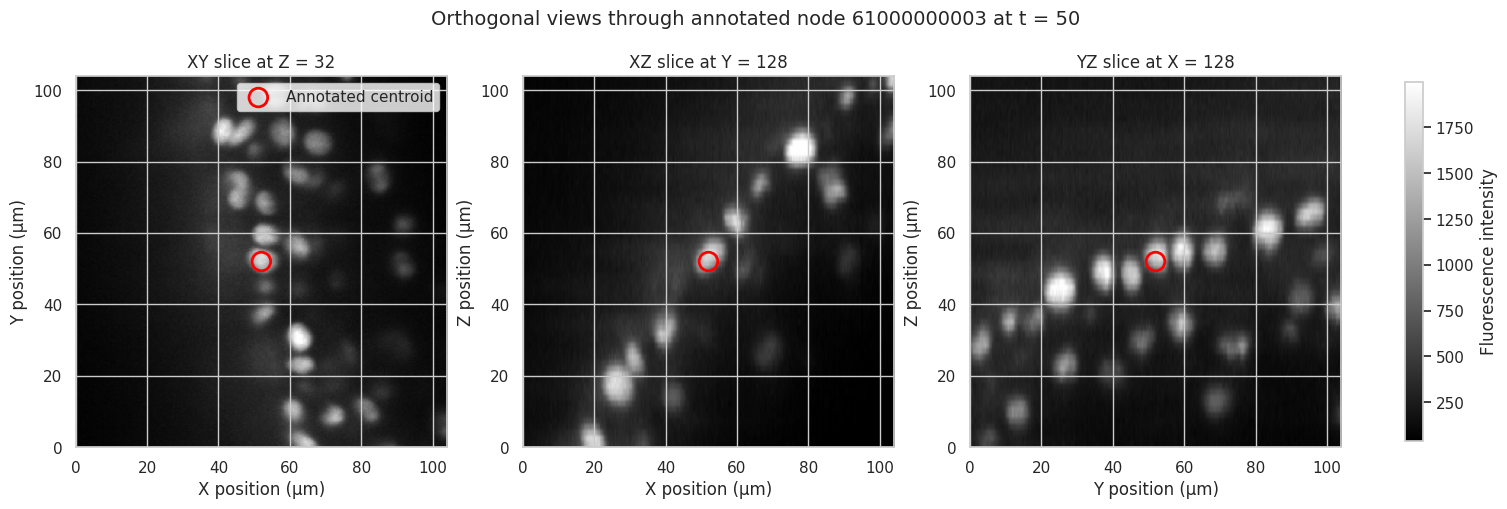

In [46]:
xy_slice = volume[node_z, :, :]
xz_slice = volume[:, node_y, :]
yz_slice = volume[:, :, node_x]

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 5),
    constrained_layout=True
)

slice_data = [
    (
        xy_slice,
        [0, x_extent, 0, y_extent],
        node_x_um,
        node_y_um,
        f"XY slice at Z = {node_z}",
        "X position (µm)",
        "Y position (µm)"
    ),
    (
        xz_slice,
        [0, x_extent, 0, z_extent],
        node_x_um,
        node_z_um,
        f"XZ slice at Y = {node_y}",
        "X position (µm)",
        "Z position (µm)"
    ),
    (
        yz_slice,
        [0, y_extent, 0, z_extent],
        node_y_um,
        node_z_um,
        f"YZ slice at X = {node_x}",
        "Y position (µm)",
        "Z position (µm)"
    )
]

for ax, (
    image_slice,
    extent,
    point_horizontal,
    point_vertical,
    title,
    xlabel,
    ylabel
) in zip(axes, slice_data):

    image = ax.imshow(
        image_slice,
        cmap="gray",
        origin="lower",
        extent=extent,
        vmin=vmin,
        vmax=vmax,
        aspect="equal"
    )

    ax.scatter(
        point_horizontal,
        point_vertical,
        s=180,
        facecolors="none",
        edgecolors="red",
        linewidths=2,
        label="Annotated centroid"
    )

    ax.set(
        title=title,
        xlabel=xlabel,
        ylabel=ylabel
    )

axes[0].legend(loc="upper right")

fig.colorbar(
    image,
    ax=axes,
    shrink=0.8,
    label="Fluorescence intensity"
)

fig.suptitle(
    f"Orthogonal views through annotated node {node_id} at t = {selected_t}",
    fontsize=14
)

plt.show()

### Annotation Alignment and Apparent Shape

The annotated centroid lies on a visible bright structure in all three orthogonal views.

The red circle is a symbolic centroid marker rather than an estimate of the cell boundary. Its displayed size is defined in plotting units and should not be compared with the physical size of the fluorescent structure.

The structure appears relatively compact in the XY view but more extended in the XZ and YZ views. This may reflect coarser sampling or greater imaging blur along the Z-axis, although a single example is insufficient to determine whether the difference is optical or biological.

## Check Annotation Alignment Across Time

Several nodes from the longer annotated trajectory are inspected to determine whether annotation centroids remain aligned with bright structures at different timepoints and positions.

Each panel shows an XY crop taken at the node's annotated Z-coordinate. Coordinates are displayed relative to the annotated centroid, which is positioned at `(0, 0)`.

In [47]:
long_component = (
    nodes_plot[nodes_plot["component"] == "1"]
    .sort_values("t")
)

selected_indices = np.linspace(
    0,
    len(long_component) - 1,
    6
).round().astype(int)

selected_annotations = (
    long_component.iloc[selected_indices]
    .reset_index(drop=True)
)

display(
    selected_annotations[
        ["node_id", "t", "z", "y", "x"]
    ]
)

,node_id,t,z,y,x
0,38000000003,27,1,74,73
1,48000000003,37,16,114,84
2,57000000003,46,29,118,107
3,67000000003,56,42,118,137
4,76000000003,65,53,126,164
5,86000000004,75,63,128,202


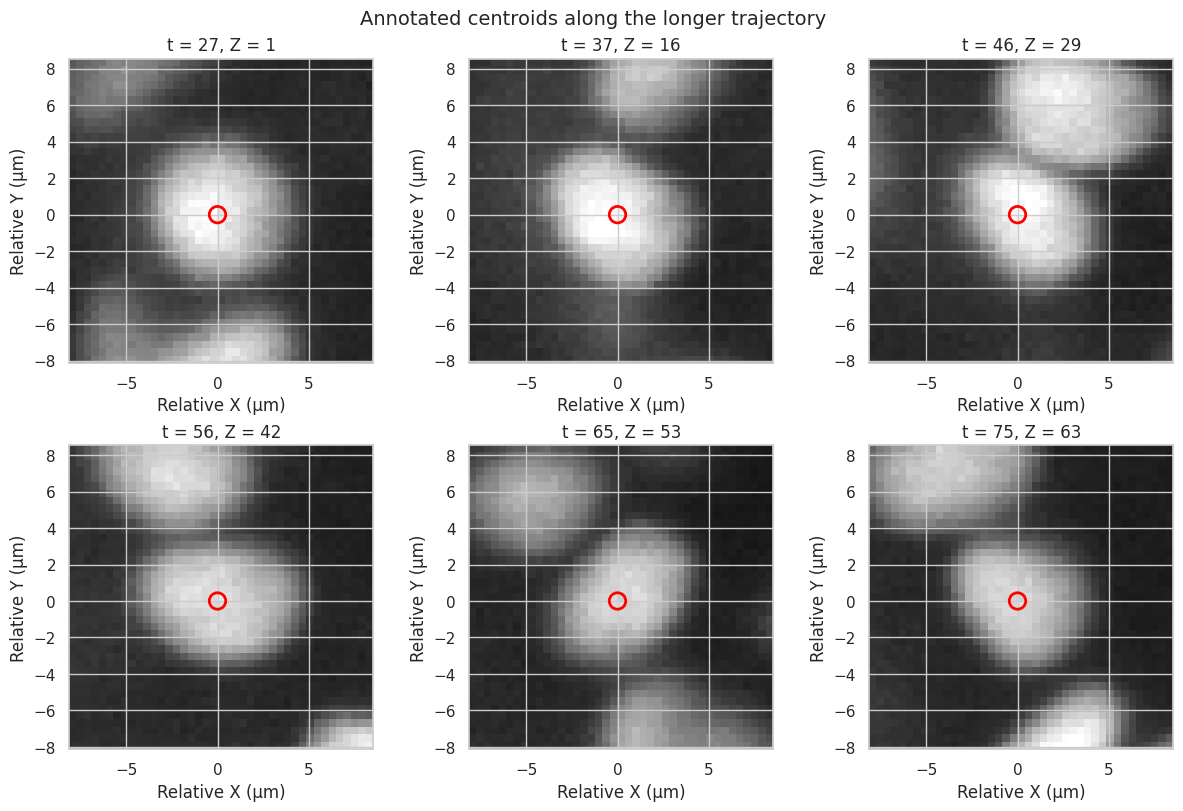

In [48]:
crop_radius = 20

fig, axes = plt.subplots(
    2,
    3,
    figsize=(12, 8),
    constrained_layout=True
)

for ax, row in zip(
    axes.flat,
    selected_annotations.itertuples(index=False)
):
    frame = np.asarray(image_array[int(row.t)])

    z = int(row.z)
    y = int(row.y)
    x = int(row.x)

    y_start = max(0, y - crop_radius)
    y_end = min(frame.shape[1], y + crop_radius + 1)

    x_start = max(0, x - crop_radius)
    x_end = min(frame.shape[2], x + crop_radius + 1)

    crop = frame[
        z,
        y_start:y_end,
        x_start:x_end
    ]

    extent = [
        (x_start - x) * X_SCALE,
        (x_end - x) * X_SCALE,
        (y_start - y) * Y_SCALE,
        (y_end - y) * Y_SCALE
    ]

    ax.imshow(
        crop,
        cmap="gray",
        origin="lower",
        extent=extent,
        vmin=vmin,
        vmax=vmax
    )

    ax.scatter(
        0,
        0,
        s=140,
        facecolors="none",
        edgecolors="red",
        linewidths=2
    )

    ax.set(
        title=f"t = {row.t}, Z = {row.z}",
        xlabel="Relative X (µm)",
        ylabel="Relative Y (µm)"
    )

fig.suptitle(
    "Annotated centroids along the longer trajectory",
    fontsize=14
)

plt.show()

### Annotation Alignment Across Time

All six sampled annotations are closely aligned with the bright central region of their corresponding structures. The alignment remains consistent as the trajectory moves through time and across the image volume.

Nearby bright structures appear in several crops, but the annotated target remains visually distinguishable. This supports the interpretation of the GEFF coordinates and suggests that annotated centroids correspond closely to local fluorescence maxima.

The six observations belong to one trajectory and should not be treated as six independent cells.

## Section Summary

- The Zarr image axes and GEFF annotation coordinates appear to be aligned correctly for the selected movie.
- The annotated centroid lies on a bright cellular structure in all three orthogonal views, and the sampled trajectory centroids remain closely aligned with bright structures through time.
- Structures appear more extended in views containing the Z-axis, potentially because Z is sampled more coarsely or has greater axial blur.
- These checks support interpreting GEFF nodes as positive cell-centroid annotations. However, the temporal samples come from one trajectory, so alignment should later be checked across additional movies and graph components.

# Explore Intensity Variation Across Movies and Time

The microscopy intensities are now examined across movies, dataset groups and timepoints. This analysis investigates whether one raw intensity scale can be used throughout the dataset and motivates the normalisation strategies that will later be tested through validation.

## Compare Intensity Quantiles Across Movies

Each Zarr store contains precomputed movie-level intensity quantiles. These summaries are used to examine whether fluorescence brightness and dynamic range differ across movies and dataset groups without loading every image volume.

Large between-movie differences would suggest that detection thresholds should be based on normalised or relative intensities rather than one fixed raw intensity value.

In [49]:
intensity_records = []

for zarr_path in train_zarr:
    sample_id_current = zarr_path.stem

    store = zarr.open(
        str(zarr_path),
        mode="r"
    )

    quantiles = (
        store.attrs["image_statistics"]["quantiles"]
    )

    intensity_records.append({
        "sample_id": sample_id_current,
        "intensity_min": float(quantiles["0.0"]),
        "intensity_p001": float(quantiles["0.001"]),
        "intensity_p01": float(quantiles["0.01"]),
        "intensity_p10": float(quantiles["0.1"]),
        "intensity_p90": float(quantiles["0.9"]),
        "intensity_p99": float(quantiles["0.99"]),
        "intensity_p999": float(quantiles["0.999"]),
        "intensity_max": float(quantiles["1.0"])
    })

intensity_metadata = pd.DataFrame(
    intensity_records
)

movie_metadata = movie_metadata.merge(
    intensity_metadata,
    on="sample_id",
    how="left",
    validate="one_to_one"
)

display(intensity_metadata.head())

,sample_id,intensity_min,intensity_p001,intensity_p01,intensity_p10,intensity_p90,intensity_p99,intensity_p999,intensity_max
0,44b6_0113de3b,15.0,26.222222,38.0,75.0,497.000000,1478.000000,2145.000000,4319.0
1,44b6_0b24845f,23.0,38.000000,84.0,1095.0,2520.833333,2902.377778,3199.333333,3867.0
2,44b6_0c582fdc,52.0,80.000000,112.0,177.0,1487.000000,2185.500000,2702.888889,4388.0
3,44b6_0db75fae,0.0,0.000000,0.0,44.0,1149.275000,1769.000000,2173.666667,2982.0
4,44b6_12dfb391,50.0,70.000000,133.0,307.0,1453.000000,2247.000000,3065.000000,5262.0


In [50]:
intensity_columns = [
    "intensity_min",
    "intensity_p001",
    "intensity_p01",
    "intensity_p10",
    "intensity_p90",
    "intensity_p99",
    "intensity_p999",
    "intensity_max"
]

display(
    movie_metadata[intensity_columns]
    .describe()
)

,intensity_min,intensity_p001,intensity_p01,intensity_p10,intensity_p90,intensity_p99,intensity_p999,intensity_max
count,199.000000,199.000000,199.000000,199.000000,199.000000,199.000000,199.000000,199.000000
mean,21.381910,33.758794,53.342490,138.896015,917.983779,1465.811867,1993.855039,3535.326633
std,29.422126,42.255733,68.843579,197.684142,765.570870,932.443385,1084.410784,2140.480346
min,0.000000,0.000000,0.000000,0.000000,112.000000,368.000000,615.000000,1010.000000
25%,6.000000,13.111111,22.000000,37.000000,318.106250,710.800000,1173.500000,2150.500000
50%,14.000000,23.000000,33.000000,61.000000,665.182500,1176.900000,1632.000000,3050.000000
75%,25.000000,39.000000,56.500000,124.500000,1284.500000,1943.900000,2602.166667,4292.500000
max,308.000000,465.222222,627.400000,1323.000000,3569.000000,4595.922222,5398.111111,18827.000000


In [51]:
display(
    movie_metadata
    .groupby("group")[intensity_columns]
    .median()
    .round(1)
)

,intensity_min,intensity_p001,intensity_p01,intensity_p10,intensity_p90,intensity_p99,intensity_p999,intensity_max
group,,,,,,,,
44b6,19.0,35.0,51.0,121.0,1294.0,1958.3,2661.0,4030.0
6bba,12.5,20.0,28.0,49.0,451.9,836.1,1437.5,2661.5


### Initial Findings from Stored Intensity Quantiles

Raw fluorescence intensity varies substantially across the 199 movies. A fixed threshold in raw intensity units is therefore unlikely to behave consistently across the dataset.

The `44b6` movies generally have higher intensity quantiles than the `6bba` movies. Median P90 intensity is approximately 1,294 for `44b6`, compared with 452 for `6bba`.

Movie maxima are especially variable, ranging from 1,010 to 18,827. Because a maximum may be determined by a single unusual voxel, high percentiles are likely to be more reliable than minima and maxima for future intensity normalisation.

Quantile differences do not measure acquisition brightness alone. They may also reflect variation in the proportion of each volume occupied by fluorescent structures.

### Upper-Intensity Quantiles by Dataset Group

The upper quantiles are compared on a logarithmic scale because their values vary multiplicatively across movies. The plot is intended to compare intensity levels rather than assess distributional skewness.

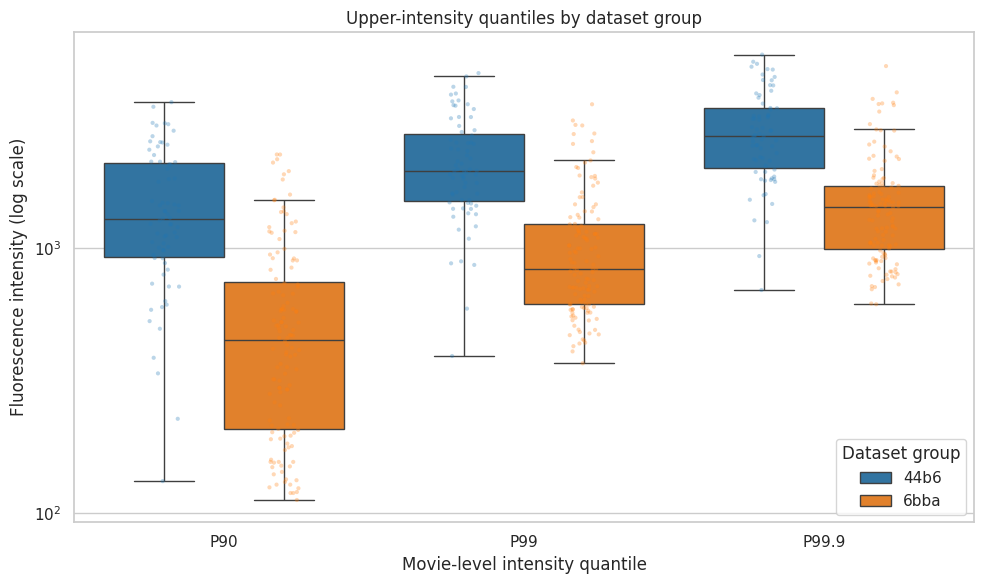

In [52]:
upper_quantile_names = {
    "intensity_p90": "P90",
    "intensity_p99": "P99",
    "intensity_p999": "P99.9"
}

intensity_long = (
    movie_metadata
    .melt(
        id_vars=["sample_id", "group", "is_test_movie"],
        value_vars=list(upper_quantile_names),
        var_name="quantile",
        value_name="intensity"
    )
)

intensity_long["quantile"] = (
    intensity_long["quantile"]
    .map(upper_quantile_names)
)

quantile_order = ["P90", "P99", "P99.9"]

plt.figure(figsize=(10, 6))

ax = sns.boxplot(
    data=intensity_long,
    x="quantile",
    y="intensity",
    hue="group",
    order=quantile_order,
    hue_order=["44b6", "6bba"],
    palette=group_palette,
    showfliers=False
)

sns.stripplot(
    data=intensity_long,
    x="quantile",
    y="intensity",
    hue="group",
    order=quantile_order,
    hue_order=["44b6", "6bba"],
    dodge=True,
    palette=group_palette,
    alpha=0.3,
    size=3,
    legend=False,
    ax=ax
)

ax.set_yscale("log")

ax.set(
    title="Upper-intensity quantiles by dataset group",
    xlabel="Movie-level intensity quantile",
    ylabel="Fluorescence intensity (log scale)"
)

ax.legend(title="Dataset group")

plt.tight_layout()
plt.show()

### Differences in Upper-Intensity Levels

At P90, P99 and P99.9, the interquartile ranges of `44b6` and `6bba` do not overlap. The central 50% of `44b6` movies has higher intensity values at every displayed quantile.

Individual observations and whiskers do overlap, so the groups are not completely separated by these intensity summaries.

The ratio between the group medians decreases from approximately 2.86 at P90 to 1.85 at P99.9. The difference between groups therefore becomes smaller in relative terms toward the most intense part of the distribution.

### Test-Movie Intensity Percentiles

The upper-intensity quantiles of each test movie are ranked relative to movies from the same dataset group. This determines whether the test movies have typical or unusual intensity levels for their group.

In [53]:
test_intensity_columns = [
    "intensity_p90",
    "intensity_p99",
    "intensity_p999"
]

for column in test_intensity_columns:
    movie_metadata[f"{column}_group_percentile"] = (
        100
        * movie_metadata.groupby("group")[column]
        .rank(pct=True)
    )

test_intensity_summary = movie_metadata.loc[
    movie_metadata["is_test_movie"],
    [
        "sample_id",
        "group",
        "intensity_p90",
        "intensity_p90_group_percentile",
        "intensity_p99",
        "intensity_p99_group_percentile",
        "intensity_p999",
        "intensity_p999_group_percentile"
    ]
]

display(
    test_intensity_summary.round(1)
)

,sample_id,group,intensity_p90,intensity_p90_group_percentile,intensity_p99,intensity_p99_group_percentile,intensity_p999,intensity_p999_group_percentile
0,44b6_0113de3b,44b6,497.0,7.0,1478.0,22.5,2145.0,28.2
1,44b6_0b24845f,44b6,2520.8,87.3,2902.4,78.9,3199.3,71.8
71,6bba_05b6850b,6bba,215.0,27.3,769.0,44.5,1478.0,55.5
72,6bba_05db0fb1,6bba,1597.0,94.5,2307.0,93.8,3511.0,96.1


### Test Movies Span Different Intensity Regimes

The four test movies occupy substantially different positions within their respective group distributions.

`44b6_0113de3b` is relatively dim, particularly at P90, while `44b6_0b24845f` is relatively bright. Similarly, `6bba_05b6850b` ranges from below average at P90 to approximately average at P99.9, whereas `6bba_05db0fb1` lies above the 93rd percentile at all three intensity levels.

Therefore, accounting for dataset group alone will not produce consistent image intensities. Future detection methods will probably require movie- or frame-specific normalisation.

The change in ranks across quantiles also suggests that intensity differences cannot always be described by one constant scaling factor. Differences in contrast or the proportion of bright structures may also be involved.

## Compare Test Movies Before and After Normalisation

Maximum-intensity projections from the four test movies are displayed using two intensity treatments:

- a shared raw scale, which preserves brightness differences between movies;
- movie-specific percentile normalisation, which emphasises structural appearance independently of raw intensity scale.

This comparison shows what information normalisation removes and what variation remains afterwards.

In [54]:
test_frame_data = {}

for test_path in test_zarr:
    test_id = test_path.stem

    test_array = zarr.open(
        str(test_path),
        mode="r"
    )["0"]

    test_volume = np.asarray(
        test_array[selected_t]
    )

    test_frame_data[test_id] = {
        "volume": test_volume,
        "xy_projection": test_volume.max(axis=0)
    }

In [55]:
test_metadata_indexed = (
    movie_metadata[
        movie_metadata["is_test_movie"]
    ]
    .set_index("sample_id")
)

shared_vmin = (
    test_metadata_indexed["intensity_p01"].min()
)

shared_vmax = (
    test_metadata_indexed["intensity_p999"].max()
)

print("Shared minimum:", shared_vmin)
print("Shared maximum:", shared_vmax)

Shared minimum: 12.0
Shared maximum: 3511.0


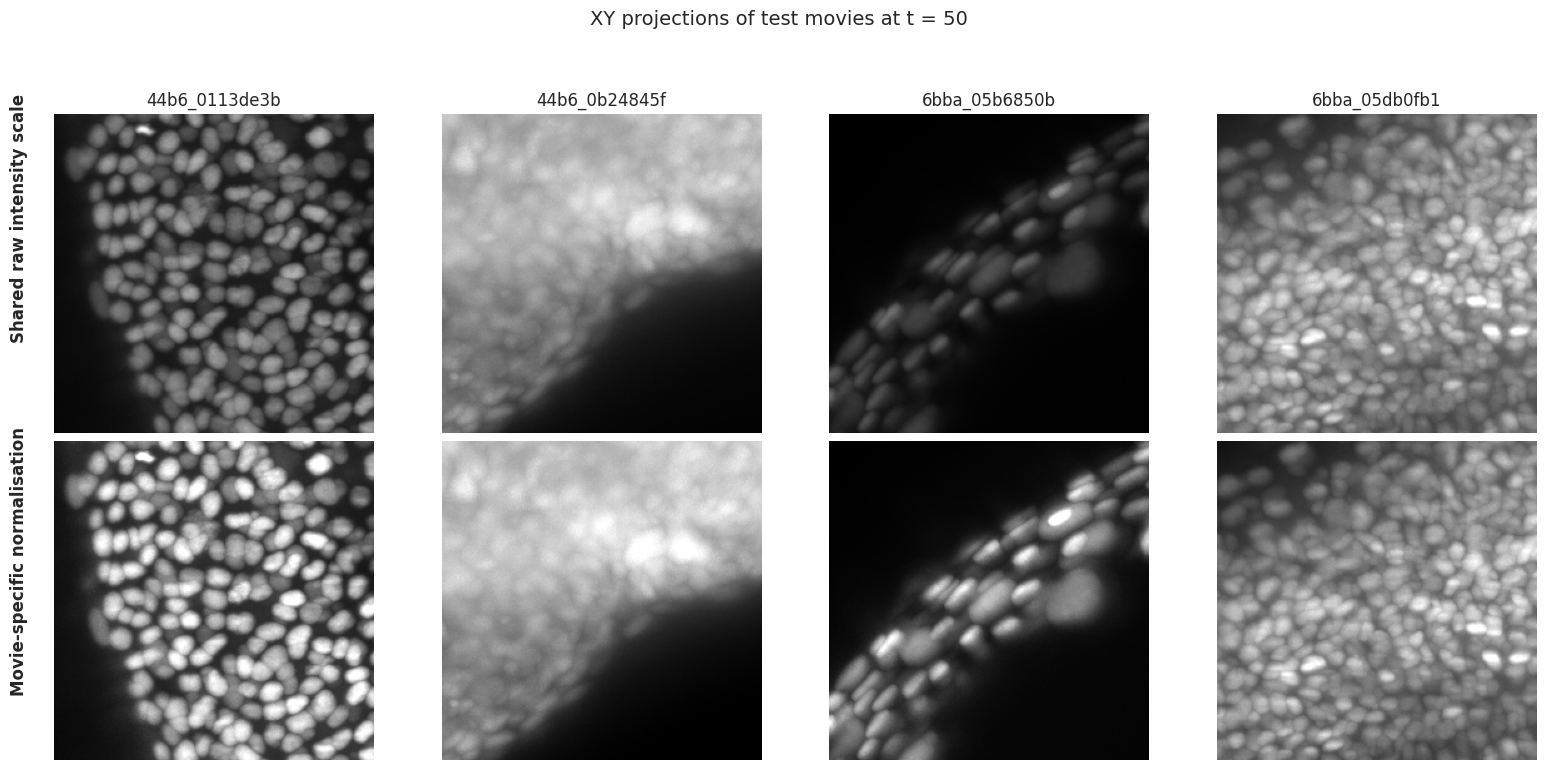

In [56]:
test_order = [
    "44b6_0113de3b",
    "44b6_0b24845f",
    "6bba_05b6850b",
    "6bba_05db0fb1"
]

fig, axes = plt.subplots(
    2,
    4,
    figsize=(16, 8),
    constrained_layout=False
)

for column, test_id in enumerate(test_order):
    projection = (
        test_frame_data[test_id]["xy_projection"]
    )

    metadata_row = test_metadata_indexed.loc[test_id]

    movie_vmin = metadata_row["intensity_p01"]
    movie_vmax = metadata_row["intensity_p999"]

    normalised_projection = np.clip(
        (projection - movie_vmin)
        / (movie_vmax - movie_vmin),
        0,
        1
    )

    axes[0, column].imshow(
        projection,
        cmap="gray",
        origin="lower",
        vmin=shared_vmin,
        vmax=shared_vmax
    )

    axes[1, column].imshow(
        normalised_projection,
        cmap="gray",
        origin="lower",
        vmin=0,
        vmax=1
    )

    axes[0, column].set_title(test_id)

    for row in range(2):
        axes[row, column].axis("off")

fig.text(
    0.025,
    0.72,
    "Shared raw intensity scale",
    rotation=90,
    va="center",
    ha="center",
    fontsize=12,
    fontweight="bold"
)

fig.text(
    0.025,
    0.29,
    "Movie-specific normalisation",
    rotation=90,
    va="center",
    ha="center",
    fontsize=12,
    fontweight="bold"
)

fig.suptitle(
    f"XY projections of test movies at t = {selected_t}",
    fontsize=14
)

plt.tight_layout(
    rect=[0.02, 0.02, 1, 0.94]
)

plt.show()

### Effect of Movie-Specific Normalisation

Movie-specific normalisation makes structures noticeably brighter and clearer in `44b6_0113de3b` and `6bba_05b6850b`, which have relatively low upper-intensity quantiles within their groups.

The raw and normalised projections are much more similar for `44b6_0b24845f` and `6bba_05db0fb1`. These movies already have upper-intensity values close to the shared display maximum.

Normalisation does not recover new image information. It rescales the existing intensity range and may also amplify background noise. Its effect on cell detection must therefore be evaluated rather than assumed to be beneficial.

## Examine Intensity Stability Through Time

Intensity variation is examined at every fifth timepoint in each test movie. A spatially subsampled set of voxels is used to make the calculation efficient.

The analysis asks whether movie-level intensity quantiles remain stable, increase or decrease over time. Temporal changes could result from imaging effects, movement of fluorescent structures through the field of view or changes in the proportion of the volume occupied by those structures.

In [57]:
sampled_timepoints = range(0, 100, 5)

temporal_intensity_records = []

for test_path in test_zarr:
    test_id = test_path.stem

    image_data = zarr.open(
        str(test_path),
        mode="r"
    )["0"]

    for t in sampled_timepoints:
        frame = np.asarray(image_data[t])

        # Use a regular spatial subsample
        sampled_voxels = frame[
            ::2,
            ::4,
            ::4
        ].ravel()

        p10, p50, p90, p99 = np.quantile(
            sampled_voxels,
            [0.10, 0.50, 0.90, 0.99]
        )

        temporal_intensity_records.append({
            "sample_id": test_id,
            "group": test_id.split("_")[0],
            "t": t,
            "intensity_p10": p10,
            "intensity_p50": p50,
            "intensity_p90": p90,
            "intensity_p99": p99
        })

temporal_intensity = pd.DataFrame(
    temporal_intensity_records
)

print("Shape:", temporal_intensity.shape)
display(temporal_intensity.head())

Shape: (80, 7)


,sample_id,group,t,intensity_p10,intensity_p50,intensity_p90,intensity_p99
0,44b6_0113de3b,44b6,0,63.0,154.0,389.0,1272.29
1,44b6_0113de3b,44b6,5,63.0,156.0,392.0,1313.29
2,44b6_0113de3b,44b6,10,62.0,166.0,412.0,1380.00
3,44b6_0113de3b,44b6,15,62.0,171.0,429.0,1400.00
4,44b6_0113de3b,44b6,20,69.0,177.0,431.0,1402.00


In [58]:
temporal_summary = (
    temporal_intensity
    .groupby("sample_id")
    .agg(
        p90_min=("intensity_p90", "min"),
        p90_max=("intensity_p90", "max"),
        p90_mean=("intensity_p90", "mean"),
        p90_std=("intensity_p90", "std"),
        p99_min=("intensity_p99", "min"),
        p99_max=("intensity_p99", "max"),
        p99_mean=("intensity_p99", "mean"),
        p99_std=("intensity_p99", "std")
    )
)

temporal_summary["p90_cv"] = (
    temporal_summary["p90_std"]
    / temporal_summary["p90_mean"]
)

temporal_summary["p99_cv"] = (
    temporal_summary["p99_std"]
    / temporal_summary["p99_mean"]
)

display(
    temporal_summary[
        [
            "p90_min",
            "p90_max",
            "p90_cv",
            "p99_min",
            "p99_max",
            "p99_cv"
        ]
    ].round(3)
)

,p90_min,p90_max,p90_cv,p99_min,p99_max,p99_cv
sample_id,,,,,,
44b6_0113de3b,389.0,494.0,0.072,1174.29,1453.00,0.061
44b6_0b24845f,1548.0,2537.0,0.137,1918.00,2923.00,0.112
6bba_05b6850b,169.0,212.0,0.066,621.00,767.29,0.053
6bba_05db0fb1,1481.0,1588.0,0.019,2153.29,2303.00,0.018


### Initial Temporal-Variability Findings

Temporal intensity stability differs between the four test movies. `6bba_05db0fb1` is particularly stable, with coefficients of variation below 2% for both P90 and P99.

`44b6_0b24845f` is the most variable test movie. Its P90 intensity ranges from 1,548 to 2,537 and has a coefficient of variation of approximately 13.7%.

The remaining two movies have intermediate variability of approximately 5%–7%. P99 is slightly more stable than P90 in all four movies.

These summaries measure the amount of variation but do not distinguish steady temporal trends from short-term fluctuations.

### Relative Intensity Through Time

Each movie’s P90 and P99 values are divided by its own temporal median. A value of 1 represents the movie’s typical intensity level, while 1.2 represents an intensity 20% above its temporal median.

This removes the large baseline differences between movies and allows their temporal patterns to be compared on one scale.

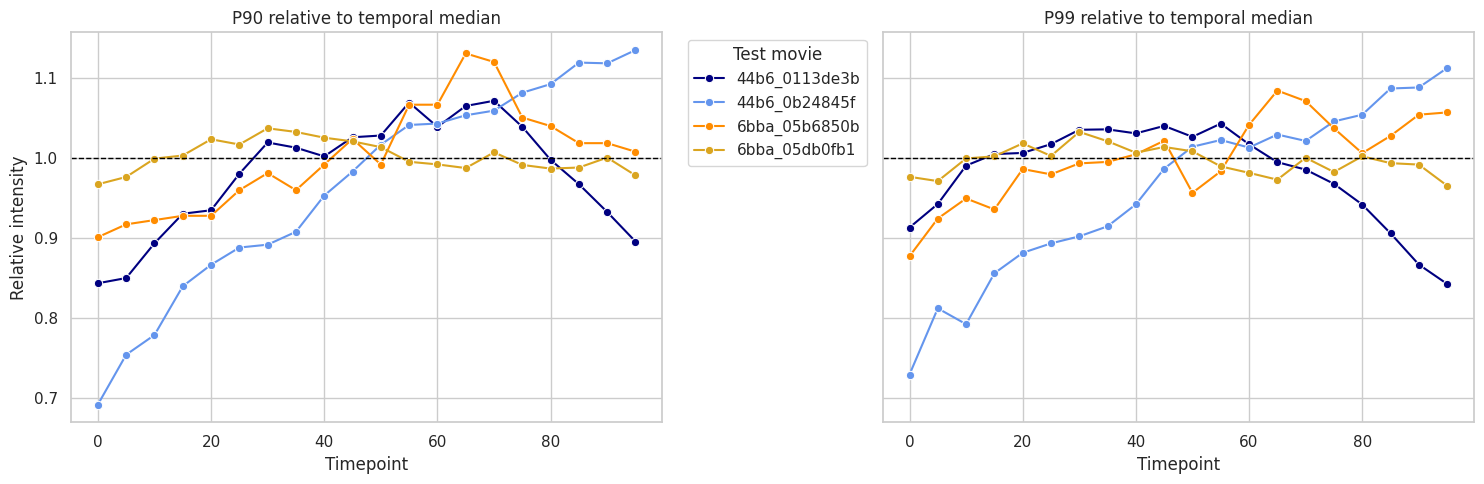

In [59]:
for column in ["intensity_p90", "intensity_p99"]:
    temporal_intensity[f"{column}_relative"] = (
        temporal_intensity[column]
        / temporal_intensity.groupby("sample_id")[column]
        .transform("median")
    )

test_movie_palette = {
    "44b6_0113de3b": "navy",
    "44b6_0b24845f": "cornflowerblue",
    "6bba_05b6850b": "darkorange",
    "6bba_05db0fb1": "goldenrod"
}

fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 5),
    sharey=True
)

plot_settings = [
    (
        "intensity_p90_relative",
        "P90 relative to temporal median"
    ),
    (
        "intensity_p99_relative",
        "P99 relative to temporal median"
    )
]

for ax, (column, title) in zip(
    axes,
    plot_settings
):
    sns.lineplot(
        data=temporal_intensity,
        x="t",
        y=column,
        hue="sample_id",
        hue_order=test_order,
        palette=test_movie_palette,
        marker="o",
        ax=ax,
        legend=(ax is axes[0])
    )

    ax.axhline(
        1,
        color="black",
        linestyle="--",
        linewidth=1
    )

    ax.set(
        title=title,
        xlabel="Timepoint",
        ylabel="Relative intensity"
    )

axes[0].legend(
    title="Test movie",
    bbox_to_anchor=(1.03, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

### Temporal Patterns in Upper Intensities

P90 and P99 follow broadly similar temporal patterns within each test movie. This indicates that the observed changes affect a substantial part of the upper-intensity distribution rather than only a small number of extreme voxels.

`44b6_0b24845f` shows a strong, approximately steady increase through time. `44b6_0113de3b` initially increases before declining after approximately timepoint 65. `6bba_05b6850b` contains a temporary peak around timepoints 60–65, while `6bba_05db0fb1` remains comparatively stable.

These trends do not identify their cause. They could reflect changes in acquisition intensity, movement of fluorescent structures through the image volume or changes in the proportion of the volume occupied by bright structures.

### Lower and Central Intensities Through Time

P10 and P50 are examined to determine whether temporal changes also affect the darker and central parts of the intensity distribution.

If P10, P50, P90 and P99 follow similar relative trajectories, the movie may be undergoing a broad intensity shift. If only the upper quantiles change, variation in fluorescent structures or foreground occupancy is a more plausible explanation.

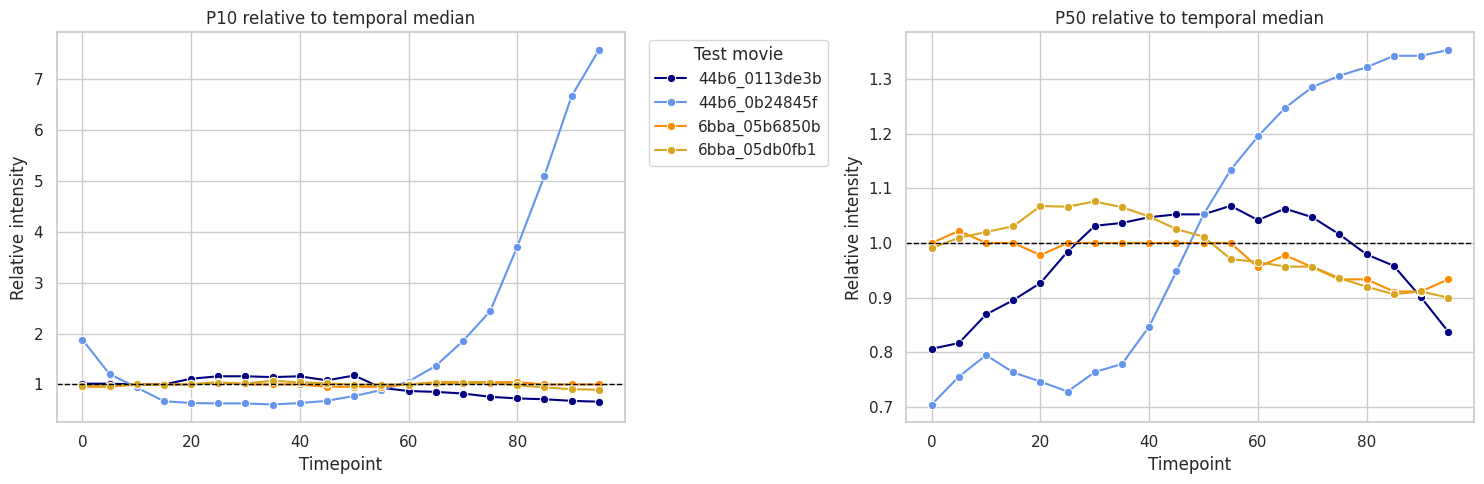

In [60]:
for column in ["intensity_p10", "intensity_p50"]:
    temporal_median = (
        temporal_intensity
        .groupby("sample_id")[column]
        .transform("median")
    )

    temporal_intensity[f"{column}_relative"] = np.where(
        temporal_median > 0,
        temporal_intensity[column] / temporal_median,
        np.nan
    )

fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 5),
    sharey=False
)

lower_plot_settings = [
    (
        "intensity_p10_relative",
        "P10 relative to temporal median"
    ),
    (
        "intensity_p50_relative",
        "P50 relative to temporal median"
    )
]

for ax, (column, title) in zip(
    axes,
    lower_plot_settings
):
    sns.lineplot(
        data=temporal_intensity,
        x="t",
        y=column,
        hue="sample_id",
        hue_order=test_order,
        palette=test_movie_palette,
        marker="o",
        ax=ax,
        legend=(ax is axes[0])
    )

    ax.axhline(
        1,
        color="black",
        linestyle="--",
        linewidth=1
    )

    ax.set(
        title=title,
        xlabel="Timepoint",
        ylabel="Relative intensity"
    )

axes[0].legend(
    title="Test movie",
    bbox_to_anchor=(1.03, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

### Temporal Changes Differ Across the Intensity Distribution

Temporal patterns differ across P10, P50, P90 and P99, so the observed variation cannot be described as one uniform multiplicative change in image brightness.

`44b6_0b24845f` shows the most striking behaviour. Its P50, P90 and P99 intensities increase through time, while P10 undergoes a much larger late increase. This may indicate a change in the proportion of the volume occupied by low-intensity background rather than an equivalent increase in every voxel. P10 marks the boundary of the darkest 10% of voxels. If background occupies less than 10% of the volume later in the movie, P10 begins to include brighter tissue voxels and can increase sharply even if the remaining background does not become brighter.

`44b6_0113de3b` displays an increase followed by a decrease in its central and upper quantiles. Its P10 instead declines more steadily during the later timepoints.

The `6bba` movies have comparatively stable P10 values, while their P50 and upper quantiles still change. This provides further evidence that the shapes of the intensity distributions evolve through time.

Frame-specific percentile normalisation could compensate for these changes, but it might also remove meaningful changes in tissue occupancy or contrast. Its value must therefore be assessed through validation.

## Investigate the Temporal Change in `44b6_0b24845f`

The unusually large change in P10 is examined in raw intensity units and through fixed-scale projections. This helps distinguish a genuine whole-image brightness increase from a change in the amount of low-intensity background.

In [61]:
focus_id = "44b6_0b24845f"
focus_timepoints = [0, 20, 40, 60, 80, 95]

display(
    temporal_intensity.loc[
        (temporal_intensity["sample_id"] == focus_id)
        & temporal_intensity["t"].isin(focus_timepoints),
        [
            "t",
            "intensity_p10",
            "intensity_p50",
            "intensity_p90",
            "intensity_p99"
        ]
    ].reset_index(drop=True)
)

,t,intensity_p10,intensity_p50,intensity_p90,intensity_p99
0,0,258.0,1006.0,1548.0,1918.00
1,20,87.0,1066.0,1938.0,2317.00
2,40,87.0,1210.0,2131.0,2476.00
3,60,145.0,1707.0,2332.0,2662.29
4,80,508.0,1888.0,2442.0,2770.00
5,95,1038.0,1933.0,2537.0,2923.00


### Fixed-Scale Mean Projections Through Time

Mean-intensity projections are displayed using one shared scale across all selected timepoints. Unlike frame-specific scaling, this preserves temporal differences in brightness and background occupancy.

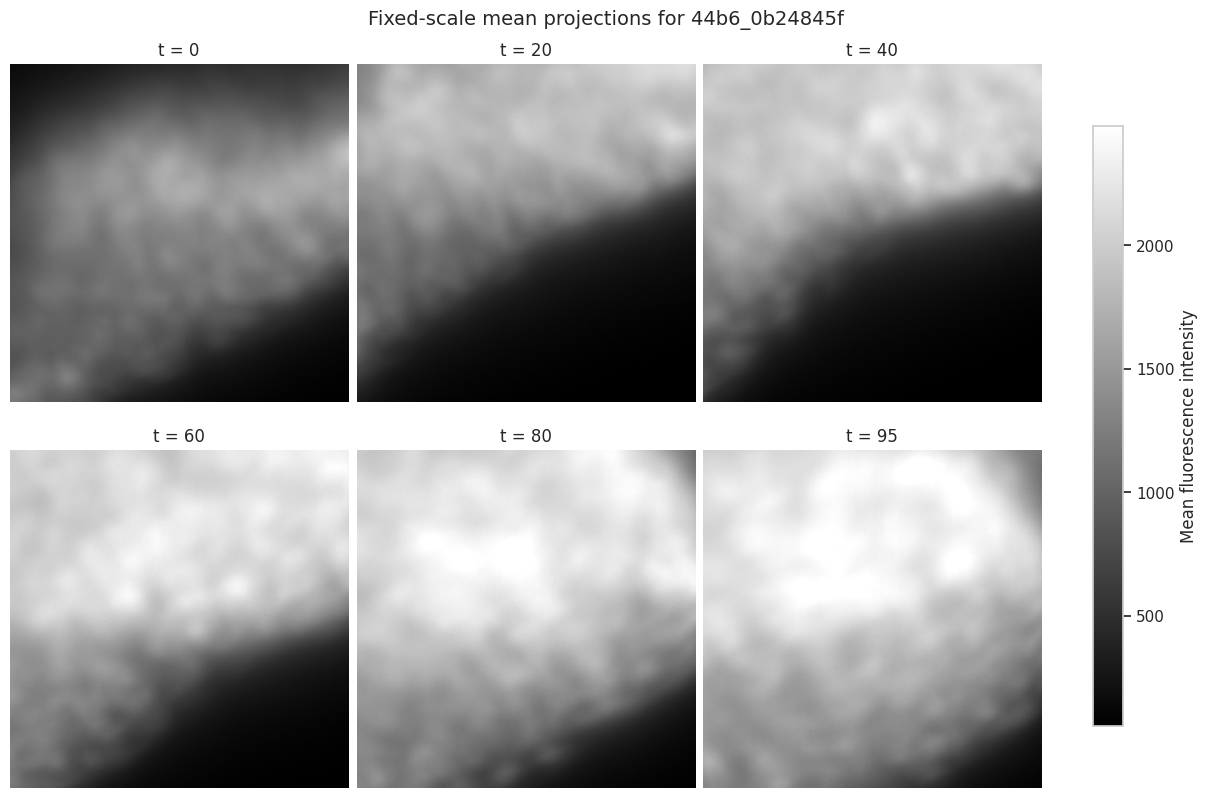

In [62]:
focus_array = zarr.open(
    str(test_root / f"{focus_id}.zarr"),
    mode="r"
)["0"]

mean_projections = []

for t in focus_timepoints:
    frame = np.asarray(focus_array[t])
    mean_projections.append(
        frame.mean(axis=0)
    )

mean_projection_stack = np.stack(
    mean_projections
)

projection_vmin = np.quantile(
    mean_projection_stack,
    0.01
)

projection_vmax = np.quantile(
    mean_projection_stack,
    0.99
)

fig, axes = plt.subplots(
    2,
    3,
    figsize=(12, 8),
    constrained_layout=True
)

for ax, t, projection in zip(
    axes.flat,
    focus_timepoints,
    mean_projections
):
    image = ax.imshow(
        projection,
        cmap="gray",
        origin="lower",
        vmin=projection_vmin,
        vmax=projection_vmax
    )

    ax.set_title(f"t = {t}")
    ax.axis("off")

fig.colorbar(
    image,
    ax=axes,
    shrink=0.8,
    label="Mean fluorescence intensity"
)

fig.suptitle(
    f"Fixed-scale mean projections for {focus_id}",
    fontsize=14
)

plt.show()

### Interpretation of the P10 Increase

The fixed-scale mean projections show that the dark region becomes smaller during the later timepoints. By timepoint 95, fluorescent tissue occupies most of the projected field, leaving only a relatively small dark region toward the lower-right.

This supports the explanation that P10 rises partly because low-intensity background accounts for a smaller proportion of the volume. Once background occupies less than approximately 10%, P10 begins to include brighter tissue voxels.

However, tissue occupancy is not the only change. P50, P90 and P99 also increase from timepoint 20 onward, and the fluorescent region becomes brighter on the shared display scale. The temporal variation therefore appears to involve both changing spatial occupancy and changing intensity levels.

The mean projections provide supporting visual evidence but do not measure the exact proportion of tissue in the complete 3D volume.

## Section Summary

- Raw fluorescence intensity varies substantially between movies. The two dataset groups also have clearly different upper-intensity distributions, making one fixed raw detection threshold unlikely to work consistently.
- Considerable variation remains within each group, and the four test movies occupy very different within-group intensity percentiles. Group-specific scaling alone is therefore unlikely to be sufficient.
- Movie-specific normalisation makes structures easier to see in the dimmer test movies, but it may also amplify noise and does not account for changes occurring within a movie.
- Temporal changes differ across P10, P50, P90 and P99, so they cannot generally be represented by one uniform brightness multiplier.
- In `44b6_0b24845f`, the large late increase in P10 appears to reflect both a reduction in the proportion of low-intensity background and an increase in tissue intensity.
- Movie-level and frame-level normalisation are therefore reasonable candidates, but their effect on detection and tracking must be compared through validation.

# Dataset-Level Graph EDA

The initial graph investigation examined one sparse annotation graph containing two simple directed paths. This section expands the analysis to all 199 training graphs.

The main questions are:

- Are all annotation graphs directed acyclic graphs?
- How many connected components, roots and leaves do they contain?
- How frequently do annotated divisions and merges occur?
- How long are the annotated trajectories?
- Are temporal gaps common?
- How do graph structure and movement differ between `44b6` and `6bba`?
- Are the four test-movie graphs representative of their respective groups?

These properties will inform the validation strategy and determine which tracking behaviours a baseline must handle.

## Build a Graph-Level Summary Table

One row is created for each training graph. The initial summary describes graph size, connectivity and node-degree roles.

A division node has at least two outgoing edges. A merge node has at least two incoming edges. Roots and leaves mark the observed boundaries of annotated components and do not necessarily represent biological births or deaths.

In [63]:
test_sample_ids = {path.stem for path in test_zarr}

graph_records = []

for geff_path in train_geff:
    sample_id = geff_path.stem
    store = zarr.open(str(geff_path), mode="r")

    node_ids = store["nodes/ids"][:]
    edge_ids = store["edges/ids"][:]

    graph = nx.DiGraph()
    graph.add_nodes_from(node_ids.tolist())
    graph.add_edges_from(map(tuple, edge_ids.tolist()))

    in_degrees = np.array([degree for _, degree in graph.in_degree()])
    out_degrees = np.array([degree for _, degree in graph.out_degree()])

    component_sizes = sorted(
        (len(component) for component in nx.weakly_connected_components(graph)),
        reverse=True
    )

    graph_records.append({
        "sample_id": sample_id,
        "group": get_group(sample_id),
        "is_test_movie": sample_id in test_sample_ids,
        "n_nodes": graph.number_of_nodes(),
        "n_edges": graph.number_of_edges(),
        "is_dag": nx.is_directed_acyclic_graph(graph),
        "n_self_loops": nx.number_of_selfloops(graph),
        "n_weak_components": len(component_sizes),
        "largest_component_nodes": component_sizes[0],
        "largest_component_fraction": (
            component_sizes[0] / graph.number_of_nodes()
        ),
        "n_roots": int((in_degrees == 0).sum()),
        "n_leaves": int((out_degrees == 0).sum()),
        "n_isolated_nodes": int(
            ((in_degrees == 0) & (out_degrees == 0)).sum()
        ),
        "n_division_nodes": int((out_degrees >= 2).sum()),
        "n_merge_nodes": int((in_degrees >= 2).sum()),
        "maximum_in_degree": int(in_degrees.max()),
        "maximum_out_degree": int(out_degrees.max())
    })

graph_summary = pd.DataFrame(graph_records)

print("Shape:", graph_summary.shape)
display(graph_summary.head())

print("\nMissing values:")
display(graph_summary.isna().sum())

Shape: (199, 17)


,sample_id,group,is_test_movie,n_nodes,n_edges,is_dag,n_self_loops,n_weak_components,largest_component_nodes,largest_component_fraction,n_roots,n_leaves,n_isolated_nodes,n_division_nodes,n_merge_nodes,maximum_in_degree,maximum_out_degree
0,44b6_0113de3b,44b6,True,52,50,True,0,2,49,0.942308,2,2,0,0,0,1,1
1,44b6_0b24845f,44b6,True,51,49,True,0,2,40,0.784314,2,2,0,0,0,1,1
2,44b6_0c582fdc,44b6,False,71,70,True,0,1,71,1.000000,1,1,0,0,0,1,1
3,44b6_0db75fae,44b6,False,157,151,True,0,6,78,0.496815,6,6,0,0,0,1,1
4,44b6_12dfb391,44b6,False,788,773,True,0,15,111,0.140863,15,16,0,1,0,1,2



Missing values:


sample_id                     0
group                         0
is_test_movie                 0
n_nodes                       0
n_edges                       0
is_dag                        0
n_self_loops                  0
n_weak_components             0
largest_component_nodes       0
largest_component_fraction    0
n_roots                       0
n_leaves                      0
n_isolated_nodes              0
n_division_nodes              0
n_merge_nodes                 0
maximum_in_degree             0
maximum_out_degree            0
dtype: int64

### Initial Graph-Level Check

The graph-level table contains one complete row for each of the 199 training movies, with no missing values.

The results for `44b6_0113de3b` reproduce the earlier single-graph analysis: 52 nodes, 50 edges, two weak components, no divisions and no merges. This provides an initial check that the dataset-level extraction is working correctly.

The first five rows already show considerable variation in annotation structure. The largest component contains approximately 94% of the nodes in `44b6_0113de3b`, but only approximately 14% in `44b6_12dfb391`. The latter graph is therefore much more fragmented across its 15 annotated components.

`44b6_12dfb391` is also the first displayed example containing an annotated division. It has 15 roots, 16 leaves and one node with out-degree 2.

These first rows are illustrative only. Dataset-wide summaries are required before drawing conclusions about the prevalence of divisions, merges or fragmented trajectories.

## Check Graph Integrity Across All Movies

The raw GEFF arrays are checked before interpreting the graph summaries. In particular, duplicate identifiers, duplicate edges and edges referencing unknown nodes must be detected before constructing NetworkX graphs, because NetworkX would silently combine duplicates.

The dataset-level checks also determine whether every graph is acyclic and whether self-loops, isolated nodes or unusually large degrees occur.

In [64]:
integrity_records = []

for geff_path in train_geff:
    sample_id = geff_path.stem
    store = zarr.open(str(geff_path), mode="r")

    node_ids = store["nodes/ids"][:]
    edge_ids = store["edges/ids"][:]

    node_id_set = set(node_ids.tolist())
    source_ids = edge_ids[:, 0]
    target_ids = edge_ids[:, 1]

    integrity_records.append({
        "sample_id": sample_id,
        "duplicate_node_ids": (
            len(node_ids) - len(np.unique(node_ids))
        ),
        "duplicate_edges": (
            len(edge_ids) - len(np.unique(edge_ids, axis=0))
        ),
        "unknown_source_ids": sum(
            source_id not in node_id_set
            for source_id in source_ids
        ),
        "unknown_target_ids": sum(
            target_id not in node_id_set
            for target_id in target_ids
        )
    })

graph_integrity = pd.DataFrame(integrity_records)

structural_integrity_summary = pd.Series({
    "total_duplicate_node_ids":
        graph_integrity["duplicate_node_ids"].sum(),

    "total_duplicate_edges":
        graph_integrity["duplicate_edges"].sum(),

    "total_unknown_source_ids":
        graph_integrity["unknown_source_ids"].sum(),

    "total_unknown_target_ids":
        graph_integrity["unknown_target_ids"].sum(),

    "graphs_that_are_DAGs":
        graph_summary["is_dag"].sum(),

    "graphs_with_self_loops":
        (graph_summary["n_self_loops"] > 0).sum(),

    "graphs_with_isolated_nodes":
        (graph_summary["n_isolated_nodes"] > 0).sum(),

    "graphs_with_divisions":
        (graph_summary["n_division_nodes"] > 0).sum(),

    "graphs_with_merges":
        (graph_summary["n_merge_nodes"] > 0).sum(),

    "graphs_with_maximum_out_degree_above_2":
        (graph_summary["maximum_out_degree"] > 2).sum(),

    "graphs_with_maximum_in_degree_above_1":
        (graph_summary["maximum_in_degree"] > 1).sum(),

    "graphs_satisfying_edges_equals_nodes_minus_components":
        (
            graph_summary["n_edges"]
            == graph_summary["n_nodes"]
            - graph_summary["n_weak_components"]
        ).sum(),

    "graphs_satisfying_roots_equals_components":
        (
            graph_summary["n_roots"]
            == graph_summary["n_weak_components"]
        ).sum()
}, name="value").to_frame()

display(structural_integrity_summary)

,value
total_duplicate_node_ids,0
total_duplicate_edges,0
total_unknown_source_ids,0
total_unknown_target_ids,0
graphs_that_are_DAGs,199
graphs_with_self_loops,0
graphs_with_isolated_nodes,0
graphs_with_divisions,87
graphs_with_merges,0
graphs_with_maximum_out_degree_above_2,0


### Graph Integrity and Structural Form

No duplicate node IDs, duplicate edges or unknown edge endpoints were found across the 199 GEFF files. The graph construction therefore does not lose information through NetworkX deduplication.

All 199 graphs are directed acyclic graphs with no self-loops, isolated nodes or merges. Every annotated node consequently belongs to at least one temporal edge and has at most one annotated parent.

Every graph satisfies:

`number of edges = number of nodes − number of weak components`

For an undirected graph, this identity means that every weak component is a tree. Every graph also has exactly one root per weak component.

The maximum out-degree is 2 throughout the dataset. Components may therefore contain ordinary one-child temporal continuations and binary divisions, but no annotated division has more than two daughters.

Combining these properties, every annotation graph is a directed forest of rooted binary trees. In graph-theory terminology, each weak component is an arborescence: there is one root and a unique directed path from that root to every other annotated node in the component.

Eighty-seven of the 199 graphs, approximately 43.7%, contain at least one annotated division. The remaining 112 contain no annotated divisions. Because the annotations are sparse, this does not imply that those movies contain no biological divisions.

## Compare Graph Topology Between Dataset Groups

Graph size and fragmentation are compared between `44b6` and `6bba`.

Raw counts must be interpreted alongside normalised quantities because the two groups contain very different numbers of annotated nodes. For example, a graph may contain more components simply because it contains more annotations.

The following derived quantities are used:

- mean component size: annotated nodes divided by weak components;
- components per 100 nodes: a normalised measure of annotation fragmentation;
- divisions per 100 nodes: division frequency relative to graph size;
- largest-component percentage: the proportion of annotated nodes belonging to the largest lineage component.

In [65]:
graph_summary["has_division"] = (
    graph_summary["n_division_nodes"] > 0
)

graph_summary["mean_component_nodes"] = (
    graph_summary["n_nodes"]
    / graph_summary["n_weak_components"]
)

graph_summary["components_per_100_nodes"] = (
    100
    * graph_summary["n_weak_components"]
    / graph_summary["n_nodes"]
)

graph_summary["divisions_per_100_nodes"] = (
    100
    * graph_summary["n_division_nodes"]
    / graph_summary["n_nodes"]
)

graph_summary["largest_component_percentage"] = (
    100 * graph_summary["largest_component_fraction"]
)

graph_summary["leaf_identity_holds"] = (
    graph_summary["n_leaves"]
    == graph_summary["n_roots"]
    + graph_summary["n_division_nodes"]
)

print(
    "Graphs satisfying leaves = roots + divisions:",
    graph_summary["leaf_identity_holds"].sum(),
    "out of",
    len(graph_summary)
)

topology_by_group = (
    graph_summary
    .groupby("group")
    .agg(
        n_movies=("sample_id", "size"),
        median_nodes=("n_nodes", "median"),
        median_components=("n_weak_components", "median"),
        median_mean_component_nodes=(
            "mean_component_nodes", "median"
        ),
        median_components_per_100_nodes=(
            "components_per_100_nodes", "median"
        ),
        median_largest_component_percentage=(
            "largest_component_percentage", "median"
        ),
        movies_with_divisions=("has_division", "sum"),
        proportion_with_divisions=("has_division", "mean"),
        median_division_nodes=("n_division_nodes", "median"),
        median_divisions_per_100_nodes=(
            "divisions_per_100_nodes", "median"
        )
    )
)

topology_by_group["movies_with_divisions_percentage"] = (
    100 * topology_by_group["proportion_with_divisions"]
)

topology_by_group = topology_by_group.drop(
    columns="proportion_with_divisions"
).round(3)

display(topology_by_group)

Graphs satisfying leaves = roots + divisions: 199 out of 199


,n_movies,median_nodes,median_components,median_mean_component_nodes,median_components_per_100_nodes,median_largest_component_percentage,movies_with_divisions,median_division_nodes,median_divisions_per_100_nodes,movies_with_divisions_percentage
group,,,,,,,,,,
44b6,71,214.0,4.0,55.600,1.799,49.215,21,0.0,0.000,29.577
6bba,128,826.5,29.0,28.705,3.484,8.325,66,1.0,0.073,51.562


In [66]:
test_graph_columns = [
    "sample_id",
    "group",
    "n_nodes",
    "n_weak_components",
    "mean_component_nodes",
    "largest_component_percentage",
    "n_division_nodes",
    "divisions_per_100_nodes"
]

display(
    graph_summary.loc[
        graph_summary["is_test_movie"],
        test_graph_columns
    ].round(3)
)

,sample_id,group,n_nodes,n_weak_components,mean_component_nodes,largest_component_percentage,n_division_nodes,divisions_per_100_nodes
0,44b6_0113de3b,44b6,52,2,26.000,94.231,0,0.000
1,44b6_0b24845f,44b6,51,2,25.500,78.431,0,0.000
71,6bba_05b6850b,6bba,861,16,53.812,11.614,0,0.000
72,6bba_05db0fb1,6bba,1229,46,26.717,8.137,3,0.244


### Initial Dataset-Group Topology Findings

All 199 graphs satisfy:

`number of leaves = number of roots + number of division nodes`

This is consistent with the directed binary-forest structure established previously. Nodes with one child extend an existing branch, while each node with two children creates one additional branch and therefore one additional leaf.

The `6bba` annotations are substantially more fragmented than the `44b6` annotations. A typical `6bba` graph has 29 weak components, compared with four for `44b6`. This is not explained solely by the larger number of annotated nodes in `6bba`: the median number of components per 100 nodes is approximately 3.48 for `6bba`, compared with 1.80 for `44b6`.

Component concentration also differs strongly. In a typical `44b6` graph, approximately 49% of annotated nodes belong to the largest component. The corresponding median for `6bba` is only approximately 8%. The average component size within each movie is consequently larger for `44b6`.

Annotated divisions are also more common in `6bba`. Approximately 51.6% of `6bba` movies contain at least one supplied division, compared with 29.6% of `44b6` movies.

These differences should not immediately be interpreted as biological differences. The `6bba` movies have substantially greater annotation coverage, which increases the opportunity to observe components and divisions. Differences in annotation strategy may also contribute to the observed topology.

## Compare Annotation Fragmentation Between Groups

Two complementary measures of annotation fragmentation are compared:

- components per 100 nodes measures how frequently separate components occur relative to graph size;
- largest-component percentage measures how concentrated the annotations are in one dominant lineage.

Greater fragmentation should generally produce more components per 100 nodes and a smaller largest-component percentage.

Individual movie observations are shown alongside box plots. Red diamonds identify the four test movies.

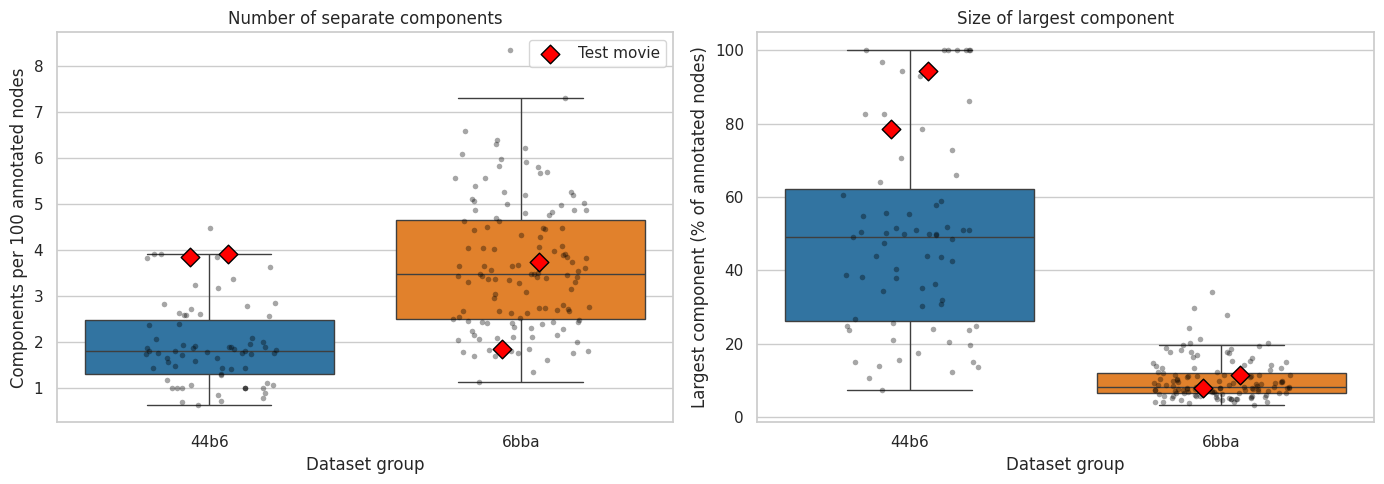

In [67]:
group_order = ["44b6", "6bba"]

fragmentation_metrics = [
    (
        "components_per_100_nodes",
        "Components per 100 annotated nodes",
        "Number of separate components"
    ),
    (
        "largest_component_percentage",
        "Largest component (% of annotated nodes)",
        "Size of largest component"
    )
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (column, ylabel, title) in zip(
    axes,
    fragmentation_metrics
):
    sns.boxplot(
        data=graph_summary,
        x="group",
        y=column,
        order=group_order,
        hue="group",
        palette=group_palette,
        legend=False,
        showfliers=False,
        ax=ax
    )

    sns.stripplot(
        data=graph_summary,
        x="group",
        y=column,
        order=group_order,
        color="black",
        alpha=0.35,
        size=4,
        jitter=0.22,
        ax=ax
    )

    for x_position, group in enumerate(group_order):
        test_values = (
            graph_summary.loc[
                (graph_summary["group"] == group)
                & graph_summary["is_test_movie"],
                column
            ]
            .sort_values()
            .to_numpy()
        )

        offsets = np.linspace(
            -0.06,
            0.06,
            len(test_values)
        )

        ax.scatter(
            x_position + offsets,
            test_values,
            marker="D",
            s=90,
            color="red",
            edgecolor="black",
            linewidth=1,
            zorder=5
        )

    ax.set_title(title)
    ax.set_xlabel("Dataset group")
    ax.set_ylabel(ylabel)

axes[0].scatter(
    [],
    [],
    marker="D",
    s=90,
    color="red",
    edgecolor="black",
    label="Test movie"
)
axes[0].legend()

plt.tight_layout()
plt.show()

### Group Differences in Annotation Fragmentation

The `6bba` distribution is shifted toward a larger number of weak components per 100 annotated nodes. Although individual observations overlap, the interquartile ranges have little or no overlap, suggesting that the difference is broadly distributed across movies rather than being produced by a small number of outliers.

The separation is stronger for the size of the largest component. The lower quartile of `44b6` lies above the upper whisker of `6bba`, although several `6bba` outliers overlap with the lower part of the `44b6` distribution. A typical `44b6` annotation graph is therefore much more concentrated in one dominant component.

Both `44b6` test graphs lie toward the upper end of their group for both displayed measures. This combination occurs because each graph contains one long dominant component and one much shorter component. Their relatively small total node counts make two components correspond to nearly four components per 100 nodes.

One `6bba` test graph lies below its group’s interquartile range for components per 100 nodes, while the other lies near the centre. Both are within the group’s interquartile range for largest-component percentage.

## Relate the Two Fragmentation Measures

A movie-level scatter plot is used to determine whether graphs with more weak components per 100 nodes also tend to have a smaller proportion of their annotations in the largest component.

Spearman correlations are calculated overall and separately within each dataset group. The within-group results are important because a pooled association could be driven mainly by the difference between `44b6` and `6bba`.

In [68]:
def spearman_rank_correlation(data, x, y):
    return (
        data[x]
        .rank()
        .corr(data[y].rank())
    )


fragmentation_correlations = pd.Series({
    "overall": spearman_rank_correlation(
        graph_summary,
        "components_per_100_nodes",
        "largest_component_percentage"
    ),
    "44b6": spearman_rank_correlation(
        graph_summary.loc[graph_summary["group"] == "44b6"],
        "components_per_100_nodes",
        "largest_component_percentage"
    ),
    "6bba": spearman_rank_correlation(
        graph_summary.loc[graph_summary["group"] == "6bba"],
        "components_per_100_nodes",
        "largest_component_percentage"
    )
}, name="spearman_correlation")

display(fragmentation_correlations.round(3).to_frame())

,spearman_correlation
overall,-0.646
44b6,-0.148
6bba,-0.462


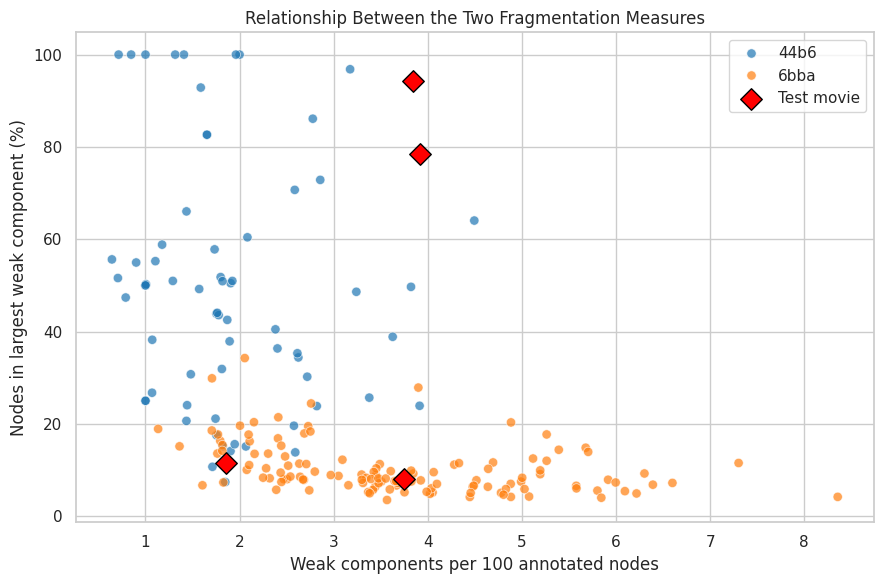

In [69]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=graph_summary.loc[~graph_summary["is_test_movie"]],
    x="components_per_100_nodes",
    y="largest_component_percentage",
    hue="group",
    hue_order=group_order,
    palette=group_palette,
    alpha=0.7,
    s=45
)

sns.scatterplot(
    data=graph_summary.loc[graph_summary["is_test_movie"]],
    x="components_per_100_nodes",
    y="largest_component_percentage",
    color="red",
    marker="D",
    edgecolor="black",
    linewidth=1,
    s=120,
    label="Test movie",
    zorder=5
)

plt.title("Relationship Between the Two Fragmentation Measures")
plt.xlabel("Weak components per 100 annotated nodes")
plt.ylabel("Nodes in largest weak component (%)")
plt.tight_layout()
plt.show()

### The Fragmentation Measures Are Not Interchangeable

Across all 199 movies, components per 100 nodes and largest-component percentage have a moderately strong negative Spearman correlation of −0.646. Movies with more separate components therefore tend to have a smaller proportion of their annotations concentrated in one component.

The pooled association is partly produced by the difference between dataset groups. Most `44b6` movies occupy the upper-left region of the plot, whereas most `6bba` movies occupy the lower-right.

Within `6bba`, the correlation remains moderately negative at −0.462. Within `44b6`, however, it is only −0.148, indicating a weak negative relationship. At similar values of components per 100 nodes, `44b6` movies can have either one dominant component or a much more even distribution of nodes across components.

This is not a sign reversal like the earlier Simpson’s-paradox example, because all three correlations are negative. However, pooling the groups substantially strengthens the apparent association.

The two measures are therefore related but not interchangeable. Components per 100 nodes measures the number of separate annotation fragments relative to graph size, while largest-component percentage measures how unevenly nodes are distributed across those fragments.

## Examine Annotated Divisions Across Movies

Division structure is examined separately because the competition metric explicitly evaluates division detection.

Two different questions must be distinguished:

- prevalence: what proportion of movies contain at least one annotated division?
- frequency: among movies containing divisions, how many division nodes are observed?

Raw division counts are affected by graph size and annotation coverage. Divisions per 100 annotated nodes are therefore also reported, although this normalisation cannot remove differences in annotation strategy.

In [70]:
division_summary_records = []

for group in group_order:
    group_data = graph_summary.loc[
        graph_summary["group"] == group
    ]

    positive_data = group_data.loc[
        group_data["n_division_nodes"] > 0
    ]

    division_summary_records.append({
        "group": group,
        "n_movies": len(group_data),
        "movies_with_divisions": len(positive_data),
        "movies_without_divisions": (
            len(group_data) - len(positive_data)
        ),
        "movies_with_divisions_percentage": (
            100 * len(positive_data) / len(group_data)
        ),
        "total_annotated_divisions": (
            group_data["n_division_nodes"].sum()
        ),
        "median_divisions_all_movies": (
            group_data["n_division_nodes"].median()
        ),
        "median_divisions_when_present": (
            positive_data["n_division_nodes"].median()
        ),
        "maximum_divisions_in_one_movie": (
            group_data["n_division_nodes"].max()
        ),
        "median_divisions_per_100_nodes_when_present": (
            positive_data["divisions_per_100_nodes"].median()
        )
    })

division_summary_by_group = (
    pd.DataFrame(division_summary_records)
    .set_index("group")
    .round(3)
)

display(division_summary_by_group)

,n_movies,movies_with_divisions,movies_without_divisions,movies_with_divisions_percentage,total_annotated_divisions,median_divisions_all_movies,median_divisions_when_present,maximum_divisions_in_one_movie,median_divisions_per_100_nodes_when_present
group,,,,,,,,,
44b6,71,21,50,29.577,26,0.0,1.0,2,0.467
6bba,128,66,62,51.562,125,1.0,2.0,5,0.179


### Division Prevalence and Frequency

Annotated divisions are more prevalent in `6bba`. Approximately 51.6% of `6bba` movies contain at least one division, compared with 29.6% of `44b6` movies.

Among movies containing divisions, the typical `6bba` graph has two division nodes, compared with one for `44b6`. The largest observed counts are five in a `6bba` graph and two in a `44b6` graph.

The conditional normalised result is different. Among division-containing movies, `44b6` has a median of approximately 0.47 divisions per 100 annotated nodes, compared with 0.18 for `6bba`.

This does not mean that divisions are generally more common in `44b6`. Divisions occur in fewer `44b6` movies, but the `44b6` annotation graphs are generally smaller. A single division in a small graph produces a relatively large divisions-per-100-nodes value.

The division distribution therefore has two distinct features:

- whether a graph contains any annotated division;
- how many divisions it contains, conditional on at least one being present.

This resembles a two-part or zero-inflated count structure. The occurrence and positive-count components should be examined separately.

Raw totals should not be compared directly because `6bba` contains more movies, more annotated nodes and substantially greater annotation coverage. Furthermore, these are supplied sparse annotations rather than complete biological division counts.

## Visualise Annotated Division Counts

The percentage of movies containing each possible number of annotated division nodes is compared between groups.

Percentages are calculated within each group because the dataset contains 71 `44b6` movies and 128 `6bba` movies. This prevents the larger `6bba` group from dominating the comparison.

n_division_nodes,0,1,2,3,4,5
group,,,,,,
44b6,70.4,22.5,7.0,0.0,0.0,0.0
6bba,48.4,23.4,15.6,7.8,3.9,0.8


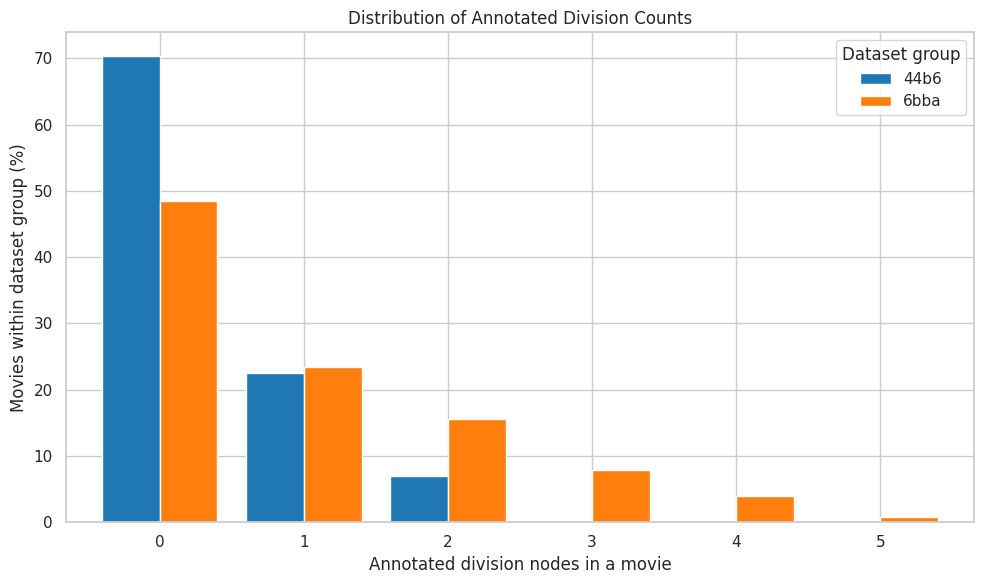

In [71]:
division_count_percentages = (
    pd.crosstab(
        graph_summary["group"],
        graph_summary["n_division_nodes"],
        normalize="index"
    )
    * 100
)

all_division_counts = range(
    graph_summary["n_division_nodes"].max() + 1
)

division_count_percentages = (
    division_count_percentages
    .reindex(
        index=group_order,
        columns=all_division_counts,
        fill_value=0
    )
)

display(division_count_percentages.round(1))

ax = (
    division_count_percentages
    .T
    .plot(
        kind="bar",
        figsize=(10, 6),
        color=[
            group_palette[group]
            for group in group_order
        ],
        width=0.8
    )
)

ax.set_title("Distribution of Annotated Division Counts")
ax.set_xlabel("Annotated division nodes in a movie")
ax.set_ylabel("Movies within dataset group (%)")
ax.legend(title="Dataset group")
ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=0
)

plt.tight_layout()
plt.show()

### Distribution of Annotated Division Counts

Zero annotated divisions is the most common outcome in both groups, but it is substantially more frequent in `44b6`: 70.4% of `44b6` movies contain no supplied division, compared with 48.4% of `6bba` movies.

The percentage containing exactly one division is almost identical, at 22.5% for `44b6` and 23.4% for `6bba`.

The main difference occurs at two or more divisions:

- 7.0% of `44b6` movies contain at least two divisions;
- 28.1% of `6bba` movies contain at least two divisions.

No `44b6` movie contains more than two annotated divisions. In contrast, the `6bba` distribution has a decreasing upper tail extending to five divisions.

Among movies with at least one division, most positive `44b6` movies contain exactly one. In `6bba`, slightly more than half of the positive movies contain multiple divisions.

The group difference is therefore primarily associated with repeated annotated division events rather than the occurrence of a single division. Larger graph sizes and greater annotation coverage in `6bba` may provide more opportunities to observe multiple events, so this should not yet be interpreted as a biological difference in division rate.

## Relate Division Counts to Annotation Graph Size

A larger annotation graph contains more nodes and therefore more opportunities to include a division event. The relationship between annotated node count and division count is examined overall and separately within each dataset group.

Spearman correlation is used because division count is discrete, contains many tied zero values and is not expected to increase linearly with graph size.

This analysis concerns the supplied annotations. It does not estimate the biological probability that an individual cell divides.

In [72]:
division_size_correlations = pd.Series({
    "overall": spearman_rank_correlation(
        graph_summary,
        "n_nodes",
        "n_division_nodes"
    ),
    "44b6": spearman_rank_correlation(
        graph_summary.loc[
            graph_summary["group"] == "44b6"
        ],
        "n_nodes",
        "n_division_nodes"
    ),
    "6bba": spearman_rank_correlation(
        graph_summary.loc[
            graph_summary["group"] == "6bba"
        ],
        "n_nodes",
        "n_division_nodes"
    )
}, name="spearman_correlation")

display(division_size_correlations.round(3).to_frame())

,spearman_correlation
overall,0.305
44b6,0.226
6bba,0.203


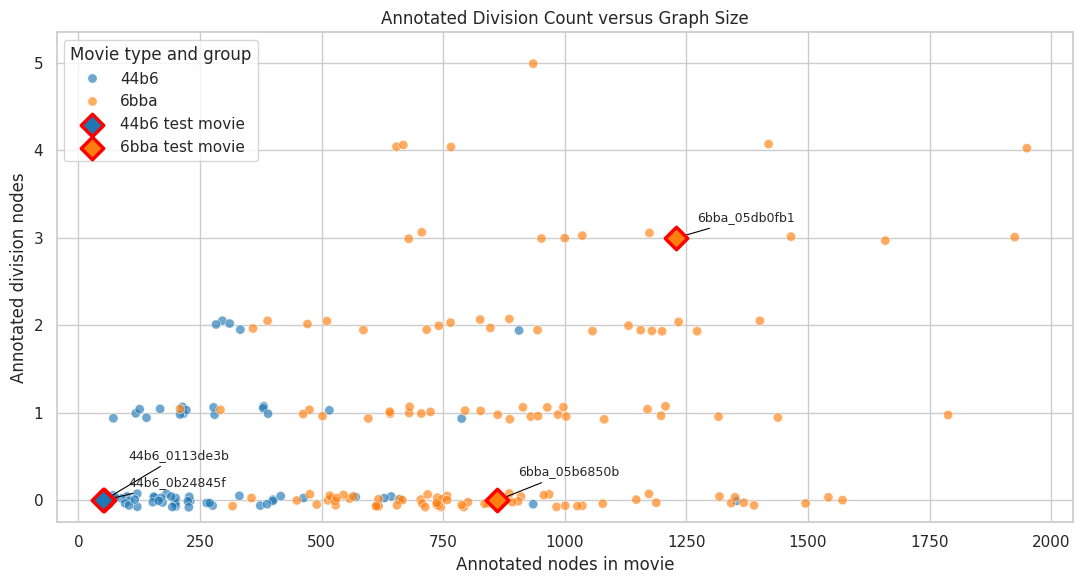

In [73]:
division_plot_data = graph_summary.copy()

random_generator = np.random.default_rng(42)

division_plot_data["division_count_jittered"] = (
    division_plot_data["n_division_nodes"]
    + random_generator.uniform(
        -0.08,
        0.08,
        size=len(division_plot_data)
    )
)

fig, ax = plt.subplots(figsize=(11, 6))

sns.scatterplot(
    data=division_plot_data.loc[
        ~division_plot_data["is_test_movie"]
    ],
    x="n_nodes",
    y="division_count_jittered",
    hue="group",
    hue_order=group_order,
    palette=group_palette,
    alpha=0.65,
    s=45,
    ax=ax
)

test_label_offsets = {
    "44b6_0113de3b": (18, 30),
    "44b6_0b24845f": (18, 10),
    "6bba_05b6850b": (15, 18),
    "6bba_05db0fb1": (15, 12)
}

for group in group_order:
    group_test_data = division_plot_data.loc[
        division_plot_data["is_test_movie"]
        & (division_plot_data["group"] == group)
    ]

    ax.scatter(
        group_test_data["n_nodes"],
        group_test_data["n_division_nodes"],
        marker="D",
        s=130,
        facecolor=group_palette[group],
        edgecolor="red",
        linewidth=2.5,
        label=f"{group} test movie",
        zorder=5
    )

    for row in group_test_data.itertuples():
        short_id = row.sample_id

        ax.annotate(
            short_id,
            xy=(row.n_nodes, row.n_division_nodes),
            xytext=test_label_offsets[row.sample_id],
            textcoords="offset points",
            fontsize=9,
            arrowprops={
                "arrowstyle": "-",
                "color": "black",
                "linewidth": 0.8
            }
        )

ax.set_title("Annotated Division Count versus Graph Size")
ax.set_xlabel("Annotated nodes in movie")
ax.set_ylabel("Annotated division nodes")
ax.set_yticks(
    range(
        graph_summary["n_division_nodes"].max() + 1
    )
)
ax.set_ylim(-0.25, 5.35)
ax.legend(title="Movie type and group")

plt.tight_layout()
plt.show()

### Graph Size Is Weakly Associated with Division Count

Annotated node count has a positive Spearman correlation with division count, but the association is weak. The correlation is 0.305 overall, 0.226 within `44b6` and 0.203 within `6bba`.

Larger annotation graphs therefore have a slight tendency to contain more division nodes, but graph size explains only a limited part of the variation. Movies with zero divisions occur across a wide range of graph sizes, including several large `6bba` graphs.

The similar positive correlations within both groups show that the pooled association is not solely produced by the difference between `44b6` and `6bba`. Nevertheless, the weak correlations do not explain the much higher prevalence of multiple divisions in `6bba`.

The two `44b6` test movies overlap visually because both have approximately 50 annotated nodes and zero divisions. The `6bba` test movies represent contrasting outcomes: one has 861 nodes and no divisions, while the other has 1,229 nodes and three divisions.

## Build a Component-Level Summary Table

Each weak component represents one separate supplied trajectory or lineage tree. A component-level table is created to examine how large and long these annotation fragments are.

For each component:

- component size is its number of annotated nodes;
- duration is the number of timepoints from its first to last annotation, including both endpoints;
- observed timepoints counts the distinct timepoints containing at least one component node;
- a simple path contains no division;
- a branched component contains at least one division.

For a branching component, node count is the total size of the lineage tree rather than the length of one trajectory.

In [74]:
component_records = []

for geff_path in train_geff:
    sample_id = geff_path.stem
    group = get_group(sample_id)

    store = zarr.open(str(geff_path), mode="r")

    node_ids = store["nodes/ids"][:]
    node_times_array = store["nodes/props/t/values"][:]
    edge_ids = store["edges/ids"][:]

    node_times = dict(
        zip(
            node_ids.tolist(),
            node_times_array.tolist()
        )
    )

    graph = nx.DiGraph()
    graph.add_nodes_from(node_ids.tolist())
    graph.add_edges_from(map(tuple, edge_ids.tolist()))

    components = list(
        nx.weakly_connected_components(graph)
    )

    # Give components a reproducible order.
    components = sorted(
        components,
        key=lambda nodes_in_component: (
            min(
                node_times[node_id]
                for node_id in nodes_in_component
            ),
            min(nodes_in_component)
        )
    )

    for component_number, component_nodes in enumerate(
        components,
        start=1
    ):
        component_graph = graph.subgraph(component_nodes)

        component_times = np.array([
            node_times[node_id]
            for node_id in component_nodes
        ])

        in_degrees = np.array([
            degree
            for _, degree in component_graph.in_degree()
        ])

        out_degrees = np.array([
            degree
            for _, degree in component_graph.out_degree()
        ])

        first_t = int(component_times.min())
        last_t = int(component_times.max())

        n_division_nodes = int(
            (out_degrees >= 2).sum()
        )

        component_records.append({
            "sample_id": sample_id,
            "group": group,
            "is_test_movie": sample_id in test_sample_ids,
            "component_id": component_number,
            "n_nodes": component_graph.number_of_nodes(),
            "n_edges": component_graph.number_of_edges(),
            "first_t": first_t,
            "last_t": last_t,
            "duration_timepoints": last_t - first_t + 1,
            "n_observed_timepoints": (
                np.unique(component_times).size
            ),
            "n_roots": int((in_degrees == 0).sum()),
            "n_leaves": int((out_degrees == 0).sum()),
            "n_division_nodes": n_division_nodes,
            "is_branched": n_division_nodes > 0,
            "is_simple_path": n_division_nodes == 0
        })

component_summary = pd.DataFrame(component_records)

### Preview of the Component-Level Table

Each row represents one weak component from one movie. A component may be either a simple directed path or a branching lineage tree.

The `component_id` was created during this analysis and is only unique within its corresponding movie. Components are ordered by their first annotated timepoint rather than by size.

In [75]:
print("Shape:", component_summary.shape)
display(component_summary.head())

print("\nMissing values:")
display(component_summary.isna().sum())

Shape: (4435, 15)


,sample_id,group,is_test_movie,component_id,n_nodes,n_edges,first_t,last_t,duration_timepoints,n_observed_timepoints,n_roots,n_leaves,n_division_nodes,is_branched,is_simple_path
0,44b6_0113de3b,44b6,True,1,3,2,0,2,3,3,1,1,0,False,True
1,44b6_0113de3b,44b6,True,2,49,48,27,75,49,49,1,1,0,False,True
2,44b6_0b24845f,44b6,True,1,40,39,11,50,40,40,1,1,0,False,True
3,44b6_0b24845f,44b6,True,2,11,10,39,49,11,11,1,1,0,False,True
4,44b6_0c582fdc,44b6,False,1,71,70,20,90,71,71,1,1,0,False,True



Missing values:


sample_id                0
group                    0
is_test_movie            0
component_id             0
n_nodes                  0
n_edges                  0
first_t                  0
last_t                   0
duration_timepoints      0
n_observed_timepoints    0
n_roots                  0
n_leaves                 0
n_division_nodes         0
is_branched              0
is_simple_path           0
dtype: int64

### Validate the Component-Level Table

Component counts, nodes and edges are summed back to the movie level to verify that the component table reconstructs every original annotation graph.

In [76]:
component_reconstruction = (
    component_summary
    .groupby("sample_id")
    .agg(
        calculated_components=("component_id", "size"),
        calculated_nodes=("n_nodes", "sum"),
        calculated_edges=("n_edges", "sum")
    )
    .reset_index()
    .merge(
        graph_summary[
            [
                "sample_id",
                "n_weak_components",
                "n_nodes",
                "n_edges"
            ]
        ],
        on="sample_id",
        how="left"
    )
)

print(
    "Correct component counts:",
    (
        component_reconstruction["calculated_components"]
        == component_reconstruction["n_weak_components"]
    ).sum(),
    "out of 199"
)

print(
    "Correct node totals:",
    (
        component_reconstruction["calculated_nodes"]
        == component_reconstruction["n_nodes"]
    ).sum(),
    "out of 199"
)

print(
    "Correct edge totals:",
    (
        component_reconstruction["calculated_edges"]
        == component_reconstruction["n_edges"]
    ).sum(),
    "out of 199"
)

print(
    "Components satisfying edges = nodes - 1:",
    (
        component_summary["n_edges"]
        == component_summary["n_nodes"] - 1
    ).sum(),
    "out of",
    len(component_summary)
)

print(
    "Components satisfying leaves = 1 + divisions:",
    (
        component_summary["n_leaves"]
        == 1 + component_summary["n_division_nodes"]
    ).sum(),
    "out of",
    len(component_summary)
)

Correct component counts: 199 out of 199
Correct node totals: 199 out of 199
Correct edge totals: 199 out of 199
Components satisfying edges = nodes - 1: 4435 out of 4435
Components satisfying leaves = 1 + divisions: 4435 out of 4435


### Component-Table Validation

The 199 annotation graphs contain 4,435 weak components. Each row of the component-level table represents one separate supplied trajectory or branching lineage tree.

The component totals exactly reconstruct all 199 movie graphs: component counts, node counts and edge counts agree with the graph-level table in every movie.

Every component contains one fewer edge than nodes, confirming that each component is a tree. Every component also satisfies:

`number of leaves = 1 + number of division nodes`

This follows from each component having exactly one root and only binary divisions.

The five displayed components are simple paths with one annotated node at every timepoint. However, branching components are known to exist because 87 movie graphs contain at least one division node.

Dataset-wide summaries are now required to determine how common branching components are, how their sizes and durations compare with simple paths, and whether temporal gaps occur within either type.

## Compare Simple Paths and Branching Components

Components are separated into:

- simple paths, which contain no annotated division;
- branching components, which contain at least one annotated division.

Branching prevalence is reported both at the component level and the movie level. These are different quantities because one movie may contain many separate components.

### Prevalence of Branching Components

This table measures how many individual components contain divisions. It complements the earlier movie-level result, which measured how many movies contain at least one division.

In [77]:
component_summary["component_type"] = np.where(
    component_summary["is_branched"],
    "Branching component",
    "Simple path"
)

branching_summary_records = []

for group in group_order:
    group_components = component_summary.loc[
        component_summary["group"] == group
    ]

    branched_components = group_components.loc[
        group_components["is_branched"]
    ]

    branching_summary_records.append({
        "group": group,
        "n_components": len(group_components),
        "simple_paths": (
            (~group_components["is_branched"]).sum()
        ),
        "branching_components": len(branched_components),
        "branching_components_percentage": (
            100
            * len(branched_components)
            / len(group_components)
        ),
        "movies_with_a_branching_component": (
            branched_components["sample_id"].nunique()
        )
    })

branching_summary_by_group = (
    pd.DataFrame(branching_summary_records)
    .set_index("group")
    .round(3)
)

display(branching_summary_by_group)

,n_components,simple_paths,branching_components,branching_components_percentage,movies_with_a_branching_component
group,,,,,
44b6,371,345,26,7.008,21
6bba,4064,3939,125,3.076,66


### Component Size and Duration by Type

Node counts and temporal durations are compared between simple paths and branching components.

Quartiles are reported because component sizes and durations may have long upper tails. A branching component can contain multiple nodes at the same timepoint, so its node count may exceed its duration.

In [78]:
def first_quartile(values):
    return values.quantile(0.25)


def third_quartile(values):
    return values.quantile(0.75)


component_size_duration_summary = (
    component_summary
    .groupby(
        ["group", "component_type"],
        observed=True
    )
    .agg(
        n_components=("component_id", "size"),
        n_movies=("sample_id", "nunique"),

        minimum_nodes=("n_nodes", "min"),
        first_quartile_nodes=(
            "n_nodes", first_quartile
        ),
        median_nodes=("n_nodes", "median"),
        third_quartile_nodes=(
            "n_nodes", third_quartile
        ),
        maximum_nodes=("n_nodes", "max"),

        minimum_duration=("duration_timepoints", "min"),
        first_quartile_duration=(
            "duration_timepoints", first_quartile
        ),
        median_duration=(
            "duration_timepoints", "median"
        ),
        third_quartile_duration=(
            "duration_timepoints", third_quartile
        ),
        maximum_duration=(
            "duration_timepoints", "max"
        )
    )
    .round(1)
)

display(component_size_duration_summary)

n_components  n_movies  minimum_nodes  \
group component_type                                               
44b6  Branching component            26        21             31   
      Simple path                   345        67              2   
6bba  Branching component           125        66              5   
      Simple path                  3939       128              2   

                           first_quartile_nodes  median_nodes  \
group component_type                                            
44b6  Branching component                  96.0         118.0   
      Simple path                          18.0          48.0   
6bba  Branching component                  18.0          44.0   
      Simple path                          12.0          20.0   

                           third_quartile_nodes  maximum_nodes  \
group component_type                                             
44b6  Branching component                 138.0            187   
      Simple path                          82.0            100   
6bba  Branching component                  75.0            175   
      Simple path                          35.0            100   

                           minimum_duration  first_quartile_duration  \
group component_type                                                   
44b6  Branching component                28                     72.5   
      Simple path                         2                     18.0   
6bba  Branching component                 3                     13.0   
      Simple path                         2                     12.0   

                           median_duration  third_quartile_duration  \
group component_type                                                  
44b6  Branching component             97.5                    100.0   
      Simple path                     48.0                     82.0   
6bba  Branching component             36.0                     60.0   
      Simple path                     20.0                     35.0   

                           maximum_duration  
group component_type                         
44b6  Branching component               100  
      Simple path                       100  
6bba  Branching component               100  
      Simple path                       100

### Branching Components Are Rare but Generally Long

Most supplied components are simple paths. Only 7.0% of `44b6` components and 3.1% of `6bba` components contain a division.

This does not contradict the earlier result that divisions occur in a larger percentage of `6bba` movies. The `6bba` graphs contain many more components overall, most of which are simple paths. Divisions occur across more `6bba` movies, but branching components form a smaller percentage of the much larger component total.

Branching components are generally larger and longer than simple paths. In `44b6`, branching components have a median of 118 nodes and span 97.5 timepoints, compared with 48 nodes and 48 timepoints for simple paths. In `6bba`, the corresponding medians are 44 nodes and 36 timepoints for branching components, compared with 20 nodes and 20 timepoints for simple paths.

Components are also typically longer in `44b6` than in `6bba`, for both component types. This is consistent with the earlier finding that `44b6` annotations are concentrated in fewer, larger components, while `6bba` annotations are divided across many shorter components.

The number of branching components exactly equals the number of division nodes in both groups: 26 in `44b6` and 125 in `6bba`. Therefore, every branching component contains exactly one annotated division. No supplied component contains a second division farther along either daughter lineage. Movies containing multiple divisions have those divisions in separate weak components rather than successive divisions within one supplied lineage tree.

Because the annotations are sparse, this does not imply that the complete biological lineages divide only once. Later divisions may simply be absent from the supplied annotation graph.

## Visualise Component Durations

Empirical cumulative distribution functions compare component durations without requiring equal group sizes or histogram bins.

At any duration on the horizontal axis, the vertical value gives the proportion of components with that duration or shorter. A curve that rises earlier represents a distribution containing more short components, while a curve shifted to the right represents generally longer components.

Simple paths and branching components are shown separately because their duration distributions and sample sizes differ substantially.

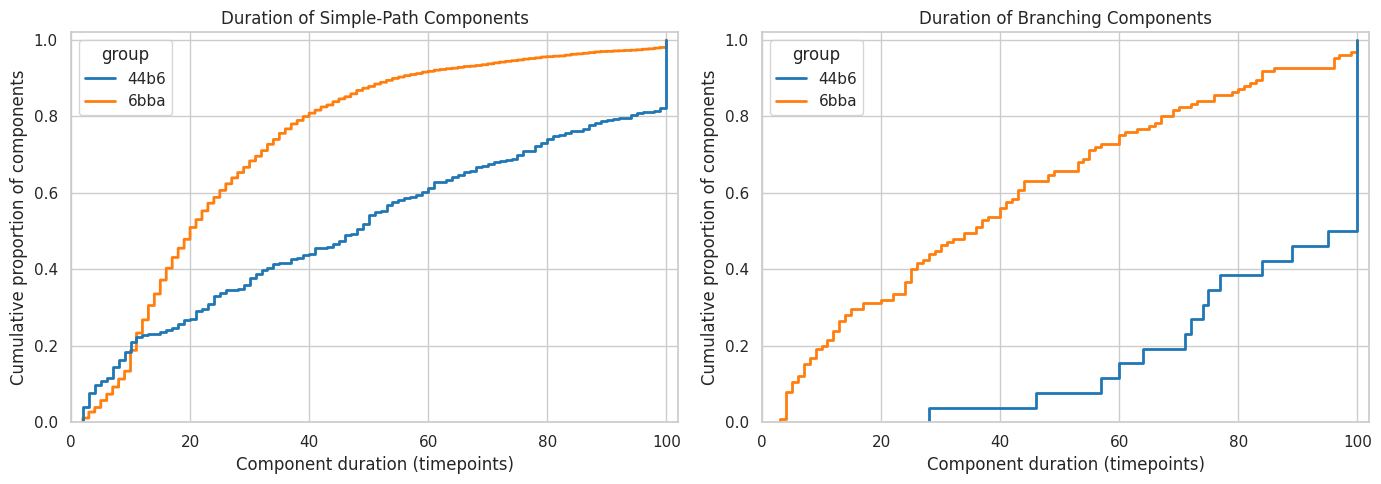

In [79]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

component_type_order = [
    "Simple path",
    "Branching component"
]

plot_titles = {
    "Simple path": "Duration of Simple-Path Components",
    "Branching component": "Duration of Branching Components"
}

for ax, component_type in zip(
    axes,
    component_type_order
):
    plot_data = component_summary.loc[
        component_summary["component_type"]
        == component_type
    ]

    sns.ecdfplot(
        data=plot_data,
        x="duration_timepoints",
        hue="group",
        hue_order=group_order,
        palette=group_palette,
        linewidth=2,
        ax=ax
    )

    ax.set_title(plot_titles[component_type])
    ax.set_xlabel("Component duration (timepoints)")
    ax.set_ylabel("Cumulative proportion of components")
    ax.set_xlim(0, 102)
    ax.set_ylim(0, 1.02)

plt.tight_layout()
plt.show()

### Component-Duration Distributions

For simple paths, the two group distributions cross at approximately 10–12 timepoints. `44b6` contains a somewhat larger proportion of extremely short paths, but beyond this point the `6bba` curve rises much faster. Most `6bba` paths are therefore relatively short, whereas `44b6` durations are spread much more widely.

The large rise in the `44b6` curve at 100 indicates that a substantial group of its simple paths spans the complete 100-timepoint movie. Only a small proportion of `6bba` paths reaches this duration.

The difference is even stronger for branching components. Most `6bba` branching components have durations below approximately 60 timepoints, while the `44b6` components are concentrated toward much longer durations.

Approximately half of the `44b6` branching components have a duration of exactly 100 timepoints, producing the large final step in the blue curve. The pronounced steps are also partly caused by the small sample of only 26 branching components.

A duration of 100 means that a component has annotations at both timepoints 0 and 99. It does not by itself prove that every intermediate timepoint is represented; temporal continuity will be checked separately.

## Build an Edge-Level Summary Table

Each row of the edge-level table represents one supplied directed connection between two annotated nodes.

Source and target node attributes are attached to each edge so that temporal gaps and physical movement can be calculated. This table does not create new connections; it describes the edges supplied in the GEFF files.

In [80]:
edge_frames = []

for geff_path in train_geff:
    sample_id = geff_path.stem
    group = get_group(sample_id)

    store = zarr.open(str(geff_path), mode="r")

    node_table = pd.DataFrame({
        "node_id": store["nodes/ids"][:],
        "t": store["nodes/props/t/values"][:],
        "z": store["nodes/props/z/values"][:],
        "y": store["nodes/props/y/values"][:],
        "x": store["nodes/props/x/values"][:]
    })

    edge_table = pd.DataFrame(
        store["edges/ids"][:],
        columns=["source_id", "target_id"]
    )

    source_table = node_table.rename(columns={
        "node_id": "source_id",
        "t": "source_t",
        "z": "source_z",
        "y": "source_y",
        "x": "source_x"
    })

    target_table = node_table.rename(columns={
        "node_id": "target_id",
        "t": "target_t",
        "z": "target_z",
        "y": "target_y",
        "x": "target_x"
    })

    edge_table = (
        edge_table
        .merge(
            source_table,
            on="source_id",
            how="left",
            validate="many_to_one"
        )
        .merge(
            target_table,
            on="target_id",
            how="left",
            validate="many_to_one"
        )
    )

    edge_table.insert(0, "sample_id", sample_id)
    edge_table.insert(1, "group", group)
    edge_table.insert(
        2,
        "is_test_movie",
        sample_id in test_sample_ids
    )

    edge_frames.append(edge_table)

edge_summary = pd.concat(
    edge_frames,
    ignore_index=True
)

edge_summary["delta_t"] = (
    edge_summary["target_t"]
    - edge_summary["source_t"]
)

### Preview of the Edge-Level Table

Each row contains one supplied edge, followed by the time and spatial coordinates of its source and target nodes. `delta_t` is the number of timepoints between the two connected annotations.

In [81]:
print("Shape:", edge_summary.shape)
display(edge_summary.head())

print("\nMissing values:")
display(edge_summary.isna().sum())

print(
    "\nEdge total agrees with graph table:",
    len(edge_summary)
    == graph_summary["n_edges"].sum()
)

Shape: (128883, 14)


,sample_id,group,is_test_movie,source_id,target_id,source_t,source_z,source_y,source_x,target_t,target_z,target_y,target_x,delta_t
0,44b6_0113de3b,44b6,True,11000000075,12000000075,0,63,222,249,1,63,227,251,1
1,44b6_0113de3b,44b6,True,12000000075,13000000075,1,63,227,251,2,63,230,253,1
2,44b6_0113de3b,44b6,True,38000000003,39000000003,27,1,74,73,28,3,78,75,1
3,44b6_0113de3b,44b6,True,39000000003,40000000003,28,3,78,75,29,5,80,77,1
4,44b6_0113de3b,44b6,True,40000000003,41000000003,29,5,80,77,30,7,86,78,1



Missing values:


sample_id        0
group            0
is_test_movie    0
source_id        0
target_id        0
source_t         0
source_z         0
source_y         0
source_x         0
target_t         0
target_z         0
target_y         0
target_x         0
delta_t          0
dtype: int64


Edge total agrees with graph table: True


## Examine Temporal Gaps Across All Edges

For each directed edge:

`delta_t = target timepoint − source timepoint`

A value of 1 connects consecutive timepoints. A value greater than 1 skips one or more intermediate timepoints. Zero would connect nodes in the same frame, while a negative value would point backward through time.

Edge-level gaps provide a more reliable measure of temporal continuity than component duration because a long component may still contain skipped frames.

In [82]:
temporal_edge_summary = (
    edge_summary
    .groupby("group")
    .agg(
        n_edges=("delta_t", "size"),
        forward_edges=(
            "delta_t",
            lambda values: (values > 0).sum()
        ),
        consecutive_edges=(
            "delta_t",
            lambda values: (values == 1).sum()
        ),
        temporal_gap_edges=(
            "delta_t",
            lambda values: (values > 1).sum()
        ),
        same_time_edges=(
            "delta_t",
            lambda values: (values == 0).sum()
        ),
        backward_edges=(
            "delta_t",
            lambda values: (values < 0).sum()
        ),
        median_delta_t=("delta_t", "median"),
        maximum_delta_t=("delta_t", "max")
    )
)

temporal_edge_summary["temporal_gap_percentage"] = (
    100
    * temporal_edge_summary["temporal_gap_edges"]
    / temporal_edge_summary["n_edges"]
)

display(temporal_edge_summary.round(3))

print("\nOverall delta_t distribution:")
display(
    edge_summary["delta_t"]
    .value_counts()
    .sort_index()
    .rename_axis("delta_t")
    .to_frame("n_edges")
)

,n_edges,forward_edges,consecutive_edges,temporal_gap_edges,same_time_edges,backward_edges,median_delta_t,maximum_delta_t,temporal_gap_percentage
group,,,,,,,,,
44b6,19826,19826,19826,0,0,0,1.0,1,0.0
6bba,109057,109057,109057,0,0,0,1.0,1,0.0



Overall delta_t distribution:


,n_edges
delta_t,
1,128883


### All Supplied Edges Connect Consecutive Timepoints

The edge-level table contains all 128,883 supplied graph edges, with no missing source or target attributes. Its edge total exactly agrees with the graph-level table.

Every supplied edge moves forward by exactly one timepoint. There are no same-frame edges, backward edges or edges that skip intermediate frames in either dataset group.

Therefore, temporal gaps do not occur within the supplied annotation components. Components may begin or end partway through a movie, but once a component is observed, each supplied connection links one frame to the next.

This also means that every component contains at least one node at every timepoint between its first and last annotation. For a simple path, node count therefore equals duration. A branching component may contain more nodes than its duration because both daughter branches can be present at the same time.

The ground-truth graph structure supports prioritising links between adjacent frames in an initial tracking baseline. Longer predicted links should not be introduced without validation because they do not correspond directly to the supplied edge structure.

## Measure Physical Movement Across All Edges

Physical movement is calculated from the difference between source and target coordinates.

Voxel differences are converted to micrometres before calculating Euclidean distance because Z voxels are four times larger than X and Y voxels in physical space.

Edges are separated into:

- continuation edges: the source has one outgoing edge, connecting two consecutive observations of the same biological cell
- division edges: the source has two outgoing edges, each connecting the dividing cell to one of its two daughter cells

Each division node contributes two division edges, one to each annotated daughter.

In [83]:
edge_summary["source_out_degree"] = (
    edge_summary
    .groupby(["sample_id", "source_id"])["target_id"]
    .transform("size")
)

edge_summary["edge_type"] = np.where(
    edge_summary["source_out_degree"] == 2,
    "Division edge",
    "Continuation edge"
)

edge_summary["delta_z_voxels"] = (
    edge_summary["target_z"]
    - edge_summary["source_z"]
)

edge_summary["delta_y_voxels"] = (
    edge_summary["target_y"]
    - edge_summary["source_y"]
)

edge_summary["delta_x_voxels"] = (
    edge_summary["target_x"]
    - edge_summary["source_x"]
)

edge_summary["delta_z_um"] = (
    edge_summary["delta_z_voxels"] * 1.625
)

edge_summary["delta_y_um"] = (
    edge_summary["delta_y_voxels"] * 0.40625
)

edge_summary["delta_x_um"] = (
    edge_summary["delta_x_voxels"] * 0.40625
)

edge_summary["distance_um"] = np.sqrt(
    edge_summary["delta_z_um"] ** 2
    + edge_summary["delta_y_um"] ** 2
    + edge_summary["delta_x_um"] ** 2
)

edge_summary["speed_um_per_second"] = (
    edge_summary["distance_um"]
    / edge_summary["delta_t"]
)

### Physical-Displacement Summary

Displacement distributions are summarised separately by dataset group and edge type. Quantiles are more informative than the maximum alone because a small number of unusual edges may form a long upper tail.

In [84]:
def ninety_fifth_percentile(values):
    return values.quantile(0.95)


def ninety_ninth_percentile(values):
    return values.quantile(0.99)


movement_summary = (
    edge_summary
    .groupby(
        ["group", "edge_type"],
        observed=True
    )
    .agg(
        n_edges=("distance_um", "size"),
        minimum_distance=("distance_um", "min"),
        first_quartile_distance=(
            "distance_um", first_quartile
        ),
        median_distance=("distance_um", "median"),
        mean_distance=("distance_um", "mean"),
        third_quartile_distance=(
            "distance_um", third_quartile
        ),
        percentile_95_distance=(
            "distance_um", ninety_fifth_percentile
        ),
        percentile_99_distance=(
            "distance_um", ninety_ninth_percentile
        ),
        maximum_distance=("distance_um", "max")
    )
    .round(3)
)

display(movement_summary)

n_edges  minimum_distance  first_quartile_distance  \
group edge_type                                                               
44b6  Continuation edge    19774             0.000                    0.908   
      Division edge           52             0.406                    2.936   
6bba  Continuation edge   108807             0.000                    0.908   
      Division edge          250             1.219                    4.068   

                         median_distance  mean_distance  \
group edge_type                                           
44b6  Continuation edge            1.724          1.851   
      Division edge                4.614          4.798   
6bba  Continuation edge            1.817          2.170   
      Division edge                5.929          6.018   

                         third_quartile_distance  percentile_95_distance  \
group edge_type                                                            
44b6  Continuation edge                    2.298                   3.918   
      Division edge                        6.214                   9.035   
6bba  Continuation edge                    2.873                   5.466   
      Division edge                        7.644                  10.551   

                         percentile_99_distance  maximum_distance  
group edge_type                                                    
44b6  Continuation edge                   7.176            18.692  
      Division edge                      11.103            12.336  
6bba  Continuation edge                   8.463            60.758  
      Division edge                      12.889            13.529

### Movement Differs Between Continuations and Divisions

Ordinary continuation movement is relatively small. Median displacement is approximately 1.72 µm in `44b6` and 1.82 µm in `6bba`.

Division edges are considerably longer. Their median displacement is approximately 4.61 µm in `44b6` and 5.93 µm in `6bba`. The interquartile ranges of continuation and division edges do not overlap within either group.

This suggests that the change from one parent centroid to two daughter centroids produces larger apparent movement than an ordinary frame-to-frame continuation. A tracking method may therefore require different spatial expectations for continuation and division candidates.

Movement is generally somewhat larger in `6bba`, particularly in the upper part of the distributions. For continuation edges, the 95th percentile is approximately 5.47 µm in `6bba`, compared with 3.92 µm in `44b6`.

Some continuation edges have zero displacement. This means that their integer centroid coordinates are unchanged between consecutive frames. The cells may be nearly stationary, or movement may be smaller than the coordinate resolution.

Each division node contributes two daughter edges. The 52 `44b6` division edges correspond to 26 division nodes, while the 250 `6bba` division edges correspond to 125 division nodes.

The maximum `6bba` continuation displacement of 60.76 µm is far above its 99th percentile of 8.46 µm. It should be investigated individually before deciding whether it represents genuine movement, an unusual annotation or another edge case.

The 7 µm evaluation tolerance concerns matching predicted and ground-truth node positions. It is not a maximum permitted movement distance and should not be used directly as a linking threshold.

## Inspect the Longest Supplied Edges

The longest edges are examined individually because maximum displacement is highly sensitive to a small number of unusual observations.

The source and target coordinates are retained so that extreme movement can later be checked against the corresponding microscopy images.

In [85]:
longest_edge_columns = [
    "sample_id",
    "group",
    "edge_type",
    "source_id",
    "target_id",
    "source_t",
    "target_t",
    "source_z",
    "source_y",
    "source_x",
    "target_z",
    "target_y",
    "target_x",
    "delta_z_um",
    "delta_y_um",
    "delta_x_um",
    "distance_um"
]

longest_edges = (
    edge_summary
    .nlargest(15, "distance_um")
    [longest_edge_columns]
    .reset_index(drop=True)
)

display(longest_edges.round(3))

,sample_id,group,edge_type,source_id,target_id,source_t,target_t,source_z,source_y,source_x,target_z,target_y,target_x,delta_z_um,delta_y_um,delta_x_um,distance_um
0,6bba_f20478e9,6bba,Continuation edge,65000869,66000881,64,65,11,152,27,46,100,35,56.875,-21.125,3.250,60.758
1,6bba_f20478e9,6bba,Continuation edge,66000880,67000885,65,66,44,155,101,7,150,98,-60.125,-2.031,-1.219,60.172
2,6bba_f20478e9,6bba,Continuation edge,66000882,67000887,65,66,60,171,199,24,166,200,-58.500,-2.031,0.406,58.537
3,6bba_f20478e9,6bba,Continuation edge,66000881,67000894,65,66,46,100,35,11,94,37,-56.875,-2.438,0.812,56.933
4,6bba_f20478e9,6bba,Continuation edge,65000870,66000880,64,65,13,195,107,44,155,101,50.375,-16.250,-2.438,52.987
5,6bba_f20478e9,6bba,Continuation edge,65000879,66000882,64,65,31,214,202,60,171,199,47.125,-17.469,-1.219,50.273
6,6bba_f20478e9,6bba,Continuation edge,65000881,66000885,64,65,33,213,140,62,175,146,47.125,-15.438,2.438,49.649
7,6bba_f20478e9,6bba,Continuation edge,66000885,67000895,65,66,62,175,146,32,159,153,-48.750,-6.500,2.844,49.264
8,6bba_e5e44988,6bba,Continuation edge,15000215,16000223,14,15,47,116,111,43,179,104,-6.500,25.594,-2.844,26.559
9,6bba_e5e44988,6bba,Continuation edge,15000210,16000219,14,15,26,126,211,20,184,212,-9.750,23.562,0.406,25.503


In [86]:
def percentage_above(values, threshold):
    return 100 * (values > threshold).mean()


long_edge_summary = (
    edge_summary
    .groupby(
        ["group", "edge_type"],
        observed=True
    )
    .agg(
        n_edges=("distance_um", "size"),
        percentage_above_10_um=(
            "distance_um",
            lambda values: percentage_above(values, 10)
        ),
        percentage_above_15_um=(
            "distance_um",
            lambda values: percentage_above(values, 15)
        ),
        percentage_above_20_um=(
            "distance_um",
            lambda values: percentage_above(values, 20)
        )
    )
    .round(3)
)

display(long_edge_summary)

n_edges  percentage_above_10_um  \
group edge_type                                            
44b6  Continuation edge    19774                   0.223   
      Division edge           52                   1.923   
6bba  Continuation edge   108807                   0.297   
      Division edge          250                   6.400   

                         percentage_above_15_um  percentage_above_20_um  
group edge_type                                                          
44b6  Continuation edge                   0.010                   0.000  
      Division edge                       0.000                   0.000  
6bba  Continuation edge                   0.078                   0.016  
      Division edge                       0.000                   0.000

### Longest Edges Cluster by Movie and Time

The eight longest supplied edges all come from `6bba_f20478e9` and occur during the transitions from timepoint 64 to 65 or from 65 to 66.

Most of these movements are dominated by the Z-axis. Several nodes move by approximately 50–60 µm in one direction and then other edges move similarly large distances in the opposite direction during the following transition.

This concentration within one movie and two adjacent transitions suggests a frame-level or annotation-level event rather than ordinary cell motion. Possible explanations include an abrupt shift or misalignment between consecutive image volumes, unusual tracking associations, or genuine rapid spatial movement. The table alone cannot distinguish between these possibilities, so the relevant timepoints should be examined separately.

The next three longest edges also cluster within one movie, `6bba_e5e44988`, during the transition from timepoint 14 to 15. These are driven mainly by large Y-axis changes.

Very long edges are rare. Only approximately 0.016% of `6bba` continuation edges exceed 20 µm, and none do so in `44b6`. No division edge exceeds 15 µm in either group.

Division edges are more likely than continuation edges to exceed 10 µm, but the most extreme observations are all continuation edges. A tracking search radius should therefore not be chosen from the overall maximum alone. Using the 60.76 µm maximum as a search radius would admit many unrelated candidate cells in ordinary frames. A candidate radius should instead be selected from the typical displacement distribution and tuned through validation, with unusual transitions considered separately.

## Investigate the Extreme Movement Cluster

Movement in `6bba_f20478e9` is summarised for each consecutive-frame transition. This determines whether the extreme distances are confined to timepoints 64–66 or form part of a longer period of unusual movement.

For source timepoint 64, the plotted distances describe edges from timepoint 64 to 65.

In [87]:
movement_focus_id = "6bba_f20478e9"

focus_movement_edges = edge_summary.loc[
    edge_summary["sample_id"] == movement_focus_id
].copy()

focus_transition_summary = (
    focus_movement_edges
    .groupby("source_t")
    .agg(
        n_edges=("distance_um", "size"),
        median_distance=("distance_um", "median"),
        percentile_95_distance=(
            "distance_um",
            ninety_fifth_percentile
        ),
        maximum_distance=("distance_um", "max")
    )
    .reset_index()
)

print("Transitions with a maximum distance above 15 µm:")

display(
    focus_transition_summary.loc[
        focus_transition_summary["maximum_distance"] > 15
    ].round(3)
)

Transitions with a maximum distance above 15 µm:


,source_t,n_edges,median_distance,percentile_95_distance,maximum_distance
64,64,4,51.630,59.593,60.758
65,65,4,57.735,59.926,60.172


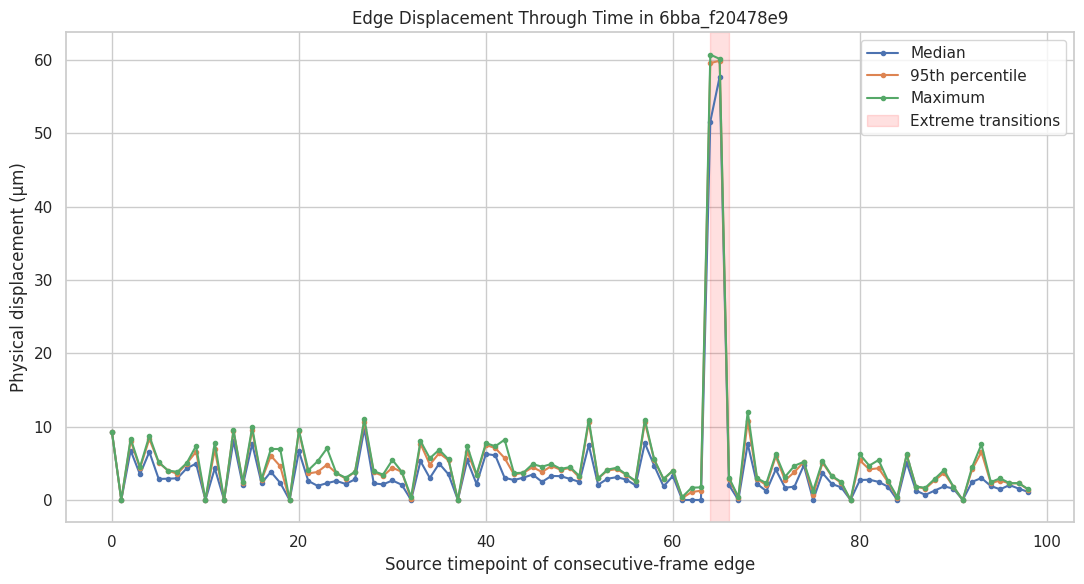

In [88]:
fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(
    focus_transition_summary["source_t"],
    focus_transition_summary["median_distance"],
    marker="o",
    markersize=3,
    linewidth=1.5,
    label="Median"
)

ax.plot(
    focus_transition_summary["source_t"],
    focus_transition_summary["percentile_95_distance"],
    marker="o",
    markersize=3,
    linewidth=1.5,
    label="95th percentile"
)

ax.plot(
    focus_transition_summary["source_t"],
    focus_transition_summary["maximum_distance"],
    marker="o",
    markersize=3,
    linewidth=1.5,
    label="Maximum"
)

ax.axvspan(
    64,
    66,
    color="red",
    alpha=0.12,
    label="Extreme transitions"
)

ax.set_title(
    "Edge Displacement Through Time in "
    "6bba_f20478e9"
)
ax.set_xlabel(
    "Source timepoint of consecutive-frame edge"
)
ax.set_ylabel("Physical displacement (µm)")
ax.legend()

plt.tight_layout()
plt.show()

### Extreme Movement Is Localised Around Timepoint 65

The extreme displacement is confined to the transitions entering and leaving timepoint 65.

For the transition from timepoint 64 to 65, all four supplied edges are unusually long. The median displacement is 51.63 µm and the maximum is 60.76 µm.

The same pattern occurs from timepoint 65 to 66, where the median is 57.74 µm and the maximum is 60.17 µm. Outside these two transitions, the maximum displacement generally remains below approximately 12 µm.

Because the median, 95th percentile and maximum all rise together, this is not an isolated incorrectly linked edge. Every supplied trajectory crossing timepoint 65 undergoes a large displacement.

The movements into timepoint 65 are largely reversed immediately afterward. This suggests that timepoint 65 itself is spatially inconsistent with its neighbours. The edge data alone cannot determine whether the microscopy volume moved, the coordinate system changed or the supplied associations are unusual.

## Inspect the Microscopy Around Timepoint 65

Maximum-intensity XZ and YZ projections are compared at timepoints 64, 65 and 66 using one shared intensity scale.

Annotated nodes are overlaid in red. The comparison asks:

- Does the fluorescent image content shift along Z at timepoint 65?
- Do the annotations remain aligned with bright structures?
- Does the image return toward its previous position at timepoint 66?
- Does timepoint 65 appear visually different or corrupted?

If both the image and annotations shift together, the long edges may reflect movement of the specimen or imaging volume. If only the annotations shift, an annotation or tracking inconsistency would be more plausible.

In [89]:
movement_focus_times = [64, 65, 66]

focus_image_array = zarr.open(
    str(train_root / f"{movement_focus_id}.zarr"),
    mode="r"
)["0"]

focus_geff_store = zarr.open(
    str(train_root / f"{movement_focus_id}.geff"),
    mode="r"
)

focus_nodes = pd.DataFrame({
    "node_id": focus_geff_store["nodes/ids"][:],
    "t": focus_geff_store["nodes/props/t/values"][:],
    "z": focus_geff_store["nodes/props/z/values"][:],
    "y": focus_geff_store["nodes/props/y/values"][:],
    "x": focus_geff_store["nodes/props/x/values"][:]
})

focus_projections = {}

for timepoint in movement_focus_times:
    frame = focus_image_array[timepoint]

    focus_projections[timepoint] = {
        "xz": frame.max(axis=1),
        "yz": frame.max(axis=2)
    }

all_projection_values = np.concatenate([
    projection.ravel()
    for timepoint_data in focus_projections.values()
    for projection in timepoint_data.values()
])

projection_vmin = np.percentile(
    all_projection_values,
    1
)

projection_vmax = np.percentile(
    all_projection_values,
    99.5
)

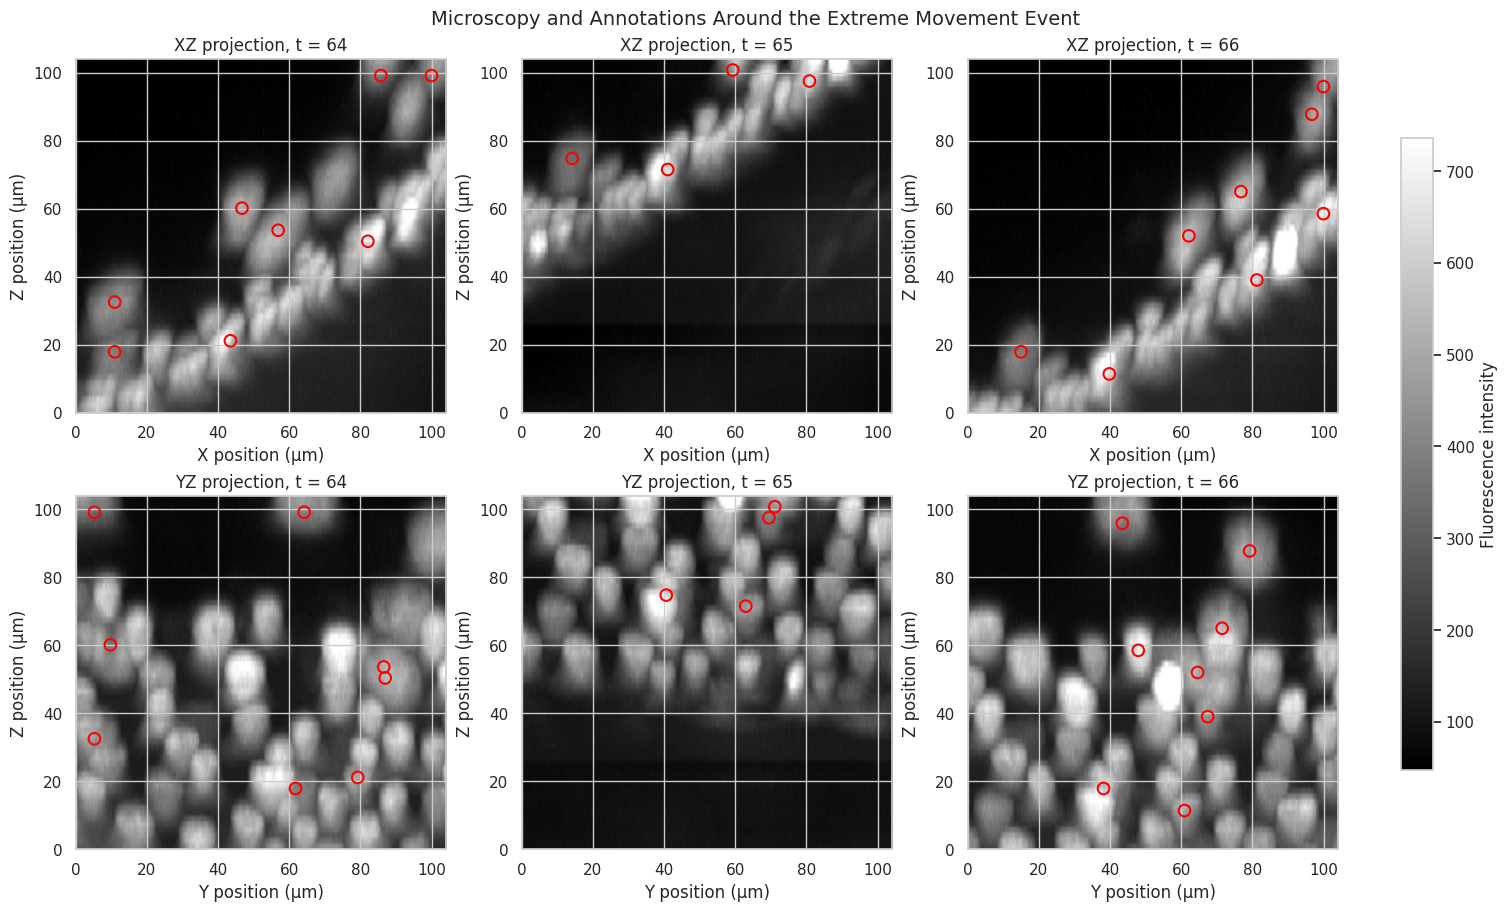

In [90]:
fig, axes = plt.subplots(
    2,
    3,
    figsize=(15, 9),
    constrained_layout=True
)

x_extent = [0, 256 * 0.40625]
y_extent = [0, 256 * 0.40625]
z_extent = [0, 64 * 1.625]

for column, timepoint in enumerate(
    movement_focus_times
):
    nodes_at_timepoint = focus_nodes.loc[
        focus_nodes["t"] == timepoint
    ]

    xz_image = axes[0, column].imshow(
        focus_projections[timepoint]["xz"],
        cmap="gray",
        origin="lower",
        extent=x_extent + z_extent,
        aspect="auto",
        vmin=projection_vmin,
        vmax=projection_vmax
    )

    axes[0, column].scatter(
        nodes_at_timepoint["x"] * 0.40625,
        nodes_at_timepoint["z"] * 1.625,
        facecolors="none",
        edgecolors="red",
        linewidths=1.5,
        s=70
    )

    axes[0, column].set_title(
        f"XZ projection, t = {timepoint}"
    )
    axes[0, column].set_xlabel("X position (µm)")
    axes[0, column].set_ylabel("Z position (µm)")

    axes[1, column].imshow(
        focus_projections[timepoint]["yz"],
        cmap="gray",
        origin="lower",
        extent=y_extent + z_extent,
        aspect="auto",
        vmin=projection_vmin,
        vmax=projection_vmax
    )

    axes[1, column].scatter(
        nodes_at_timepoint["y"] * 0.40625,
        nodes_at_timepoint["z"] * 1.625,
        facecolors="none",
        edgecolors="red",
        linewidths=1.5,
        s=70
    )

    axes[1, column].set_title(
        f"YZ projection, t = {timepoint}"
    )
    axes[1, column].set_xlabel("Y position (µm)")
    axes[1, column].set_ylabel("Z position (µm)")

fig.colorbar(
    xz_image,
    ax=axes,
    shrink=0.8,
    label="Fluorescence intensity"
)

fig.suptitle(
    "Microscopy and Annotations Around the Extreme Movement Event",
    fontsize=14
)

plt.show()

### Image Evidence for a Global Spatial Shift

The microscopy images show that the extreme edge displacements are associated with a global change in image position at timepoint 65.

At timepoints 64 and 66, fluorescent structures occupy most of the Z-range. At timepoint 65, the lower portion of the volume is largely empty, while the fluorescent region is shifted toward higher Z and clipped by the upper boundary.

The annotated nodes move with the visible fluorescent structures and remain broadly aligned with them. The long edges therefore do not appear to result from four independent cells undergoing unusually large biological movements.

Instead, the image content itself appears spatially displaced at timepoint 65 before returning at timepoint 66. The visual evidence cannot determine whether this was caused by movement of the specimen, movement of the microscope stage or a change in the coordinate origin of the acquired volume.

Maximum-intensity projections collapse one spatial axis, so they do not prove that the change is a perfectly rigid three-dimensional translation. Nevertheless, the common Z-shift is visible in both the XZ and YZ views.

### Modelling Implication: Global Motion Compensation

The apparent shift at timepoint 65 suggests that some observed cell movement may be shared across the complete image volume rather than representing independent biological motion.

A future tracking pipeline could estimate the global three-dimensional translation between consecutive frames using image registration. Candidate links could then be evaluated using both:

- raw displacement between detected centroids;
- residual displacement after subtracting the estimated global frame movement.

This could allow the tracker to handle sudden image shifts without using an excessively large search radius during ordinary frames.

Global registration must be validated rather than applied automatically. Tissue can deform non-rigidly, structures can enter or leave the field of view, and a global correction could remove meaningful biological movement. The estimated frame-shift vector may therefore be more useful as an additional linking feature than as a mandatory coordinate transformation.

## Visualise Typical Edge Displacements

Empirical cumulative distribution functions compare physical displacement between dataset groups.

Continuation and division edges are shown separately because division edges have substantially larger typical displacements.

The horizontal axis is restricted to 0–15 µm. This contains every supplied division edge and more than 99.9% of continuation edges, while preventing the rare global-shift events from compressing the ordinary movement distributions.

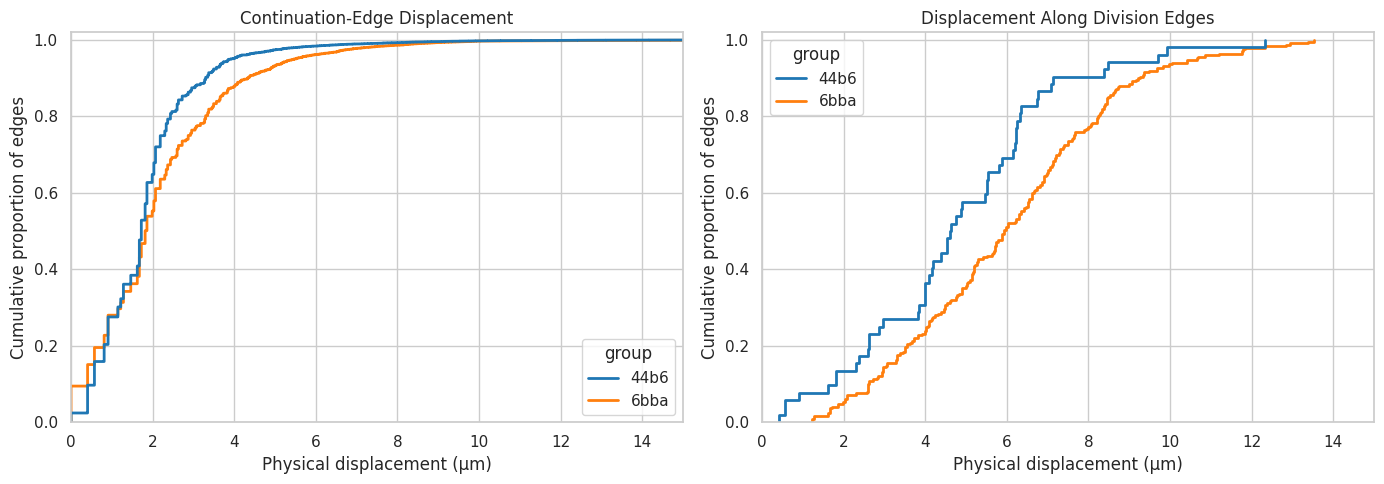

In [91]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

edge_type_order = [
    "Continuation edge",
    "Division edge"
]

edge_type_titles = {
    "Continuation edge":
        "Continuation-Edge Displacement",

    "Division edge":
        "Displacement Along Division Edges"
}

for ax, edge_type in zip(
    axes,
    edge_type_order
):
    plot_data = edge_summary.loc[
        edge_summary["edge_type"] == edge_type
    ]

    sns.ecdfplot(
        data=plot_data,
        x="distance_um",
        hue="group",
        hue_order=group_order,
        palette=group_palette,
        linewidth=2,
        ax=ax
    )

    ax.set_title(edge_type_titles[edge_type])
    ax.set_xlabel("Physical displacement (µm)")
    ax.set_ylabel("Cumulative proportion of edges")
    ax.set_xlim(0, 15)
    ax.set_ylim(0, 1.02)

plt.tight_layout()
plt.show()

### Edge-Displacement Distributions

The `6bba` displacement distribution is shifted toward larger values for both edge types.

For continuation edges, the difference is modest around the centre of the distribution. Median displacement is 1.82 µm for `6bba` and 1.72 µm for `44b6`. The separation becomes larger toward the upper tail, consistent with the earlier 95th-percentile results.

The group difference is clearer for division edges. The `6bba` curve lies to the right across most of the distribution, with a median displacement of 5.93 µm compared with 4.61 µm for `44b6`.

The pronounced steps in the `44b6` division curve reflect its small sample of only 52 division edges and the discrete voxel coordinates.

The distributions still overlap substantially, so group membership or edge type cannot determine a correct link by itself. However, they may be useful as inputs to a probabilistic linking model or for setting group- and edge-specific candidate distances.

## Compare Test-Movie Movement with Group Distributions

Movement is first summarised within each movie so that every movie contributes one value, regardless of its number of supplied edges.

The median and 95th-percentile movement of each test movie are ranked relative to movies from the same group and with the same edge type.

In [92]:
movie_movement_summary = (
    edge_summary
    .groupby(
        [
            "sample_id",
            "group",
            "is_test_movie",
            "edge_type"
        ],
        observed=True
    )
    .agg(
        n_edges=("distance_um", "size"),
        median_distance=("distance_um", "median"),
        percentile_95_distance=(
            "distance_um",
            ninety_fifth_percentile
        ),
        maximum_distance=("distance_um", "max")
    )
    .reset_index()
)

movie_movement_summary[
    "median_distance_group_percentile"
] = (
    movie_movement_summary
    .groupby(["group", "edge_type"])[
        "median_distance"
    ]
    .rank(pct=True)
    * 100
)

movie_movement_summary[
    "percentile_95_group_percentile"
] = (
    movie_movement_summary
    .groupby(["group", "edge_type"])[
        "percentile_95_distance"
    ]
    .rank(pct=True)
    * 100
)

test_movement_summary = (
    movie_movement_summary.loc[
        movie_movement_summary["is_test_movie"]
    ]
    .sort_values(["group", "sample_id", "edge_type"])
)

display(
    test_movement_summary[
        [
            "sample_id",
            "group",
            "edge_type",
            "n_edges",
            "median_distance",
            "median_distance_group_percentile",
            "percentile_95_distance",
            "percentile_95_group_percentile",
            "maximum_distance"
        ]
    ].round(3)
)

,sample_id,group,edge_type,n_edges,median_distance,median_distance_group_percentile,percentile_95_distance,percentile_95_group_percentile,maximum_distance
0,44b6_0113de3b,44b6,Continuation edge,50,2.883,90.141,6.292,87.324,7.814
1,44b6_0b24845f,44b6,Continuation edge,49,2.071,69.014,4.236,71.831,5.155
92,6bba_05b6850b,6bba,Continuation edge,845,0.908,1.562,3.495,9.766,9.959
93,6bba_05db0fb1,6bba,Continuation edge,1177,1.675,37.891,5.155,53.906,9.834
94,6bba_05db0fb1,6bba,Division edge,6,6.052,48.485,7.265,25.758,7.369


### Movement Characteristics of the Test Movies

The two `44b6` test movies have relatively large continuation-edge movements within their group.

`44b6_0113de3b` is particularly movement-heavy. Its median displacement is at approximately the 90th percentile of `44b6` movies, while its 95th percentile is at approximately the 87th percentile. The movie selected for the initial detailed investigation is therefore not typical of `44b6` movement.

`44b6_0b24845f` is also above average, with its median and 95th-percentile displacements both around the 70th percentile of the group.

The `6bba` test movies differ substantially. `6bba_05b6850b` has one of the smallest continuation-movement distributions in its group: its median is at approximately the 2nd percentile and its 95th percentile is near the 10th percentile.

`6bba_05db0fb1` is closer to typical `6bba` movement. Its median is at approximately the 38th percentile and its 95th percentile is near the 54th percentile.

Only `6bba_05db0fb1` has supplied division edges. Its six division edges arise from three annotated divisions. Their median displacement is near the centre of the corresponding `6bba` distribution.

The division-edge summaries for this movie are based on only six observations, so its 95th percentile and maximum are much less stable than its continuation-edge summaries.

## Measure Directional Persistence Along Cell Tracks

Edge displacement measures how far a cell moves between two frames, but it does not describe whether the direction of movement is maintained.

Directional persistence is measured using pairs of consecutive continuation edges:

- first movement: A → B
- second movement: B → C

The turning angle between the two physical displacement vectors describes the change in direction:

- 0° means that movement continues in exactly the same direction;
- 90° represents a right-angle turn;
- 180° means that the direction is completely reversed.

Only continuation edges are used so that a trajectory is not followed through a cell division. Pairs containing a zero-distance edge are also excluded because their direction is undefined.

This matters for modelling because the recent direction of a cell may help distinguish its true next detection from nearby competing cells.

In [93]:
direction_edges = edge_summary.copy()

continuation_edges = direction_edges.loc[
    direction_edges["edge_type"].eq("Continuation edge"),
    [
        "sample_id",
        "group",
        "is_test_movie",
        "source_id",
        "target_id",
        "source_t",
        "target_t",
        "delta_z_um",
        "delta_y_um",
        "delta_x_um",
        "distance_um",
    ],
].copy()

consecutive_pairs = continuation_edges.merge(
    continuation_edges,
    left_on=["sample_id", "target_id"],
    right_on=["sample_id", "source_id"],
    suffixes=("_first", "_second"),
    validate="one_to_one",
)

# Keep only the first copy of movie-level information.
consecutive_pairs = consecutive_pairs.rename(
    columns={
        "group_first": "group",
        "is_test_movie_first": "is_test_movie",
        "source_id_first": "first_node_id",
        "target_id_first": "middle_node_id",
        "target_id_second": "last_node_id",
        "source_t_first": "first_t",
        "target_t_first": "middle_t",
        "target_t_second": "last_t",
    }
)

# Direction is undefined if either movement has zero length.
zero_distance_pair = (
    consecutive_pairs["distance_um_first"].eq(0)
    | consecutive_pairs["distance_um_second"].eq(0)
)

print("Consecutive continuation-edge pairs:", len(consecutive_pairs))
print("Pairs containing a zero-distance edge:", zero_distance_pair.sum())
print("Pairs available for directional analysis:", (~zero_distance_pair).sum())

display(
    consecutive_pairs.loc[
        ~zero_distance_pair,
        [
            "sample_id",
            "group",
            "first_node_id",
            "middle_node_id",
            "last_node_id",
            "first_t",
            "middle_t",
            "last_t",
            "distance_um_first",
            "distance_um_second",
        ],
    ].head()
)

Consecutive continuation-edge pairs: 123855
Pairs containing a zero-distance edge: 19116
Pairs available for directional analysis: 104739


,sample_id,group,first_node_id,middle_node_id,last_node_id,first_t,middle_t,last_t,distance_um_first,distance_um_second
0,44b6_0113de3b,44b6,11000000075,12000000075,13000000075,0,1,2,2.187723,1.464755
1,44b6_0113de3b,44b6,38000000003,39000000003,40000000003,27,28,29,3.723343,3.447146
2,44b6_0113de3b,44b6,39000000003,40000000003,41000000003,28,29,30,3.447146,4.082762
3,44b6_0113de3b,44b6,40000000003,41000000003,42000000003,29,30,31,4.082762,3.854026
4,44b6_0113de3b,44b6,41000000003,42000000003,43000000003,30,31,32,3.854026,4.614113


### Calculate Turning Angles

For two consecutive physical displacement vectors, **v₁** and **v₂**, the turning angle is calculated from their dot product:

$$
\cos(\theta)
=
\frac{\mathbf{v}_1 \cdot \mathbf{v}_2}
{\lVert\mathbf{v}_1\rVert \lVert\mathbf{v}_2\rVert}
$$

The vectors use distances in micrometres rather than voxels. This is important because one Z voxel represents four times the physical distance of one X or Y voxel.

All zero-distance pairs have already been excluded. Very short non-zero movements may still produce unstable angles because small coordinate changes can cause large directional changes, so movement-length sensitivity will be examined later.

In [94]:
directional_pairs = consecutive_pairs.loc[
    ~zero_distance_pair
].copy()

first_vectors = directional_pairs[
    [
        "delta_z_um_first",
        "delta_y_um_first",
        "delta_x_um_first",
    ]
].to_numpy(dtype=float)

second_vectors = directional_pairs[
    [
        "delta_z_um_second",
        "delta_y_um_second",
        "delta_x_um_second",
    ]
].to_numpy(dtype=float)

dot_products = (
    first_vectors * second_vectors
).sum(axis=1)

first_lengths = np.linalg.norm(
    first_vectors,
    axis=1
)

second_lengths = np.linalg.norm(
    second_vectors,
    axis=1
)

cosine_turning_angle = (
    dot_products
    / (first_lengths * second_lengths)
)

# Protect against tiny floating-point errors such as 1.0000000002.
cosine_turning_angle = np.clip(
    cosine_turning_angle,
    -1,
    1,
)

directional_pairs["turning_angle_degrees"] = np.degrees(
    np.arccos(cosine_turning_angle)
)

angle_checks = pd.Series(
    {
        "number of directional pairs": len(directional_pairs),
        "all angles are finite": np.isfinite(
            directional_pairs["turning_angle_degrees"]
        ).all(),
        "minimum angle is at least 0 degrees": (
            directional_pairs["turning_angle_degrees"].min() >= 0
        ),
        "maximum angle is at most 180 degrees": (
            directional_pairs["turning_angle_degrees"].max() <= 180
        ),
        "first vector lengths match stored distances": np.allclose(
            first_lengths,
            directional_pairs["distance_um_first"],
        ),
        "second vector lengths match stored distances": np.allclose(
            second_lengths,
            directional_pairs["distance_um_second"],
        ),
    },
    name="value",
)

display(angle_checks.to_frame())

display(
    directional_pairs[
        [
            "sample_id",
            "group",
            "first_t",
            "middle_t",
            "last_t",
            "distance_um_first",
            "distance_um_second",
            "turning_angle_degrees",
        ]
    ].head().round(3)
)

,value
number of directional pairs,104739
all angles are finite,True
minimum angle is at least 0 degrees,True
maximum angle is at most 180 degrees,True
first vector lengths match stored distances,True
second vector lengths match stored distances,True


,sample_id,group,first_t,middle_t,last_t,distance_um_first,distance_um_second,turning_angle_degrees
0,44b6_0113de3b,44b6,0,1,2,2.188,1.465,11.889
1,44b6_0113de3b,44b6,27,28,29,3.723,3.447,12.244
2,44b6_0113de3b,44b6,28,29,30,3.447,4.083,23.840
3,44b6_0113de3b,44b6,29,30,31,4.083,3.854,12.724
4,44b6_0113de3b,44b6,30,31,32,3.854,4.614,28.155


### Summarise Turning Angles by Dataset Group

Turning-angle distributions are first summarised across all eligible movement pairs.

A smaller turning angle represents greater directional persistence. In particular:

- a larger percentage below 30° indicates more approximately forward movement;
- a larger percentage above 90° indicates more reversals than forward continuation;
- the median describes a typical change in direction.

These are descriptive pair-level summaries. Movement pairs are nested within movies and components, and neighbouring pairs can share an edge. They should therefore not be treated as independent observations in a formal significance test.

In [95]:
def percentage_below_30(values):
    return 100 * (values < 30).mean()


def percentage_above_90(values):
    return 100 * (values > 90).mean()


turning_angle_summary = (
    directional_pairs
    .groupby("group")
    .agg(
        n_directional_pairs=(
            "turning_angle_degrees",
            "size",
        ),
        minimum_angle=(
            "turning_angle_degrees",
            "min",
        ),
        first_quartile_angle=(
            "turning_angle_degrees",
            first_quartile,
        ),
        median_angle=(
            "turning_angle_degrees",
            "median",
        ),
        mean_angle=(
            "turning_angle_degrees",
            "mean",
        ),
        third_quartile_angle=(
            "turning_angle_degrees",
            third_quartile,
        ),
        maximum_angle=(
            "turning_angle_degrees",
            "max",
        ),
        percentage_below_30_degrees=(
            "turning_angle_degrees",
            percentage_below_30,
        ),
        percentage_above_90_degrees=(
            "turning_angle_degrees",
            percentage_above_90,
        ),
    )
    .round(3)
)

display(turning_angle_summary)

,n_directional_pairs,minimum_angle,first_quartile_angle,median_angle,mean_angle,third_quartile_angle,maximum_angle,percentage_below_30_degrees,percentage_above_90_degrees
group,,,,,,,,,
44b6,18430,0.0,40.618,69.906,73.248,101.31,180.0,17.949,29.143
6bba,86309,0.0,27.266,53.960,61.237,90.00,180.0,27.559,20.151


### Initial Directional-Persistence Findings

At the movement-pair level, `6bba` exhibits greater directional persistence than `44b6`.

The median turning angle is approximately 54.0° in `6bba`, compared with 69.9° in `44b6`. Approximately 27.6% of `6bba` pairs have angles below 30°, compared with 17.9% in `44b6`.

Conversely, approximately 29.1% of `44b6` pairs have angles above 90°, compared with 20.2% in `6bba`. For these pairs, the second movement has a component opposing the direction of the first movement.

Both distributions are broad and range from 0° to 180°, so neither group follows uniformly smooth trajectories. The 30° and 90° cut-offs are descriptive reference points rather than biologically established thresholds.

This is currently a pair-level comparison. The result may be influenced by differences between movies and by very short movements, whose directions are sensitive to integer-coordinate changes.

### Visualise the Turning-Angle Distributions

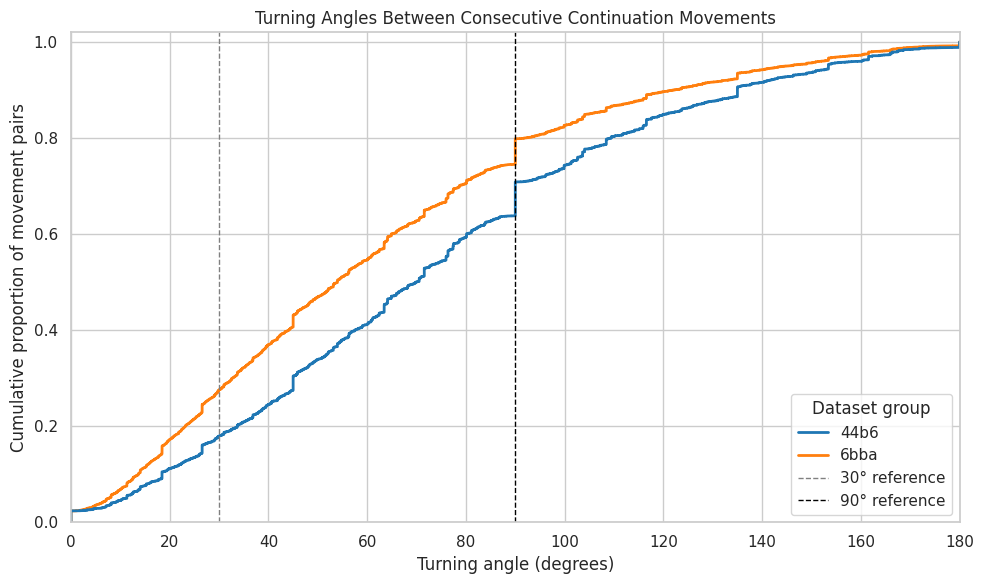

In [96]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.ecdfplot(
    data=directional_pairs,
    x="turning_angle_degrees",
    hue="group",
    hue_order=group_order,
    palette=group_palette,
    linewidth=2,
    ax=ax,
)

ax.axvline(
    30,
    color="grey",
    linestyle="--",
    linewidth=1,
    label="30° reference",
)

ax.axvline(
    90,
    color="black",
    linestyle="--",
    linewidth=1,
    label="90° reference",
)

ax.set_title("Turning Angles Between Consecutive Continuation Movements")
ax.set_xlabel("Turning angle (degrees)")
ax.set_ylabel("Cumulative proportion of movement pairs")
ax.set_xlim(0, 180)
ax.set_ylim(0, 1.02)

from matplotlib.lines import Line2D

legend_handles = [
    Line2D(
        [0],
        [0],
        color=group_palette["44b6"],
        linewidth=2,
        label="44b6",
    ),
    Line2D(
        [0],
        [0],
        color=group_palette["6bba"],
        linewidth=2,
        label="6bba",
    ),
    Line2D(
        [0],
        [0],
        color="grey",
        linestyle="--",
        linewidth=1,
        label="30° reference",
    ),
    Line2D(
        [0],
        [0],
        color="black",
        linestyle="--",
        linewidth=1,
        label="90° reference",
    ),
]

ax.legend(
    handles=legend_handles,
    title="Dataset group",
    loc="lower right",
)

plt.tight_layout()
plt.show()

The 6bba ECDF lies above the 44b6 ECDF across almost the complete range, showing a greater proportion of small turning angles. Thus, a typical annotated movement pair in 6bba shows greater directional persistence. A separate movie-level comparison is needed to determine whether this is also true of a typical movie.

### Compare Directional Persistence Between Typical Movies

The preceding ECDF gives every eligible movement pair equal weight. Movies containing more annotated trajectories therefore have greater influence.

To compare typical movies, the median turning angle is first calculated separately within each movie. These movie-level medians are then compared between groups, giving every movie one observation.

A lower movie-level median indicates greater directional persistence.

In [97]:
movie_direction_summary = (
    directional_pairs
    .groupby(
        [
            "sample_id",
            "group",
            "is_test_movie",
        ]
    )
    .agg(
        n_directional_pairs=(
            "turning_angle_degrees",
            "size",
        ),
        median_turning_angle=(
            "turning_angle_degrees",
            "median",
        ),
        percentage_below_30_degrees=(
            "turning_angle_degrees",
            percentage_below_30,
        ),
        percentage_above_90_degrees=(
            "turning_angle_degrees",
            percentage_above_90,
        ),
    )
    .reset_index()
)

# Include all 199 movies so that any movie without a valid
# directional pair is visible rather than silently omitted.
movie_direction_summary = (
    graph_summary[
        [
            "sample_id",
            "group",
            "is_test_movie",
        ]
    ]
    .merge(
        movie_direction_summary,
        on=[
            "sample_id",
            "group",
            "is_test_movie",
        ],
        how="left",
        validate="one_to_one",
    )
)

typical_movie_direction_summary = (
    movie_direction_summary
    .groupby("group")
    .agg(
        n_movies=("sample_id", "size"),
        movies_with_directional_pairs=(
            "median_turning_angle",
            "count",
        ),
        first_quartile_movie_median=(
            "median_turning_angle",
            first_quartile,
        ),
        median_movie_median=(
            "median_turning_angle",
            "median",
        ),
        mean_movie_median=(
            "median_turning_angle",
            "mean",
        ),
        third_quartile_movie_median=(
            "median_turning_angle",
            third_quartile,
        ),
        median_percentage_below_30=(
            "percentage_below_30_degrees",
            "median",
        ),
        median_percentage_above_90=(
            "percentage_above_90_degrees",
            "median",
        ),
    )
    .round(3)
)

display(typical_movie_direction_summary)

print(
    "\nMovies without a valid directional pair:",
    movie_direction_summary[
        "median_turning_angle"
    ].isna().sum(),
)

,n_movies,movies_with_directional_pairs,first_quartile_movie_median,median_movie_median,mean_movie_median,third_quartile_movie_median,median_percentage_below_30,median_percentage_above_90
group,,,,,,,,
44b6,71,71,51.464,62.494,65.004,80.624,20.172,22.000
6bba,128,128,38.841,55.304,55.980,75.679,24.670,19.344



Movies without a valid directional pair: 0


### Movie-Level Directional-Persistence Findings

All 199 movies contain at least one valid pair of consecutive movements.

The median turning angle for a typical `6bba` movie is approximately 55.3°, compared with 62.5° for a typical `44b6` movie. A typical `6bba` movie also has a greater proportion of angles below 30° and a smaller proportion above 90°.

The difference is smaller than in the analysis of all movement pairs, indicating that movies with many annotated pairs strengthened the earlier separation. Nevertheless, both analyses suggest greater directional persistence in `6bba`.

The movie-level interquartile ranges overlap substantially, so there is considerable variation within each group and group membership does not determine the behaviour of an individual movie.

### Visualise Movie-Level Directional Persistence

/tmp/ipykernel_16/2702304604.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


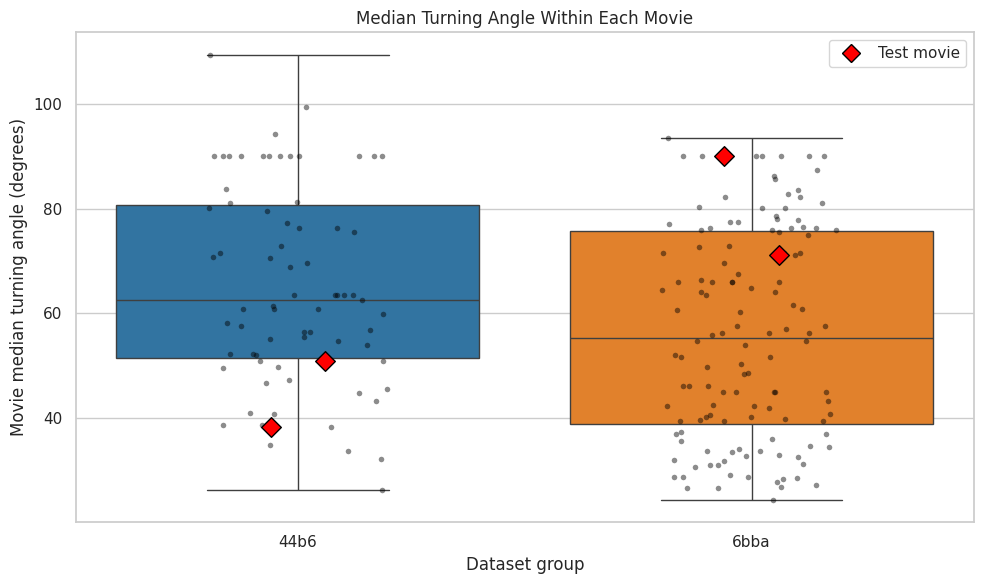

In [98]:
from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=movie_direction_summary,
    x="group",
    y="median_turning_angle",
    order=group_order,
    palette=group_palette,
    showfliers=False,
    ax=ax,
)

sns.stripplot(
    data=movie_direction_summary,
    x="group",
    y="median_turning_angle",
    order=group_order,
    color="black",
    alpha=0.45,
    jitter=0.2,
    size=4,
    ax=ax,
)

# Plot the two test movies in each group with small fixed offsets
# so that overlapping values cannot hide a marker.
test_direction_data = movie_direction_summary.loc[
    movie_direction_summary["is_test_movie"]
]

for group_position, group in enumerate(group_order):
    group_test_data = test_direction_data.loc[
        test_direction_data["group"] == group
    ]

    x_positions = np.linspace(
        group_position - 0.06,
        group_position + 0.06,
        len(group_test_data),
    )

    ax.scatter(
        x_positions,
        group_test_data["median_turning_angle"],
        color="red",
        edgecolor="black",
        marker="D",
        s=100,
        zorder=5,
    )

ax.set_title("Median Turning Angle Within Each Movie")
ax.set_xlabel("Dataset group")
ax.set_ylabel("Movie median turning angle (degrees)")

test_handle = Line2D(
    [0],
    [0],
    marker="D",
    color="red",
    markeredgecolor="black",
    linestyle="none",
    markersize=9,
    label="Test movie",
)

ax.legend(handles=[test_handle])

plt.tight_layout()
plt.show()

### Test-Movie Positions in the Movie-Level Distributions

Although `6bba` has a lower typical turning angle overall, the test movies do not follow this simple group-level pattern.

Both `44b6` test movies have relatively small median turning angles within their group. In contrast, both `6bba` test movies have relatively large median turning angles within their group.

The boxplots overlap substantially, showing that within-group variation is large. Group membership alone will therefore not provide an adequate description of directional movement in the test movies.

In [99]:
movie_direction_summary[
    "median_angle_group_percentile"
] = (
    movie_direction_summary
    .groupby("group")["median_turning_angle"]
    .rank(pct=True)
    * 100
)

test_direction_summary = (
    movie_direction_summary.loc[
        movie_direction_summary["is_test_movie"]
    ]
    .sort_values(["group", "sample_id"])
)

display(
    test_direction_summary[
        [
            "sample_id",
            "group",
            "n_directional_pairs",
            "median_turning_angle",
            "median_angle_group_percentile",
            "percentage_below_30_degrees",
            "percentage_above_90_degrees",
        ]
    ].round(3)
)

,sample_id,group,n_directional_pairs,median_turning_angle,median_angle_group_percentile,percentage_below_30_degrees,percentage_above_90_degrees
0,44b6_0113de3b,44b6,48,38.202,7.042,45.833,10.417
1,44b6_0b24845f,44b6,45,50.906,23.944,28.889,13.333
71,6bba_05b6850b,6bba,596,90.000,96.875,10.738,43.960
72,6bba_05db0fb1,6bba,836,71.108,69.531,17.943,30.742


### Test-Movie Directional Persistence

The test movies partly oppose the overall dataset-group pattern.

Both `44b6` test movies have unusually small median turning angles. `44b6_0113de3b` is at approximately the 7th percentile within its group, while `44b6_0b24845f` is at approximately the 24th percentile.

In contrast, both `6bba` test movies have relatively large turning angles. `6bba_05b6850b` is at approximately the 97th percentile, with a median angle of 90°, while `6bba_05db0fb1` is at approximately the 70th percentile.

The `44b6` estimates use only 45–48 movement pairs and are therefore less stable than the estimates for the more densely annotated `6bba` test movies. Nevertheless, group membership alone clearly does not describe the movement characteristics of the test set.

### Check Sensitivity to Short Movements

Turning angles can be unstable when either movement is very short. Because centroids use integer voxel coordinates, a small coordinate change can produce a large apparent change in direction.

The analysis is repeated while requiring both movements in a pair to exceed several minimum physical distances. If the group difference remains, it is less likely to be caused by coordinate discretisation.

In [100]:
directional_pairs["minimum_step_distance_um"] = (
    directional_pairs[
        [
            "distance_um_first",
            "distance_um_second",
        ]
    ]
    .min(axis=1)
)

minimum_distance_thresholds = [0, 0.5, 1.0, 2.0]

sensitivity_rows = []

for threshold in minimum_distance_thresholds:
    threshold_data = directional_pairs.loc[
        directional_pairs["minimum_step_distance_um"]
        >= threshold
    ]

    for group in group_order:
        group_data = threshold_data.loc[
            threshold_data["group"] == group,
            "turning_angle_degrees",
        ]

        sensitivity_rows.append(
            {
                "minimum_step_distance_um": threshold,
                "group": group,
                "n_directional_pairs": len(group_data),
                "median_turning_angle": group_data.median(),
                "percentage_below_30_degrees":
                    percentage_below_30(group_data),
                "percentage_above_90_degrees":
                    percentage_above_90(group_data),
            }
        )

turning_angle_sensitivity = pd.DataFrame(
    sensitivity_rows
)

display(
    turning_angle_sensitivity
    .set_index(
        [
            "minimum_step_distance_um",
            "group",
        ]
    )
    .round(3)
)

n_directional_pairs  median_turning_angle  \
minimum_step_distance_um group                                              
0.0                      44b6                 18430                69.906   
                         6bba                 86309                53.960   
0.5                      44b6                 15879                66.240   
                         6bba                 76217                50.206   
1.0                      44b6                 10721                58.417   
                         6bba                 56456                43.089   
2.0                      44b6                  3535                44.705   
                         6bba                 26800                32.661   

                                percentage_below_30_degrees  \
minimum_step_distance_um group                                
0.0                      44b6                        17.949   
                         6bba                        27.559   
0.5                      44b6                        19.101   
                         6bba                        29.497   
1.0                      44b6                        22.778   
                         6bba                        34.345   
2.0                      44b6                        31.429   
                         6bba                        45.840   

                                percentage_above_90_degrees  
minimum_step_distance_um group                               
0.0                      44b6                        29.143  
                         6bba                        20.151  
0.5                      44b6                        28.176  
                         6bba                        18.697  
1.0                      44b6                        25.809  
                         6bba                        16.905  
2.0                      44b6                        16.747  
                         6bba                         9.724

### Short-Movement Sensitivity Findings

The greater directional persistence in `6bba` remains at every minimum-distance threshold. Therefore, the group difference is not explained solely by very short movements.

In both groups, median turning angles decrease as short movements are excluded. The proportion below 30° increases, while the proportion above 90° decreases.

This is consistent with the direction of very short movements being less stable, potentially because small centroid changes are sensitive to integer-coordinate resolution. It may also indicate that larger biological or global movements tend to follow more coherent directions. 

### Visualise Sensitivity to Minimum Step Distance

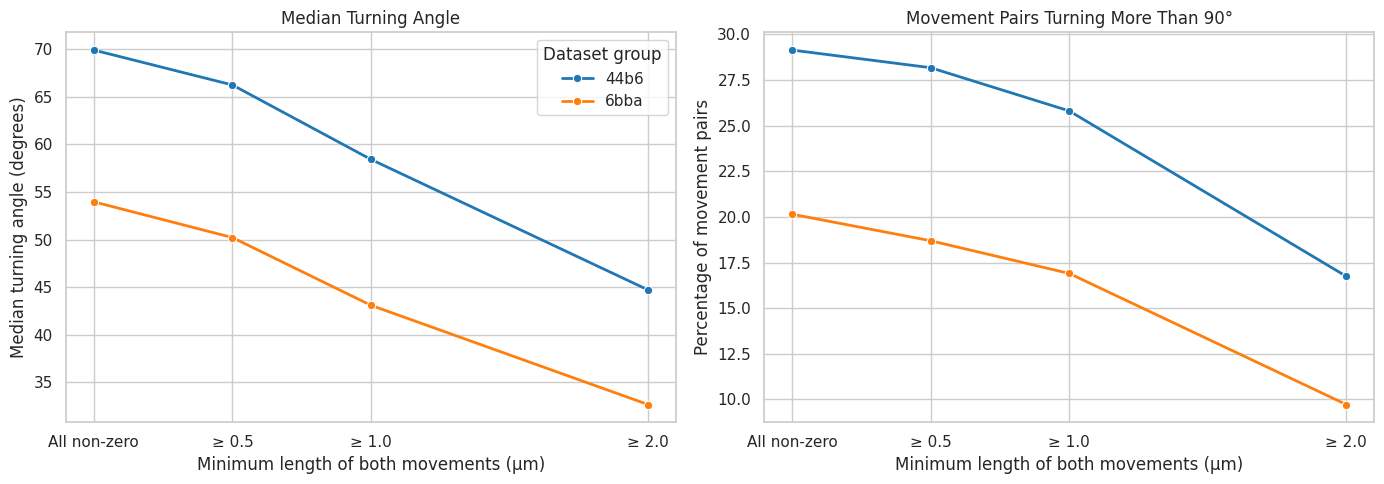

In [101]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5),
    sharex=True,
)

sns.lineplot(
    data=turning_angle_sensitivity,
    x="minimum_step_distance_um",
    y="median_turning_angle",
    hue="group",
    hue_order=group_order,
    palette=group_palette,
    marker="o",
    linewidth=2,
    ax=axes[0],
)

axes[0].set_title("Median Turning Angle")
axes[0].set_xlabel("Minimum length of both movements (µm)")
axes[0].set_ylabel("Median turning angle (degrees)")

sns.lineplot(
    data=turning_angle_sensitivity,
    x="minimum_step_distance_um",
    y="percentage_above_90_degrees",
    hue="group",
    hue_order=group_order,
    palette=group_palette,
    marker="o",
    linewidth=2,
    ax=axes[1],
)

axes[1].set_title("Movement Pairs Turning More Than 90°")
axes[1].set_xlabel("Minimum length of both movements (µm)")
axes[1].set_ylabel("Percentage of movement pairs")

threshold_labels = [
    "All non-zero",
    "≥ 0.5",
    "≥ 1.0",
    "≥ 2.0",
]

for ax in axes:
    ax.set_xticks(
        minimum_distance_thresholds,
        labels=threshold_labels,
    )

# Keep only one shared legend.
axes[0].legend(title="Dataset group")
axes[1].get_legend().remove()

plt.tight_layout()
plt.show()

### Directional-Persistence Summary

- Across all consecutive-movement pairs, `6bba` has smaller turning angles than `44b6`.
- The difference remains when every movie is weighted equally, although the movie-level distributions overlap substantially.
- The test movies partly oppose the overall group pattern: both `44b6` test movies are relatively persistent, while both `6bba` test movies have comparatively large turning angles.
- Removing short movements reduces turning angles in both groups, but the difference between groups remains at every threshold.
- Recent movement direction may therefore be useful as a linking feature, although its reliability depends on movement length and can also be affected by global image motion.

## Examine Spatial Crowding and Link Ambiguity

Tracking becomes more difficult when several plausible target cells are located close to a source cell in the next frame. A correct link may be obvious when its target is isolated, but ambiguous when other cells are equally close.

The analysis will examine distances between supplied annotations within the same movie and timepoint. Because the ground truth is sparsely labelled, these distances do not measure the complete biological cell density. They describe crowding among the supplied annotations only, and comparisons between groups may be influenced by their very different annotation coverage.

A dataset-level node table is first constructed from the source and target endpoints in the edge table. The earlier integrity checks found no isolated nodes, so every supplied node appears in at least one edge.

### Build a Dataset-Level Node Table

In [102]:
source_node_summary = (
    edge_summary[
        [
            "sample_id",
            "group",
            "is_test_movie",
            "source_id",
            "source_t",
            "source_z",
            "source_y",
            "source_x",
        ]
    ]
    .rename(
        columns={
            "source_id": "node_id",
            "source_t": "t",
            "source_z": "z",
            "source_y": "y",
            "source_x": "x",
        }
    )
)

target_node_summary = (
    edge_summary[
        [
            "sample_id",
            "group",
            "is_test_movie",
            "target_id",
            "target_t",
            "target_z",
            "target_y",
            "target_x",
        ]
    ]
    .rename(
        columns={
            "target_id": "node_id",
            "target_t": "t",
            "target_z": "z",
            "target_y": "y",
            "target_x": "x",
        }
    )
)

node_occurrences = pd.concat(
    [
        source_node_summary,
        target_node_summary,
    ],
    ignore_index=True,
)

# Check whether repeated appearances of the same node
# always have identical coordinates.
coordinate_conflicts = (
    node_occurrences
    .groupby(["sample_id", "node_id"])[
        ["t", "z", "y", "x"]
    ]
    .nunique()
    .gt(1)
    .any(axis=1)
    .sum()
)

node_summary = (
    node_occurrences
    .drop_duplicates(["sample_id", "node_id"])
    .sort_values(["sample_id", "t", "node_id"])
    .reset_index(drop=True)
)

node_table_checks = pd.Series(
    {
        "number of nodes": len(node_summary),
        "movies represented": node_summary["sample_id"].nunique(),
        "duplicate movie-node IDs": node_summary.duplicated(
            ["sample_id", "node_id"]
        ).sum(),
        "coordinate conflicts": coordinate_conflicts,
        "missing values": node_summary.isna().sum().sum(),
        "node total agrees with graph table": (
            len(node_summary)
            == graph_summary["n_nodes"].sum()
        ),
    },
    name="value",
)

display(node_table_checks.to_frame())
display(node_summary.head())

,value
number of nodes,133318
movies represented,199
duplicate movie-node IDs,0
coordinate conflicts,0
missing values,0
node total agrees with graph table,True


,sample_id,group,is_test_movie,node_id,t,z,y,x
0,44b6_0113de3b,44b6,True,11000000075,0,63,222,249
1,44b6_0113de3b,44b6,True,12000000075,1,63,227,251
2,44b6_0113de3b,44b6,True,13000000075,2,63,230,253
3,44b6_0113de3b,44b6,True,38000000003,27,1,74,73
4,44b6_0113de3b,44b6,True,39000000003,28,3,78,75


### Count Supplied Nodes Within Each Frame

A frame containing no supplied nodes provides no tracking information, while a frame containing one node has no competing annotated candidate. Nearest-neighbour crowding can only be measured when at least two supplied nodes occur in the same frame.

All 100 timepoints are included for every movie, including frames with no annotations. Because every movie has the same number of frames, each movie contributes equally to this frame-level summary.

In [103]:
observed_frame_counts = (
    node_summary
    .groupby(
        [
            "sample_id",
            "group",
            "is_test_movie",
            "t",
        ]
    )
    .size()
    .rename("n_annotated_nodes")
    .reset_index()
)

# Construct all 100 frames for every movie so that frames
# containing no supplied nodes are not silently omitted.
all_movie_frames = (
    graph_summary[
        [
            "sample_id",
            "group",
            "is_test_movie",
        ]
    ]
    .merge(
        pd.DataFrame({"t": np.arange(100)}),
        how="cross",
    )
)

frame_node_counts = (
    all_movie_frames
    .merge(
        observed_frame_counts,
        on=[
            "sample_id",
            "group",
            "is_test_movie",
            "t",
        ],
        how="left",
        validate="one_to_one",
    )
)

frame_node_counts["n_annotated_nodes"] = (
    frame_node_counts["n_annotated_nodes"]
    .fillna(0)
    .astype(int)
)

frame_count_summary = (
    frame_node_counts
    .groupby("group")
    .agg(
        n_frames=("t", "size"),
        mean_nodes_per_frame=(
            "n_annotated_nodes",
            "mean",
        ),
        median_nodes_per_frame=(
            "n_annotated_nodes",
            "median",
        ),
        maximum_nodes_in_one_frame=(
            "n_annotated_nodes",
            "max",
        ),
        percentage_empty_frames=(
            "n_annotated_nodes",
            lambda values: 100 * values.eq(0).mean(),
        ),
        percentage_one_node_frames=(
            "n_annotated_nodes",
            lambda values: 100 * values.eq(1).mean(),
        ),
        percentage_frames_with_two_or_more=(
            "n_annotated_nodes",
            lambda values: 100 * values.ge(2).mean(),
        ),
    )
    .round(3)
)

display(frame_count_summary)

print(
    "\nTotal movie-frame rows:",
    len(frame_node_counts),
)

,n_frames,mean_nodes_per_frame,median_nodes_per_frame,maximum_nodes_in_one_frame,percentage_empty_frames,percentage_one_node_frames,percentage_frames_with_two_or_more
group,,,,,,,
44b6,7100,2.845,2.0,16,9.958,20.972,69.07
6bba,12800,8.838,8.0,33,2.031,1.469,96.50



Total movie-frame rows: 19900


### Supplied Frame-Level Annotation Density

The supplied annotations are substantially denser within `6bba` frames. A typical `6bba` frame contains eight annotated nodes, compared with two in `44b6`.

Approximately 96.5% of `6bba` frames contain at least two annotations and can contribute a nearest-neighbour distance. The corresponding proportion is only 69.1% in `44b6`.

This should not be interpreted as evidence that the biological tissue is necessarily denser in `6bba`. The groups have very different annotation coverage, so these results primarily describe the density of the supplied labels.

### Calculate Within-Frame Nearest-Neighbour Distances

For each supplied node, the nearest other supplied node in the same movie and timepoint is identified using physical coordinates.

A small nearest-neighbour distance indicates that another annotated cell is spatially close. This may make detection and linking more ambiguous, although unannotated cells are not represented in this calculation.

Nearest-neighbour distance is undefined in frames containing only one supplied node.

In [104]:
from scipy.spatial import cKDTree

node_crowding_frames = []

for (_, _), frame_nodes in node_summary.groupby(
    ["sample_id", "t"],
    sort=False,
):
    frame_nodes = frame_nodes.copy()

    physical_coordinates = np.column_stack(
        [
            frame_nodes["z"].to_numpy() * 1.625,
            frame_nodes["y"].to_numpy() * 0.40625,
            frame_nodes["x"].to_numpy() * 0.40625,
        ]
    )

    if len(frame_nodes) >= 2:
        tree = cKDTree(physical_coordinates)

        neighbour_distances, neighbour_indices = tree.query(
            physical_coordinates,
            k=2,
        )

        frame_nodes["nearest_neighbor_distance_um"] = (
            neighbour_distances[:, 1]
        )

        frame_nodes["nearest_neighbor_node_id"] = (
            frame_nodes.iloc[
                neighbour_indices[:, 1]
            ]["node_id"].to_numpy()
        )
    else:
        frame_nodes["nearest_neighbor_distance_um"] = np.nan
        frame_nodes["nearest_neighbor_node_id"] = np.nan

    node_crowding_frames.append(frame_nodes)

node_crowding = pd.concat(
    node_crowding_frames,
    ignore_index=True,
)

node_crowding["nearest_neighbor_node_id"] = (
    node_crowding["nearest_neighbor_node_id"]
    .astype("Int64")
)

nodes_in_multi_node_frames = (
    frame_node_counts.loc[
        frame_node_counts["n_annotated_nodes"] >= 2,
        "n_annotated_nodes",
    ]
    .sum()
)

nearest_neighbor_checks = pd.Series(
    {
        "number of nodes": len(node_crowding),
        "movies represented": node_crowding[
            "sample_id"
        ].nunique(),
        "nodes with a nearest neighbour": node_crowding[
            "nearest_neighbor_distance_um"
        ].notna().sum(),
        "expected nodes with a nearest neighbour":
            nodes_in_multi_node_frames,
        "all distances are non-negative": node_crowding[
            "nearest_neighbor_distance_um"
        ].dropna().ge(0).all(),
    },
    name="value",
)

display(nearest_neighbor_checks.to_frame())

display(
    node_crowding.loc[
        node_crowding["nearest_neighbor_distance_um"].notna(),
        [
            "sample_id",
            "group",
            "node_id",
            "t",
            "z",
            "y",
            "x",
            "nearest_neighbor_node_id",
            "nearest_neighbor_distance_um",
        ],
    ].head().round(3)
)

,value
number of nodes,133318
movies represented,199
nodes with a nearest neighbour,131641
expected nodes with a nearest neighbour,131641
all distances are non-negative,True


,sample_id,group,node_id,t,z,y,x,nearest_neighbor_node_id,nearest_neighbor_distance_um
80,44b6_0b24845f,44b6,118000000027,39,5,240,254,118000000036,84.557
81,44b6_0b24845f,44b6,118000000036,39,42,147,141,118000000027,84.557
82,44b6_0b24845f,44b6,119000000027,40,3,240,253,119000000036,86.722
83,44b6_0b24845f,44b6,119000000036,40,42,148,140,119000000027,86.722
84,44b6_0b24845f,44b6,120000000027,41,2,239,253,120000000036,87.362


### Summarise Supplied-Annotation Crowding

Nearest-neighbour distances are summarised across nodes with at least one other supplied annotation in the same frame.

Smaller distances indicate greater crowding among the supplied labels. Because `6bba` contains more supplied annotations per frame, it may have smaller nearest-neighbour distances even if the underlying biological density is similar.

These are node-level descriptive summaries. Nodes from the same movie and frame are not independent observations.

In [105]:
crowding_summary = (
    node_crowding
    .groupby("group")
    .agg(
        n_nodes_with_neighbor=(
            "nearest_neighbor_distance_um",
            "count",
        ),
        minimum_distance=(
            "nearest_neighbor_distance_um",
            "min",
        ),
        first_quartile_distance=(
            "nearest_neighbor_distance_um",
            first_quartile,
        ),
        median_distance=(
            "nearest_neighbor_distance_um",
            "median",
        ),
        mean_distance=(
            "nearest_neighbor_distance_um",
            "mean",
        ),
        third_quartile_distance=(
            "nearest_neighbor_distance_um",
            third_quartile,
        ),
        percentile_95_distance=(
            "nearest_neighbor_distance_um",
            ninety_fifth_percentile,
        ),
        maximum_distance=(
            "nearest_neighbor_distance_um",
            "max",
        ),
        percentage_within_5_um=(
            "nearest_neighbor_distance_um",
            lambda values: 100 * values.le(5).mean(),
        ),
        percentage_within_10_um=(
            "nearest_neighbor_distance_um",
            lambda values: 100 * values.le(10).mean(),
        ),
    )
    .round(3)
)

display(crowding_summary)

,n_nodes_with_neighbor,minimum_distance,first_quartile_distance,median_distance,mean_distance,third_quartile_distance,percentile_95_distance,maximum_distance,percentage_within_5_um,percentage_within_10_um
group,,,,,,,,,,
44b6,18708,2.873,15.464,22.757,26.443,32.525,60.284,116.480,0.208,7.343
6bba,112933,3.723,18.798,25.292,27.523,33.814,50.313,119.849,0.007,1.424


### Initial Supplied-Crowding Findings

The number of supplied annotations per frame does not translate directly into smaller nearest-neighbour distances.

`44b6` has a slightly smaller median nearest-neighbour distance than `6bba`: approximately 22.76 µm compared with 25.29 µm. Supplied neighbours within 10 µm are also more common in `44b6`, although they remain uncommon in both groups.

At the same time, `44b6` has a longer upper tail, with a 95th percentile of approximately 60.28 µm compared with 50.31 µm in `6bba`. Its supplied annotations therefore include both more close neighbours and more highly isolated nodes.

The interquartile ranges overlap substantially. These results describe the spatial arrangement of the sparse supplied annotations and should not be interpreted as complete biological cell-density measurements.

### Visualise Nearest-Neighbour Distances

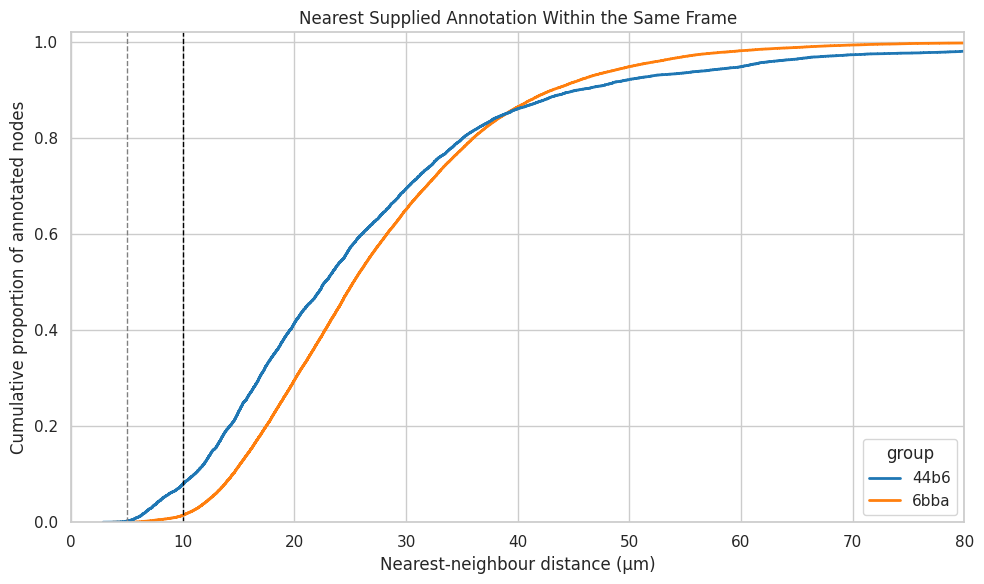

In [106]:
crowding_plot_data = node_crowding.loc[
    node_crowding["nearest_neighbor_distance_um"].notna()
]

fig, ax = plt.subplots(figsize=(10, 6))

sns.ecdfplot(
    data=crowding_plot_data,
    x="nearest_neighbor_distance_um",
    hue="group",
    hue_order=group_order,
    palette=group_palette,
    linewidth=2,
    ax=ax,
)

# Descriptive close-neighbour reference distances.
ax.axvline(
    5,
    color="grey",
    linestyle="--",
    linewidth=1,
)

ax.axvline(
    10,
    color="black",
    linestyle="--",
    linewidth=1,
)

ax.set_title(
    "Nearest Supplied Annotation Within the Same Frame"
)
ax.set_xlabel("Nearest-neighbour distance (µm)")
ax.set_ylabel("Cumulative proportion of annotated nodes")
ax.set_xlim(0, 80)
ax.set_ylim(0, 1.02)

plt.tight_layout()
plt.show()

### Nearest-Neighbour Distribution Findings

The nearest-neighbour ECDFs cross at approximately 40 µm, so neither group has uniformly smaller distances.

Below the crossing point, `44b6` has a greater proportion of relatively close supplied neighbours. Above it, `44b6` has more highly isolated annotations remaining in the upper tail.

This confirms that `44b6` has a more dispersed nearest-neighbour distribution, while the `6bba` distances are more concentrated in the central range. Very close supplied neighbours below 10 µm are uncommon in both groups.

### Compare Crowding Between Typical Movies

Nearest-neighbour measurements are first summarised separately within each movie. The distributions of these movie-level summaries are then compared so that every movie contributes one observation.

The median nearest-neighbour distance describes typical supplied-label spacing within a movie. The 95th percentile describes its more isolated annotations.

In [107]:
valid_node_crowding = node_crowding.loc[
    node_crowding["nearest_neighbor_distance_um"].notna()
]

movie_crowding_summary = (
    valid_node_crowding
    .groupby(
        [
            "sample_id",
            "group",
            "is_test_movie",
        ]
    )
    .agg(
        n_nodes_with_neighbor=(
            "nearest_neighbor_distance_um",
            "size",
        ),
        median_nearest_neighbor_distance=(
            "nearest_neighbor_distance_um",
            "median",
        ),
        percentile_95_nearest_neighbor_distance=(
            "nearest_neighbor_distance_um",
            ninety_fifth_percentile,
        ),
        percentage_within_10_um=(
            "nearest_neighbor_distance_um",
            lambda values: 100 * values.le(10).mean(),
        ),
    )
    .reset_index()
)

movie_crowding_summary = (
    graph_summary[
        [
            "sample_id",
            "group",
            "is_test_movie",
        ]
    ]
    .merge(
        movie_crowding_summary,
        on=[
            "sample_id",
            "group",
            "is_test_movie",
        ],
        how="left",
        validate="one_to_one",
    )
)

typical_movie_crowding_summary = (
    movie_crowding_summary
    .groupby("group")
    .agg(
        n_movies=("sample_id", "size"),
        movies_with_neighbor_distances=(
            "median_nearest_neighbor_distance",
            "count",
        ),
        first_quartile_movie_median=(
            "median_nearest_neighbor_distance",
            first_quartile,
        ),
        median_movie_median=(
            "median_nearest_neighbor_distance",
            "median",
        ),
        mean_movie_median=(
            "median_nearest_neighbor_distance",
            "mean",
        ),
        third_quartile_movie_median=(
            "median_nearest_neighbor_distance",
            third_quartile,
        ),
        median_movie_95th_percentile=(
            "percentile_95_nearest_neighbor_distance",
            "median",
        ),
        median_percentage_within_10_um=(
            "percentage_within_10_um",
            "median",
        ),
    )
    .round(3)
)

display(typical_movie_crowding_summary)

print(
    "\nMovies without a nearest-neighbour distance:",
    movie_crowding_summary[
        "median_nearest_neighbor_distance"
    ].isna().sum(),
)

,n_movies,movies_with_neighbor_distances,first_quartile_movie_median,median_movie_median,mean_movie_median,third_quartile_movie_median,median_movie_95th_percentile,median_percentage_within_10_um
group,,,,,,,,
44b6,71,64,17.605,25.002,27.757,34.107,44.505,0.000
6bba,128,128,22.348,25.998,27.270,30.591,47.808,0.245



Movies without a nearest-neighbour distance: 7


### Movie-Level Supplied-Crowding Findings

When every movie is weighted equally, the typical nearest-neighbour distances are similar: approximately 25.00 µm in `44b6` and 26.00 µm in `6bba`.

The principal group difference is dispersion rather than central location. Movie-level medians vary much more widely in `44b6`, with an interquartile range of approximately 17.61–34.11 µm, compared with 22.35–30.59 µm in `6bba`.

This suggests that the earlier excess of close 44b6 neighbours is concentrated in particular movies rather than being characteristic of a typical 44b6 movie.

The median percentage of neighbours within 10 µm is zero in `44b6` and only 0.25% in `6bba`. Very close supplied annotations are therefore uncommon in a typical movie.

Seven movies have no nearest-neighbour measurement. These require investigation because excluding them from the movie-level summaries could otherwise be overlooked.

### Identify Movies Without Measurable Within-Frame Crowding

In [108]:
movie_frame_count_summary = (
    frame_node_counts
    .groupby(
        [
            "sample_id",
            "group",
            "is_test_movie",
        ]
    )
    .agg(
        total_annotated_nodes=(
            "n_annotated_nodes",
            "sum",
        ),
        maximum_nodes_in_one_frame=(
            "n_annotated_nodes",
            "max",
        ),
        frames_with_two_or_more=(
            "n_annotated_nodes",
            lambda values: values.ge(2).sum(),
        ),
    )
    .reset_index()
)

movies_without_crowding = (
    movie_crowding_summary.loc[
        movie_crowding_summary[
            "median_nearest_neighbor_distance"
        ].isna(),
        [
            "sample_id",
            "group",
            "is_test_movie",
        ],
    ]
    .merge(
        movie_frame_count_summary,
        on=[
            "sample_id",
            "group",
            "is_test_movie",
        ],
        how="left",
        validate="one_to_one",
    )
)

display(movies_without_crowding)

,sample_id,group,is_test_movie,total_annotated_nodes,maximum_nodes_in_one_frame,frames_with_two_or_more
0,44b6_0113de3b,44b6,True,52,1,0
1,44b6_0c582fdc,44b6,False,71,1,0
2,44b6_18ced818,44b6,False,100,1,0
3,44b6_33b596bf,44b6,False,50,1,0
4,44b6_cf2536e8,44b6,False,76,1,0
5,44b6_e29f0176,44b6,False,51,1,0
6,44b6_f28707c6,44b6,False,63,1,0


### Movies with Undefined Nearest-Neighbour Distances

All seven movies without a nearest-neighbour measurement belong to `44b6`. Each contains at most one supplied annotation in every frame, so a within-frame neighbour never exists in the sparse ground truth.

This includes the test movie `44b6_0113de3b`. Its missing crowding measurement must not be interpreted as an absence of nearby biological cells; it means only that the supplied annotations do not contain another cell in the same frame.

### Compare Test-Movie Supplied-Annotation Crowding

In [109]:
movie_crowding_summary[
    "median_distance_group_percentile"
] = (
    movie_crowding_summary
    .groupby("group")[
        "median_nearest_neighbor_distance"
    ]
    .rank(pct=True)
    * 100
)

test_crowding_summary = (
    movie_crowding_summary.loc[
        movie_crowding_summary["is_test_movie"]
    ]
    .merge(
        movie_frame_count_summary[
            [
                "sample_id",
                "maximum_nodes_in_one_frame",
                "frames_with_two_or_more",
            ]
        ],
        on="sample_id",
        how="left",
        validate="one_to_one",
    )
    .sort_values(["group", "sample_id"])
)

display(
    test_crowding_summary[
        [
            "sample_id",
            "group",
            "maximum_nodes_in_one_frame",
            "frames_with_two_or_more",
            "n_nodes_with_neighbor",
            "median_nearest_neighbor_distance",
            "median_distance_group_percentile",
            "percentile_95_nearest_neighbor_distance",
            "percentage_within_10_um",
        ]
    ].round(3)
)

,sample_id,group,maximum_nodes_in_one_frame,frames_with_two_or_more,n_nodes_with_neighbor,median_nearest_neighbor_distance,median_distance_group_percentile,percentile_95_nearest_neighbor_distance,percentage_within_10_um
0,44b6_0113de3b,44b6,1,0,NaN,NaN,NaN,NaN,NaN
1,44b6_0b24845f,44b6,2,11,22.0,86.691,100.0,87.360,0.000
2,6bba_05b6850b,6bba,11,100,861.0,35.465,87.5,63.211,0.000
3,6bba_05db0fb1,6bba,17,100,1229.0,20.174,12.5,37.129,1.627
